# 임차택시 대기시간 분석

In [108]:
import json
import platform
from pathlib import Path
import importlib

import statsmodels
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.regression as sns_regression

sns_regression = importlib.reload(sns_regression)

from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

print("statsmodels:", statsmodels.__version__)
print("seaborn:", sns.__version__)

statsmodels: 0.15.0
seaborn: 0.13.2


In [109]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

rental_wait_preprocessed_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "임차택시_대기시간_전처리.csv"
)

df_rental = pd.read_csv(rental_wait_preprocessed_path)

datetime_cols = [
    "접수일시",
    "예정일시",
    "배차일시",
    "승차일시",
    "하차일시",
    "취소일시",
]

for col in datetime_cols:
    df_rental[col] = pd.to_datetime(df_rental[col], errors="coerce")

print(f"불러온 임차택시 전처리 데이터: {len(df_rental):,}건")

불러온 임차택시 전처리 데이터: 328,875건


| 데이터셋 | 필요 여부 | 이유 |
|---|---|---|
| `df_rental` | 필요 | 전체 전처리 결과, 검증·건수 확인용 |
| `rental_ride_normal` | 필요 | 바로콜 승차 대기시간 본 분석 |
| `rental_ride_exception` | 필요 | 예약 목적/250분 초과 예외 건수 확인용 |
| `rental_cancel` | 선택 | 취소 전체 규모 확인용 |
| `rental_cancel_normal` | 필요 | 바로콜 취소 대기시간 본 분석 |
| `rental_cancel_exception` | 선택 | 예약성 예외 취소 95건 확인용 |

In [110]:
rental_ride_normal = df_rental[
    df_rental["승차일시"].notna()
    & df_rental["임차택시_바로콜여부"]
].copy()

rental_ride_exception = df_rental[
    df_rental["승차일시"].notna()
    & df_rental["임차택시_예약성예외여부"]
].copy()

rental_cancel = df_rental[
    df_rental["취소일시"].notna()
].copy()

rental_cancel_normal = df_rental[
    df_rental["취소일시"].notna()
    & (df_rental["임차택시_취소분석유형"] == "바로콜 취소")
].copy()

rental_cancel_exception = df_rental[
    df_rental["취소일시"].notna()
    & (df_rental["임차택시_취소분석유형"] == "예약성 예외 취소")
].copy()

## 1. 전처리 결과 재확인

분석 노트북에서는 전처리된 CSV를 다시 불러오므로, 본 분석에 들어가기 전에 데이터셋 건수와 핵심 대기시간 컬럼의 유효 표본 수만 간단히 재확인한다.

In [111]:
# 데이터셋 건수 재확인
preprocessed_dataset_summary = pd.DataFrame({
    "데이터셋": [
        "df_rental",
        "rental_ride_normal",
        "rental_ride_exception",
        "rental_cancel",
        "rental_cancel_normal",
        "rental_cancel_exception",
    ],
    "용도": [
        "임차택시 전체 전처리 결과",
        "임차택시 바로콜 승차 대기시간 본 분석",
        "임차택시 예약성/장시간 예외 확인",
        "임차택시 취소 전체 확인",
        "임차택시 바로콜 취소시간 본 분석",
        "임차택시 예약성 예외 취소 확인",
    ],
    "건수": [
        len(df_rental),
        len(rental_ride_normal),
        len(rental_ride_exception),
        len(rental_cancel),
        len(rental_cancel_normal),
        len(rental_cancel_exception),
    ],
})

display(preprocessed_dataset_summary)

,데이터셋,용도,건수
0,df_rental,임차택시 전체 전처리 결과,328875
1,rental_ride_normal,임차택시 바로콜 승차 대기시간 본 분석,305729
2,rental_ride_exception,임차택시 예약성/장시간 예외 확인,6868
3,rental_cancel,임차택시 취소 전체 확인,16278
4,rental_cancel_normal,임차택시 바로콜 취소시간 본 분석,16183
5,rental_cancel_exception,임차택시 예약성 예외 취소 확인,95


In [112]:
# 핵심 대기시간 4구간 유효 표본 수 재확인
wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
    "접수_취소_분",
    "배차_취소_분",
]

wait_valid_sample_summary = pd.DataFrame({
    "대기시간구간": [
        "접수→배차",
        "접수→승차",
        "접수→취소",
        "배차→취소",
    ],
    "컬럼명": wait_cols,
    "유효건수": [
        df_rental[col].notna().sum()
        for col in wait_cols
    ],
    "결측건수": [
        df_rental[col].isna().sum()
        for col in wait_cols
    ],
})

display(wait_valid_sample_summary)

,대기시간구간,컬럼명,유효건수,결측건수
0,접수→배차,접수_배차_분,328859,16
1,접수→승차,접수_승차_분,312597,16278
2,접수→취소,접수_취소_분,16278,312597
3,배차→취소,배차_취소_분,16262,312613


In [113]:
# 보조 확인용 배차→승차 유효 표본 수
dispatch_to_boarding_summary = pd.DataFrame({
    "대기시간구간": ["배차→승차"],
    "분석역할": ["보조"],
    "컬럼명": ["배차_승차_분"],
    "유효건수": [df_rental["배차_승차_분"].notna().sum()],
    "결측건수": [df_rental["배차_승차_분"].isna().sum()],
})

display(dispatch_to_boarding_summary)

,대기시간구간,분석역할,컬럼명,유효건수,결측건수
0,배차→승차,보조,배차_승차_분,312597,16278


## 2. 임차택시 바로콜 승차 대기시간 분석

바로콜 승차 건을 대상으로 승차 대기시간의 핵심 구간인 `접수→배차`와 `접수→승차`를 분석한다. `배차→승차`는 핵심 지표는 아니지만, `접수→승차` 시간이 길어진 원인을 배차 이후 단계까지 확인하기 위한 보조 지표로 함께 확인한다.

확인할 내용:

- `접수→배차` 평균, 중앙값, 75분위수, 90분위수, 95분위수, 99분위수
- `접수→승차` 평균, 중앙값, 75분위수, 90분위수, 95분위수, 99분위수
- 보조 확인: `배차→승차` 평균, 중앙값, 75분위수, 90분위수
- `접수→승차` 중 `접수→배차`가 차지하는 비중
- 장시간 대기 구간의 규모

분석 근거:

`접수→배차`는 접수 후 차량이 실제로 잡히기까지 걸린 시간이므로 배차 지연을 직접적으로 보여준다. `접수→승차`는 이용자가 체감하는 전체 승차 대기시간이다. 두 지표를 함께 보면 전체 대기시간이 길어지는 원인이 배차 지연 쪽에 있는지 확인할 수 있다.

| 지표 | 의미 | 왜 보는가 |
|---|---|---|
| 평균 | 전체 평균 대기시간 | 전반적 수준 확인, 단 장시간 대기에 민감 |
| 중앙값 | 절반이 이 시간 이하 | “보통 이용자”의 대기시간 |
| 75분위수 | 75%가 이 시간 이하 | 다소 긴 대기 기준 |
| 90분위수 | 90%가 이 시간 이하 | 상위 10% 장시간 대기 확인 |
| 95분위수 | 95%가 이 시간 이하 | 심한 대기 확인 |
| 99분위수 | 99%가 이 시간 이하 | 극단적 장시간 대기 직전 확인 |

In [114]:
ride_wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
    "배차_승차_분",
]

ride_wait_summary = []

for col in ride_wait_cols:
    values = rental_ride_normal[col].dropna()

    ride_wait_summary.append({
        "구간": col.replace("_", "→").replace("분", "").rstrip("→"),
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "99분위수": values.quantile(0.99),
        "최대값": values.max(),
    })

ride_wait_summary = pd.DataFrame(ride_wait_summary)

display(ride_wait_summary)

,구간,건수,평균,중앙값,75분위수,90분위수,95분위수,99분위수,최대값
0,접수→배차,305729,25.140312,9.275950,31.415783,66.640327,127.141000,153.710462,231.220450
1,접수→승차,305729,42.448953,28.513783,50.277833,87.335210,145.045767,174.635667,249.898667
2,배차→승차,305729,17.308641,16.309500,21.764500,27.416343,31.280603,40.997424,139.230383


In [115]:
rental_ride_normal["접수_승차_중_접수_배차_비중"] = (
    rental_ride_normal["접수_배차_분"]
    / rental_ride_normal["접수_승차_분"]
)

dispatch_share_summary = rental_ride_normal[
    "접수_승차_중_접수_배차_비중"
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

display(dispatch_share_summary)

count    305729.000000
mean          0.421784
std           0.269633
min           0.009496
25%           0.171595
50%           0.377836
75%           0.660631
90%           0.819983
95%           0.875728
99%           0.936564
max           0.999699
Name: 접수_승차_중_접수_배차_비중, dtype: float64

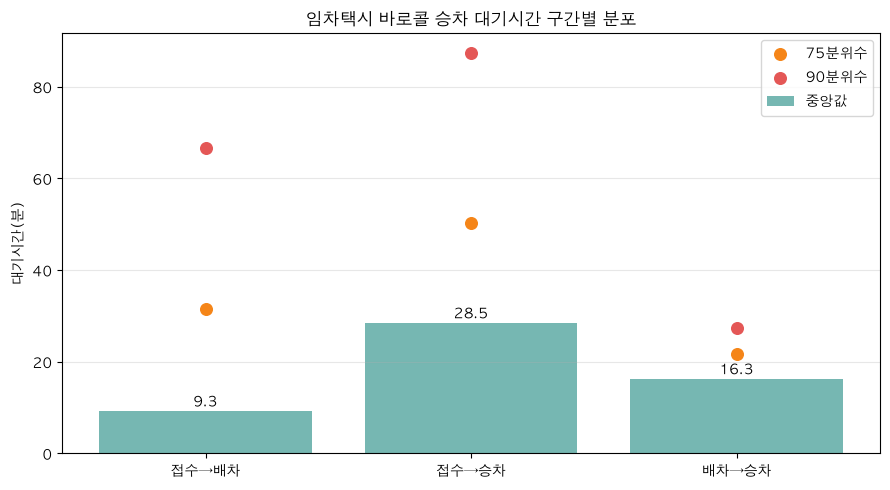

In [116]:
plot_data = ride_wait_summary.copy()

fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(plot_data))

ax.bar(
    x,
    plot_data["중앙값"],
    color="#76b7b2",
    label="중앙값",
)

ax.scatter(
    x,
    plot_data["75분위수"],
    color="#f58518",
    s=70,
    zorder=3,
    label="75분위수",
)

ax.scatter(
    x,
    plot_data["90분위수"],
    color="#e45756",
    s=70,
    zorder=3,
    label="90분위수",
)

for i, row in plot_data.iterrows():
    ax.text(
        i,
        row["중앙값"],
        f'{row["중앙값"]:.1f}',
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("임차택시 바로콜 승차 대기시간 구간별 분포")
ax.set_ylabel("대기시간(분)")
ax.set_xticks(list(x))
ax.set_xticklabels(plot_data["구간"])
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

보통 이용에서는 접수→배차와 배차→승차가 모두 대기시간을 구성하지만,
장시간 대기 문제는 주로 접수→배차 단계에서 발생할 가능성이 높다.

임차택시 바로콜의 일반적인 승차 대기시간은 접수 후 배차까지 약 10분, 배차 후 승차까지 약 16분 수준으로 나타난다. 다만 장시간 대기 문제는 `배차→승차`보다 `접수→배차`에서 더 뚜렷하다. `배차→승차` 시간은 평균과 중앙값의 차이가 작아 비교적 안정적인 반면, `접수→배차` 시간은 평균이 중앙값보다 크게 높아 일부 건에서 배차가 매우 늦게 이루어지는 긴 꼬리가 존재한다. 따라서 임차택시 대기시간 개선 관점에서는 배차 이후 이동시간보다 접수 후 배차까지의 지연을 우선적으로 확인할 필요가 있다.

,지표,접수→배차 대기시간(분)
0,중앙값,9.269333
1,75분위수,31.363717
2,90분위수,66.450833
3,95분위수,127.080583


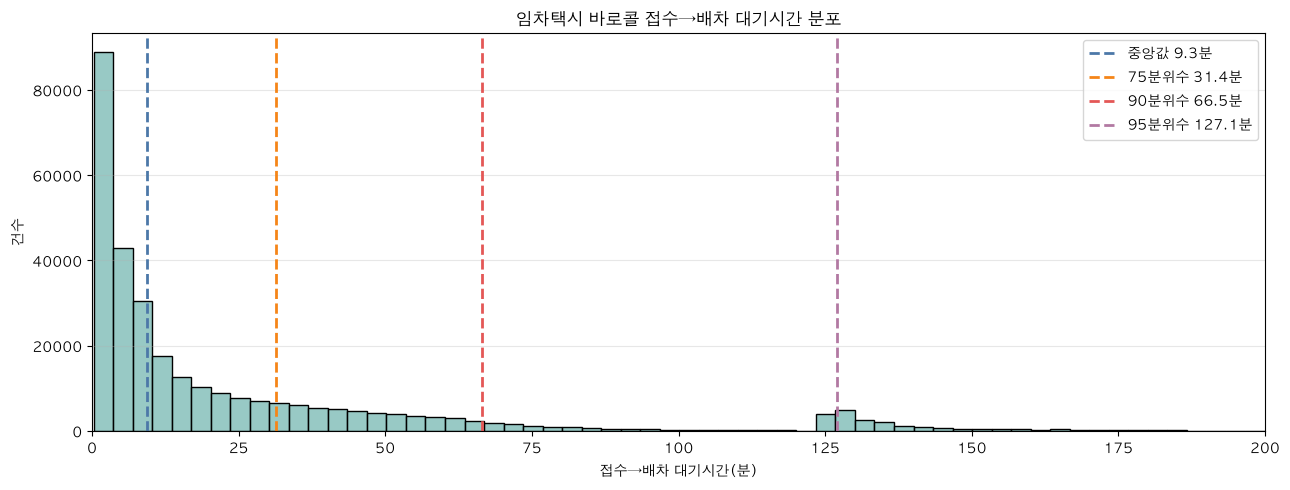

In [117]:
# 코드 셀 목적: 임차택시 바로콜의 접수→배차 대기시간 분포와 주요 분위수를 확인한다.

rental_dispatch_wait = rental_ride_normal["접수_배차_분"].dropna()
rental_dispatch_wait = pd.to_numeric(rental_dispatch_wait, errors="coerce").dropna()
rental_dispatch_wait = rental_dispatch_wait[rental_dispatch_wait.between(0, 200)]

rental_dispatch_quantiles = {
    "중앙값": rental_dispatch_wait.median(),
    "75분위수": rental_dispatch_wait.quantile(0.75),
    "90분위수": rental_dispatch_wait.quantile(0.90),
    "95분위수": rental_dispatch_wait.quantile(0.95),
}

display(
    pd.DataFrame({
        "지표": rental_dispatch_quantiles.keys(),
        "접수→배차 대기시간(분)": rental_dispatch_quantiles.values(),
    })
)

fig, ax = plt.subplots(figsize=(13, 5))

sns.histplot(
    rental_dispatch_wait,
    bins=60,
    color="#76b7b2",
    ax=ax,
)

quantile_styles = {
    "중앙값": ("#4c78a8", "--"),
    "75분위수": ("#f58518", "--"),
    "90분위수": ("#e45756", "--"),
    "95분위수": ("#b279a2", "--"),
}

for label, value in rental_dispatch_quantiles.items():
    color, linestyle = quantile_styles[label]
    ax.axvline(
        value,
        color=color,
        linestyle=linestyle,
        linewidth=2,
        label=f"{label} {value:.1f}분",
    )

ax.set_title("임차택시 바로콜 접수→배차 대기시간 분포")
ax.set_xlabel("접수→배차 대기시간(분)")
ax.set_ylabel("건수")
ax.set_xlim(0, 200)
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 3. 임차택시 바로콜 취소 대기시간 분석

임차택시 바로콜 취소 건을 대상으로 `접수→취소`와 `배차→취소` 시간을 분석한다.

취소 분석은 본 분석 대상인 `rental_cancel_normal`을 중심으로 진행한다. 예약성 예외 취소는 임차택시 운영 기준과 맞지 않는 예외 건이므로 본 분석에서는 제외하고, 건수만 재확인한다.

확인할 내용:

- 임차택시 취소 전체 건수
- 바로콜 취소 건수
- 예약성 예외 취소 건수
- `접수→취소` 평균, 중앙값, 75분위수, 90분위수, 95분위수, 99분위수
- `배차→취소` 평균, 중앙값, 75분위수, 90분위수, 95분위수, 99분위수
- 배차 전 취소 건수
- 배차 후 취소 건수

분석 근거:

`접수→취소`는 접수 후 얼마 만에 취소했는지 보여준다. `배차→취소`는 차량이 배정된 뒤에도 취소가 발생하는지, 발생한다면 배차 후 어느 정도 시간이 지나 취소되는지 보여준다.

따라서 취소 분석은 `접수→취소`와 `배차→취소`를 함께 보고, 배차 전 취소와 배차 후 취소를 나누어 해석한다.

예약성 예외 취소는 접수시점과 실제 이용시점 사이가 길 수 있으므로 바로콜 취소와 섞으면 장시간 대기 후 취소한 것으로 과대 해석될 수 있다. 따라서 본 분석에서는 바로콜 취소만 사용한다.

In [118]:
# 취소 분석 대상 건수 확인
cancel_dataset_summary = pd.DataFrame({
    "구분": [
        "취소 전체",
        "바로콜 취소",
        "예약성 예외 취소",
    ],
    "데이터셋": [
        "rental_cancel",
        "rental_cancel_normal",
        "rental_cancel_exception",
    ],
    "건수": [
        len(rental_cancel),
        len(rental_cancel_normal),
        len(rental_cancel_exception),
    ],
})

display(cancel_dataset_summary)

,구분,데이터셋,건수
0,취소 전체,rental_cancel,16278
1,바로콜 취소,rental_cancel_normal,16183
2,예약성 예외 취소,rental_cancel_exception,95


In [119]:
# 바로콜 취소 대기시간 요약
cancel_wait_cols = [
    "접수_취소_분",
    "배차_취소_분",
]

cancel_wait_summary = []

for col in cancel_wait_cols:
    values = rental_cancel_normal[col].dropna()

    cancel_wait_summary.append({
        "구간": col.replace("_", "→").replace("분", "").rstrip("→"),
        "건수": values.count(),
        "평균": values.mean(),
        "중앙값": values.median(),
        "75분위수": values.quantile(0.75),
        "90분위수": values.quantile(0.90),
        "95분위수": values.quantile(0.95),
        "99분위수": values.quantile(0.99),
        "최대값": values.max(),
    })

cancel_wait_summary = pd.DataFrame(cancel_wait_summary)

display(cancel_wait_summary)

,구간,건수,평균,중앙값,75분위수,90분위수,95분위수,99분위수,최대값
0,접수→취소,16183,35.345558,16.583333,42.281558,128.367767,138.966828,169.882203,241.515883
1,배차→취소,16167,5.070226,2.698950,5.381083,12.090047,17.854418,32.298403,168.368117


In [120]:
# 배차 전/후 취소 건수 확인
cancel_dispatch_summary = pd.DataFrame({
    "구분": [
        "바로콜 취소 전체",
        "배차 후 취소",
        "배차 전 취소 또는 배차일시 미기록 취소",
    ],
    "건수": [
        len(rental_cancel_normal),
        rental_cancel_normal["배차일시"].notna().sum(),
        rental_cancel_normal["배차일시"].isna().sum(),
    ],
})

cancel_dispatch_summary["비율(%)"] = (
    cancel_dispatch_summary["건수"]
    / len(rental_cancel_normal)
    * 100
)

display(cancel_dispatch_summary)

,구분,건수,비율(%)
0,바로콜 취소 전체,16183,100.000000
1,배차 후 취소,16167,99.901131
2,배차 전 취소 또는 배차일시 미기록 취소,16,0.098869


In [121]:
# 배차 전 취소 원자료 확인
cancel_without_dispatch = rental_cancel_normal[
    rental_cancel_normal["배차일시"].isna()
].copy()

print(
    "바로콜 취소 중 배차 전 취소 또는 배차일시 미기록 취소:",
    f"{len(cancel_without_dispatch):,}건"
)

display(
    cancel_without_dispatch[
        [
            "접수일시",
            "배차일시",
            "취소일시",
            "접수_취소_분",
            "배차_취소_분",
            "이용목적",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
        ]
    ].head(20)
)

바로콜 취소 중 배차 전 취소 또는 배차일시 미기록 취소: 16건


,접수일시,배차일시,취소일시,접수_취소_분,배차_취소_분,이용목적,출발구,출발동,목적구,목적동
23468,2025-02-04 12:00:22.730,NaT,2025-02-04 12:02:19,1.937833,NaN,기타,마포구,상암동,송파구,가락1동
64980,2025-03-25 17:00:43.263,NaT,2025-03-25 17:01:28,0.745617,NaN,기타,은평구,신사제1동,마포구,성산제2동
71285,2025-04-02 15:27:01.640,NaT,2025-04-02 16:23:30,56.472667,NaN,기타,강동구,상일동,하남시,풍산동
90135,2025-04-24 15:04:40.270,NaT,2025-04-24 15:56:14,51.562167,NaN,기타,강동구,상일동,하남시,풍산동
122287,2025-06-05 12:59:51.880,NaT,2025-06-05 13:01:17,1.418667,NaN,기타,서대문구,홍제제3동,성동구,마장동
143702,2025-06-26 14:12:55.000,NaT,2025-06-26 14:14:06,1.183333,NaN,귀가,노원구,공릉2동,노원구,상계1동
175850,2025-07-28 16:21:38.730,NaT,2025-07-28 16:23:42,2.054500,NaN,기타,강서구,등촌제3동,영등포구,도림동
181474,2025-08-04 14:01:53.560,NaT,2025-08-04 14:11:27,9.557333,NaN,기타,동작구,대방동,서초구,방배2동
193079,2025-08-14 14:19:41.553,NaT,2025-08-14 15:03:06,43.407450,NaN,기타,관악구,대학동,동작구,신대방제1동
194997,2025-08-18 13:27:13.333,NaT,2025-08-18 13:28:29,1.261117,NaN,기타,강남구,일원2동,서초구,양재2동


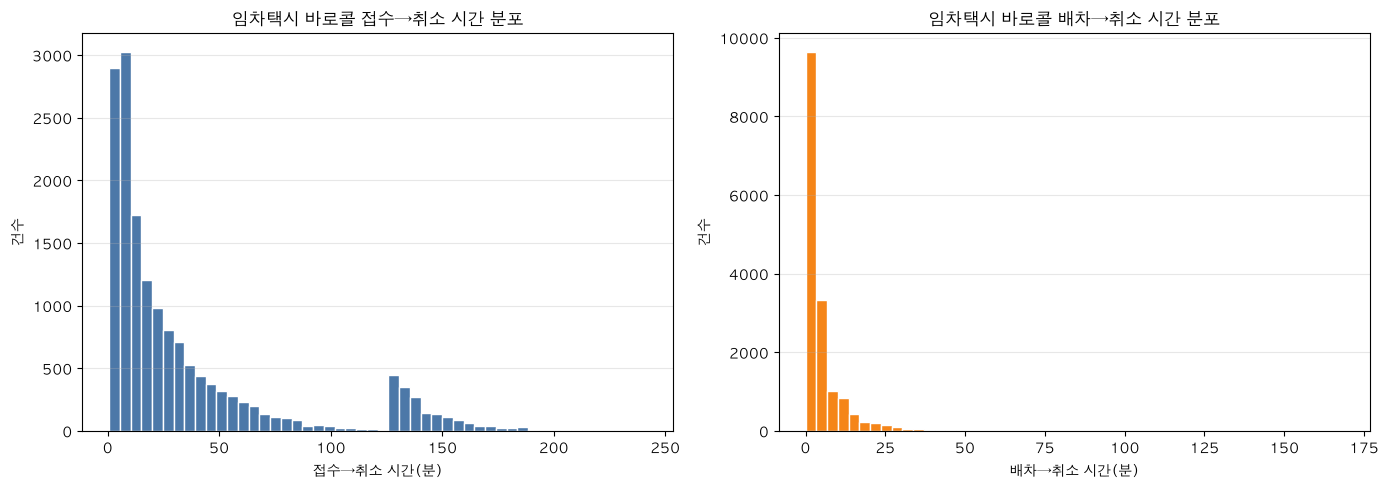

In [122]:
# 바로콜 취소 대기시간 히스토그램
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    rental_cancel_normal["접수_취소_분"].dropna(),
    bins=50,
    color="#4c78a8",
    edgecolor="white",
)

axes[0].set_title("임차택시 바로콜 접수→취소 시간 분포")
axes[0].set_xlabel("접수→취소 시간(분)")
axes[0].set_ylabel("건수")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(
    rental_cancel_normal["배차_취소_분"].dropna(),
    bins=50,
    color="#f58518",
    edgecolor="white",
)

axes[1].set_title("임차택시 바로콜 배차→취소 시간 분포")
axes[1].set_xlabel("배차→취소 시간(분)")
axes[1].set_ylabel("건수")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

,지표,접수→취소 대기시간(분)
0,중앙값,16.531550
1,75분위수,41.965167
2,90분위수,128.117857


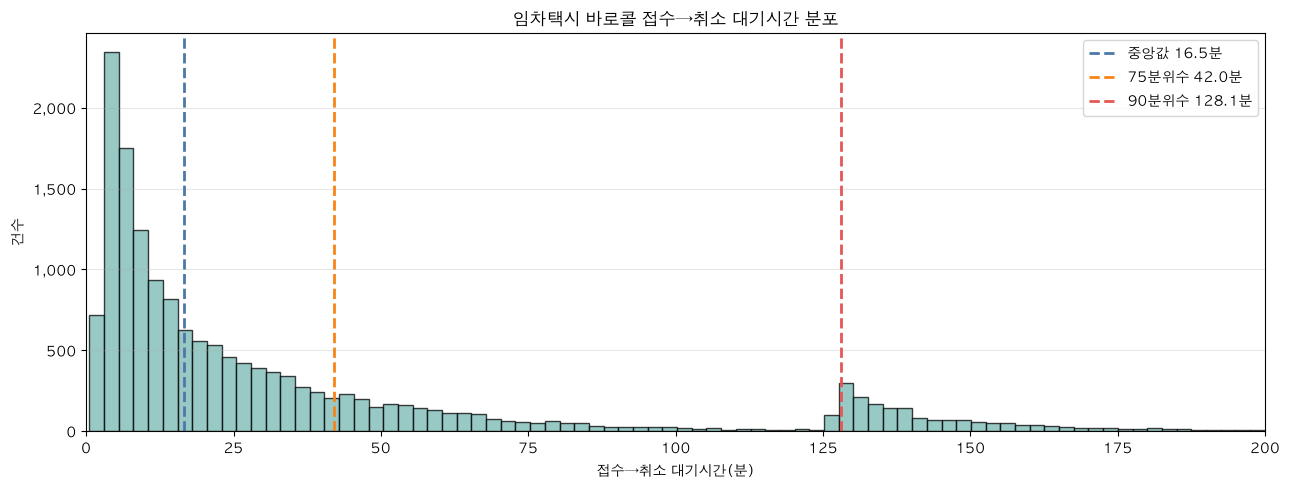

In [123]:
# 코드 셀 목적: 임차택시 바로콜 취소 건의 접수→취소 대기시간 분포와 주요 분위수를 확인한다.

from matplotlib.ticker import FuncFormatter

rental_cancel_wait = rental_cancel_normal["접수_취소_분"].dropna()
rental_cancel_wait = pd.to_numeric(rental_cancel_wait, errors="coerce").dropna()
rental_cancel_wait = rental_cancel_wait[rental_cancel_wait.between(0, 200)]

rental_cancel_quantiles = {
    "중앙값": rental_cancel_wait.median(),
    "75분위수": rental_cancel_wait.quantile(0.75),
    "90분위수": rental_cancel_wait.quantile(0.90),
}

display(
    pd.DataFrame({
        "지표": rental_cancel_quantiles.keys(),
        "접수→취소 대기시간(분)": rental_cancel_quantiles.values(),
    })
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(
    rental_cancel_wait,
    bins=80,
    color="#76b7b2",
    edgecolor="black",
    alpha=0.75,
)

quantile_styles = {
    "중앙값": "#4c78a8",
    "75분위수": "#f58518",
    "90분위수": "#e45756",
}

for label, value in rental_cancel_quantiles.items():
    ax.axvline(
        value,
        color=quantile_styles[label],
        linestyle="--",
        linewidth=2,
        label=f"{label} {value:.1f}분",
    )

ax.set_title("임차택시 바로콜 접수→취소 대기시간 분포")
ax.set_xlabel("접수→취소 대기시간(분)")
ax.set_ylabel("건수")
ax.set_xlim(0, 200)
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

임차택시 바로콜 취소는 접수 후 초반 구간에 많이 발생하며, 시간이 지날수록 취소 건수가 감소하는 형태를 보인다. 다만 접수 후 120~150분 구간에도 일부 취소가 관찰되어 장시간 대기 후 취소된 사례가 존재한다.

한편 `배차→취소` 시간은 대부분 0~10분 이내에 집중되어 있다. 이는 취소 건의 대부분이 데이터상 배차 후 취소로 기록되어 있더라도, 배차 이후 오랜 시간이 지난 뒤 취소된 것이 아니라 배차 직후 취소 처리된 경우가 많다는 것을 의미한다. 따라서 임차택시 취소 원인은 단순히 배차 후 대기 문제로 보기보다, 접수 후 취소까지의 전체 시간과 배차 시점의 기록 방식을 함께 고려해 해석해야 한다.

## 4. 취소 발생 시간 구간 분석

`접수→취소` 시간을 구간화해 어느 시점에 취소가 많이 발생하는지 확인한다.

취소 본 분석은 임차택시 바로콜 취소인 `rental_cancel_normal`을 대상으로 한다. 예약성 예외 취소는 본 분석에서 제외하고, 필요 시 건수만 비교한다.

추천 구간:

- 0~10분
- 10~20분
- 20~30분
- 30~60분
- 60~90분
- 90~120분
- 120~180분
- 180~250분
- 250분 초과

확인할 내용:

- 구간별 취소 건수
- 구간별 취소 비율
- 구간별 누적 취소 비율
- 30분 이내 취소 비율
- 60분 이내 취소 비율
- 120분 이후 장시간 취소 비율

분석 근거:

평균 취소시간만 보면 취소가 실제로 어느 시점에 몰리는지 알기 어렵다. 시간 구간별 분포와 누적 비율을 보면 `접수 후 몇 분 이내에 취소가 집중되는지`와 `긴 대기 이후 취소가 얼마나 존재하는지`를 함께 확인할 수 있다.

In [124]:
# 접수→취소 시간 구간 생성
cancel_bins = [0, 10, 20, 30, 60, 90, 120, 180, 250, float("inf")]
cancel_labels = [
    "0~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120~180분",
    "180~250분",
    "250분 초과",
]

rental_cancel_normal["접수_취소_구간"] = pd.cut(
    rental_cancel_normal["접수_취소_분"],
    bins=cancel_bins,
    labels=cancel_labels,
    right=False,
)

In [125]:
# 구간별 취소 건수·비율·누적 비율
cancel_time_bin_summary = (
    rental_cancel_normal["접수_취소_구간"]
    .value_counts(sort=False)
    .reset_index()
)

cancel_time_bin_summary.columns = [
    "접수→취소 구간",
    "취소건수",
]

cancel_time_bin_summary["취소비율(%)"] = (
    cancel_time_bin_summary["취소건수"]
    / cancel_time_bin_summary["취소건수"].sum()
    * 100
)

cancel_time_bin_summary["누적취소건수"] = (
    cancel_time_bin_summary["취소건수"].cumsum()
)

cancel_time_bin_summary["누적취소비율(%)"] = (
    cancel_time_bin_summary["취소비율(%)"].cumsum()
)

display(cancel_time_bin_summary)

,접수→취소 구간,취소건수,취소비율(%),누적취소건수,누적취소비율(%)
0,0~10분,5853,36.167583,5853,36.167583
1,10~20분,3036,18.760428,8889,54.928011
2,20~30분,1826,11.283446,10715,66.211456
3,30~60분,2635,16.282519,13350,82.493975
4,60~90분,821,5.073225,14171,87.567200
5,90~120분,191,1.180251,14362,88.747451
6,120~180분,1718,10.616079,16080,99.363530
7,180~250분,103,0.636470,16183,100.000000
8,250분 초과,0,0.000000,16183,100.000000


In [126]:
# 주요 기준별 누적 취소 비율 확인
cancel_threshold_summary = pd.DataFrame({
    "기준": [
        "10분 이내",
        "20분 이내",
        "30분 이내",
        "60분 이내",
        "90분 이내",
        "120분 이내",
        "180분 이내",
        "250분 이내",
        "250분 초과",
    ],
    "건수": [
        (rental_cancel_normal["접수_취소_분"] < 10).sum(),
        (rental_cancel_normal["접수_취소_분"] < 20).sum(),
        (rental_cancel_normal["접수_취소_분"] < 30).sum(),
        (rental_cancel_normal["접수_취소_분"] < 60).sum(),
        (rental_cancel_normal["접수_취소_분"] < 90).sum(),
        (rental_cancel_normal["접수_취소_분"] < 120).sum(),
        (rental_cancel_normal["접수_취소_분"] < 180).sum(),
        (rental_cancel_normal["접수_취소_분"] < 250).sum(),
        (rental_cancel_normal["접수_취소_분"] >= 250).sum(),
    ],
})

cancel_threshold_summary["비율(%)"] = (
    cancel_threshold_summary["건수"]
    / len(rental_cancel_normal)
    * 100
)

display(cancel_threshold_summary)

,기준,건수,비율(%)
0,10분 이내,5853,36.167583
1,20분 이내,8889,54.928011
2,30분 이내,10715,66.211456
3,60분 이내,13350,82.493975
4,90분 이내,14171,87.567200
5,120분 이내,14362,88.747451
6,180분 이내,16080,99.363530
7,250분 이내,16183,100.000000
8,250분 초과,0,0.000000


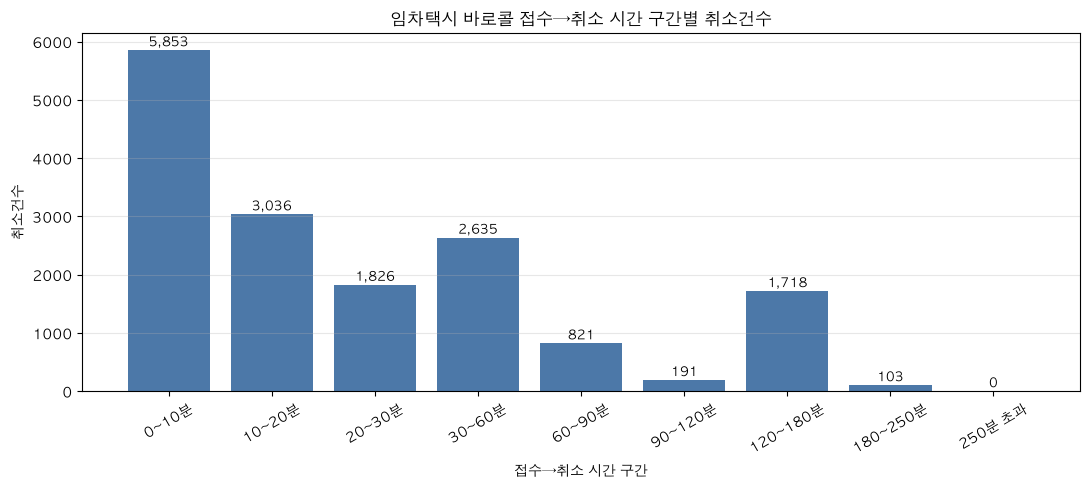

In [127]:
# 구간별 취소 건수 막대그래프
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    cancel_time_bin_summary["접수→취소 구간"].astype(str),
    cancel_time_bin_summary["취소건수"],
    color="#4c78a8",
)

for i, row in cancel_time_bin_summary.iterrows():
    ax.text(
        i,
        row["취소건수"],
        f'{row["취소건수"]:,}',
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("임차택시 바로콜 접수→취소 시간 구간별 취소건수")
ax.set_xlabel("접수→취소 시간 구간")
ax.set_ylabel("취소건수")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

0~10분, 10~20분 구간이 높다
- 접수 직후 또는 초기 대기 중 취소가 많이 발생 => 단순히 오래 기다려서만 취소한 것은 아님

30~60분, 60~90분 구간도 높다
- 일정 시간 기다린 뒤 취소하는 흐름 존재 => 배차 지연 또는 이용 상황 변경 가능성

120분 이후 구간이 작지만 남아 있다
- 장시간 대기 후 취소 사례 존재 => 평균을 끌어올리는 긴 꼬리 구간

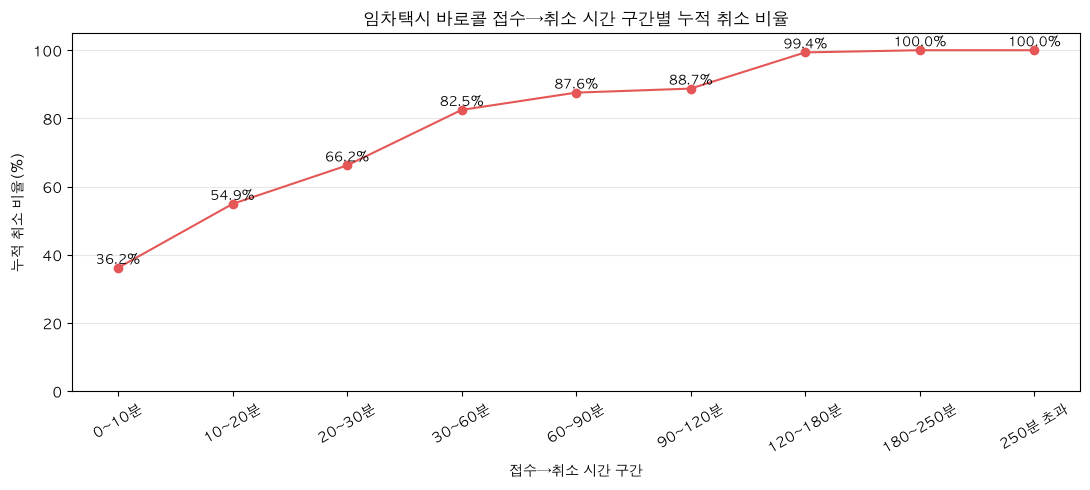

In [128]:
# 누적 취소 비율 선그래프
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    cancel_time_bin_summary["접수→취소 구간"].astype(str),
    cancel_time_bin_summary["누적취소비율(%)"],
    marker="o",
    color="#e45756",
)

for i, row in cancel_time_bin_summary.iterrows():
    ax.text(
        i,
        row["누적취소비율(%)"],
        f'{row["누적취소비율(%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("임차택시 바로콜 접수→취소 시간 구간별 누적 취소 비율")
ax.set_xlabel("접수→취소 시간 구간")
ax.set_ylabel("누적 취소 비율(%)")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

30분 이내 누적 취소 비율이 높다
- 취소 대부분이 초기 30분 안에 발생

60분 이내 누적 취소 비율이 대부분을 차지한다
- 임차택시 바로콜 취소는 장시간 대기보다 초기 대기 구간에서 많이 발생

임차택시 바로콜 취소는 접수 후 특정 장시간 구간에만 몰리기보다, 접수 초기 구간에서 많이 발생하는 경향을 보인다. 구간별 취소건수를 보면 초기 대기 구간의 비중이 크고, 시간이 길어질수록 취소건수는 감소하는 형태를 보인다.

누적 취소 비율을 함께 보면 취소가 몇 분 이내에 대부분 누적되는지 확인할 수 있다. 따라서 평균 취소시간만으로 “오래 기다려서 취소했다”고 단정하기보다는, 초기 취소와 장시간 취소를 구분해 해석하는 것이 적절하다.

특히 앞선 분석에서 `배차→취소` 시간이 짧게 나타났으므로, 취소건 대부분은 데이터상 배차 후 취소로 기록되어 있더라도 배차 이후 장시간 대기 후 취소된 것이라기보다는 접수 후 대기 중이거나 배차 직후 취소 처리된 흐름일 가능성이 있다.

,접수시간대_HH,취소건수,접수_취소_중앙값,접수_취소_75분위수,접수_취소_90분위수
0,00,NaN,NaN,NaN,NaN
1,01,NaN,NaN,NaN,NaN
2,02,1.0,234.965167,234.965167,234.965167
3,03,274.0,132.598333,145.207750,161.404765
4,04,321.0,138.380383,148.260167,161.474833
5,05,554.0,130.915467,142.586317,160.783865
6,06,491.0,23.952283,131.655050,155.961783
7,07,1155.0,13.883333,36.163975,64.763780
8,08,867.0,30.739450,56.698775,80.576667
9,09,796.0,23.644642,46.054629,70.663083


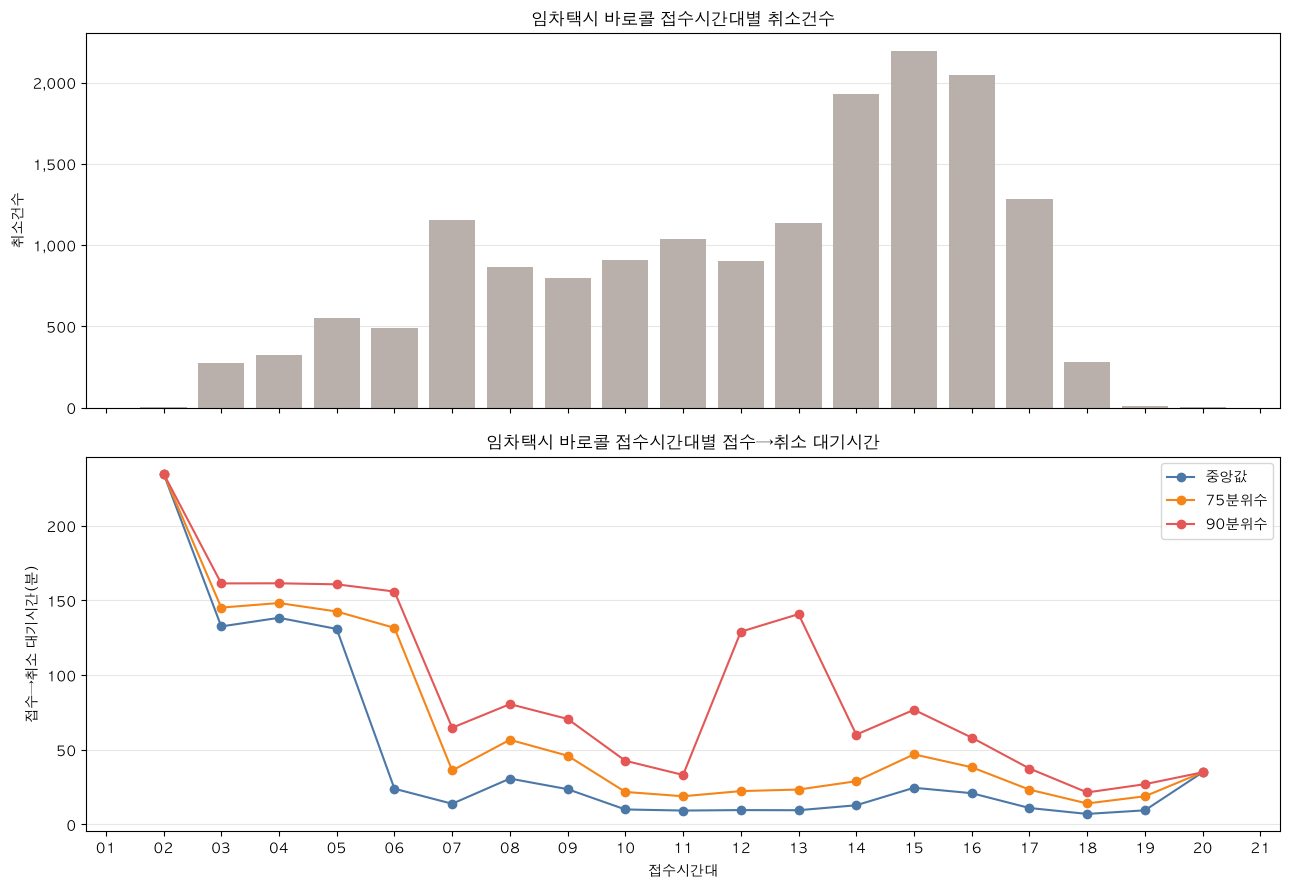

In [129]:
# 코드 셀 목적: 임차택시 바로콜 취소 건의 접수시간대별 접수→취소 대기시간 분위수를 확인한다.

rental_cancel_by_hour = rental_cancel_normal.copy()

rental_cancel_by_hour["접수일시"] = pd.to_datetime(
    rental_cancel_by_hour["접수일시"],
    errors="coerce",
)
rental_cancel_by_hour["접수시간대_HH"] = (
    rental_cancel_by_hour["접수일시"]
    .dt.strftime("%H")
)

rental_cancel_by_hour["접수_취소_분"] = pd.to_numeric(
    rental_cancel_by_hour["접수_취소_분"],
    errors="coerce",
)

hour_order = [f"{hour:02d}" for hour in range(24)]

rental_cancel_hour_summary = (
    rental_cancel_by_hour
    .groupby("접수시간대_HH", observed=False)
    .agg(
        취소건수=("접수_취소_분", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        접수_취소_75분위수=("접수_취소_분", lambda x: x.quantile(0.75)),
        접수_취소_90분위수=("접수_취소_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
    .reset_index()
)

display(rental_cancel_hour_summary)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].bar(
    rental_cancel_hour_summary["접수시간대_HH"],
    rental_cancel_hour_summary["취소건수"],
    color="#bab0ab",
)
axes[0].set_title("임차택시 바로콜 접수시간대별 취소건수")
axes[0].set_ylabel("취소건수")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(
    rental_cancel_hour_summary["접수시간대_HH"],
    rental_cancel_hour_summary["접수_취소_중앙값"],
    marker="o",
    label="중앙값",
    color="#4c78a8",
)
axes[1].plot(
    rental_cancel_hour_summary["접수시간대_HH"],
    rental_cancel_hour_summary["접수_취소_75분위수"],
    marker="o",
    label="75분위수",
    color="#f58518",
)
axes[1].plot(
    rental_cancel_hour_summary["접수시간대_HH"],
    rental_cancel_hour_summary["접수_취소_90분위수"],
    marker="o",
    label="90분위수",
    color="#e45756",
)

axes[1].set_title("임차택시 바로콜 접수시간대별 접수→취소 대기시간")
axes[1].set_xlabel("접수시간대")
axes[1].set_ylabel("접수→취소 대기시간(분)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

,접수시간대_HH,취소건수,중앙값,p75,p90
0,00,NaN,NaN,NaN,NaN
1,01,NaN,NaN,NaN,NaN
2,02,NaN,NaN,NaN,NaN
3,03,270.0,131.592750,144.708625,158.801645
4,04,320.0,138.353967,148.164329,160.792828
5,05,551.0,130.877217,141.985500,158.723950
6,06,489.0,23.762783,131.512167,155.370493
7,07,1153.0,13.851383,35.933333,63.997350
8,08,867.0,30.739450,56.698775,80.576667
9,09,796.0,23.644642,46.054629,70.663083


접수_취소_구간,0~5분,5~10분,10~20분,20~30분,30~60분,60~90분,90~120분,120~180분,180~200분
접수시간대_HH,,,,,,,,,
00,0,0,0,0,0,0,0,0,0
01,0,0,0,0,0,0,0,0,0
02,0,0,0,0,0,0,0,0,0
03,0,0,0,0,0,0,0,260,10
04,0,0,0,0,0,2,0,313,5
05,4,15,24,15,82,33,7,355,16
06,85,73,70,32,59,24,5,133,8
07,248,241,190,127,210,81,7,48,1
08,91,109,131,97,243,138,22,36,0


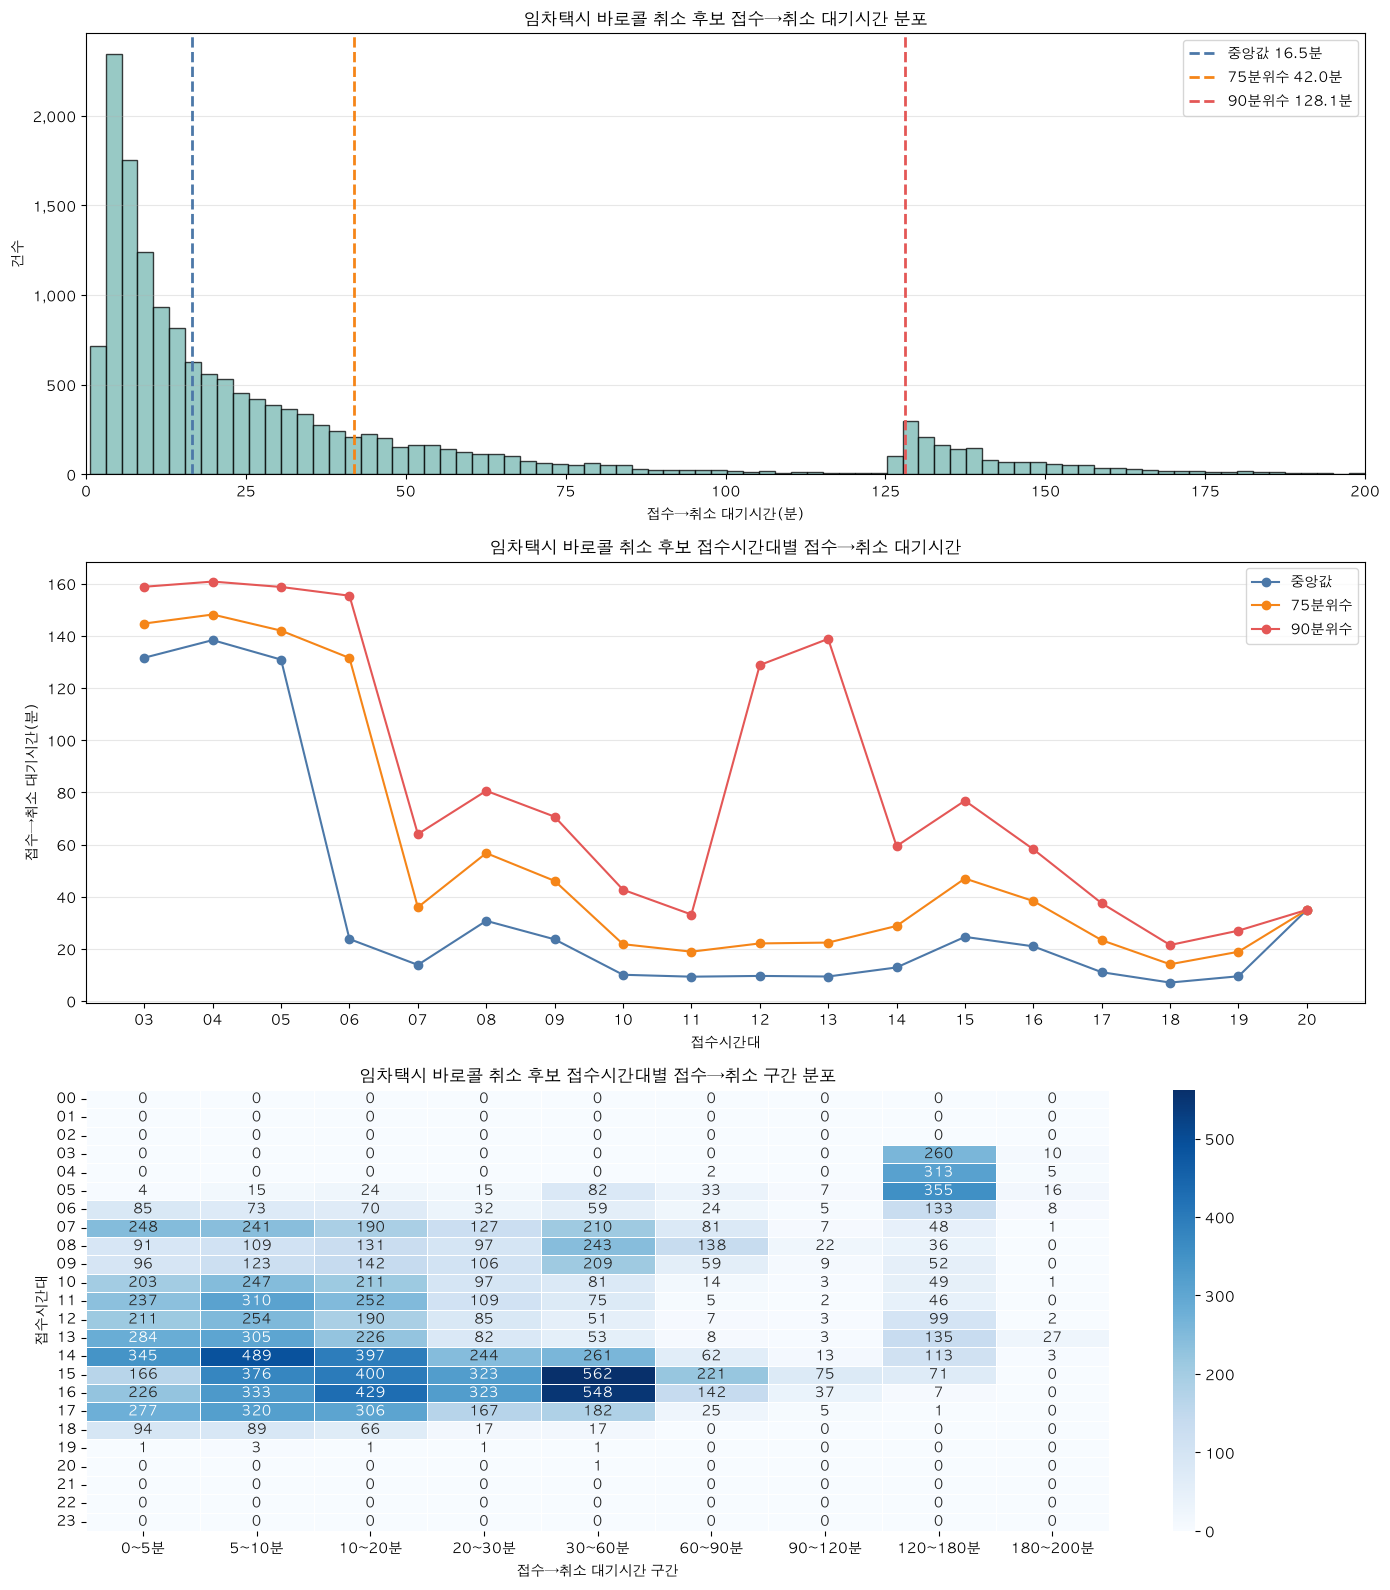

In [130]:
# 코드 셀 목적: 임차택시 바로콜 취소 건의 접수→취소 대기시간 분포, 접수시간대별 분위수, 구간 분포를 함께 확인한다.

from matplotlib.ticker import FuncFormatter

rental_cancel_wait_data = rental_cancel_normal.copy()

rental_cancel_wait_data["접수일시"] = pd.to_datetime(
    rental_cancel_wait_data["접수일시"],
    errors="coerce",
)
rental_cancel_wait_data["접수시간대_HH"] = (
    rental_cancel_wait_data["접수일시"]
    .dt.strftime("%H")
)

rental_cancel_wait_data["접수_취소_분"] = pd.to_numeric(
    rental_cancel_wait_data["접수_취소_분"],
    errors="coerce",
)

rental_cancel_wait = rental_cancel_wait_data["접수_취소_분"].dropna()
rental_cancel_wait = rental_cancel_wait[rental_cancel_wait.between(0, 200)]

rental_cancel_quantiles = {
    "중앙값": rental_cancel_wait.median(),
    "75분위수": rental_cancel_wait.quantile(0.75),
    "90분위수": rental_cancel_wait.quantile(0.90),
}

hour_order = [f"{hour:02d}" for hour in range(24)]

rental_cancel_hour_summary = (
    rental_cancel_wait_data[
        rental_cancel_wait_data["접수_취소_분"].between(0, 200)
    ]
    .groupby("접수시간대_HH", observed=False)
    .agg(
        취소건수=("접수_취소_분", "count"),
        중앙값=("접수_취소_분", "median"),
        p75=("접수_취소_분", lambda x: x.quantile(0.75)),
        p90=("접수_취소_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
    .reset_index()
)

cancel_bins = [0, 5, 10, 20, 30, 60, 90, 120, 180, 200]
cancel_labels = [
    "0~5분",
    "5~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60~90분",
    "90~120분",
    "120~180분",
    "180~200분",
]

rental_cancel_wait_data["접수_취소_구간"] = pd.cut(
    rental_cancel_wait_data["접수_취소_분"],
    bins=cancel_bins,
    labels=cancel_labels,
    right=True,
    include_lowest=True,
)

rental_cancel_heatmap = (
    rental_cancel_wait_data
    .pivot_table(
        index="접수시간대_HH",
        columns="접수_취소_구간",
        values="접수_취소_분",
        aggfunc="count",
        observed=False,
    )
    .reindex(index=hour_order, columns=cancel_labels)
    .fillna(0)
    .astype(int)
)

display(rental_cancel_hour_summary)
display(rental_cancel_heatmap)

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

axes[0].hist(
    rental_cancel_wait,
    bins=80,
    color="#76b7b2",
    edgecolor="black",
    alpha=0.75,
)

quantile_colors = {
    "중앙값": "#4c78a8",
    "75분위수": "#f58518",
    "90분위수": "#e45756",
}

for label, value in rental_cancel_quantiles.items():
    axes[0].axvline(
        value,
        color=quantile_colors[label],
        linestyle="--",
        linewidth=2,
        label=f"{label} {value:.1f}분",
    )

axes[0].set_title("임차택시 바로콜 취소 후보 접수→취소 대기시간 분포")
axes[0].set_xlabel("접수→취소 대기시간(분)")
axes[0].set_ylabel("건수")
axes[0].set_xlim(0, 200)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].plot(
    rental_cancel_hour_summary["접수시간대_HH"],
    rental_cancel_hour_summary["중앙값"],
    marker="o",
    label="중앙값",
    color="#4c78a8",
)
axes[1].plot(
    rental_cancel_hour_summary["접수시간대_HH"],
    rental_cancel_hour_summary["p75"],
    marker="o",
    label="75분위수",
    color="#f58518",
)
axes[1].plot(
    rental_cancel_hour_summary["접수시간대_HH"],
    rental_cancel_hour_summary["p90"],
    marker="o",
    label="90분위수",
    color="#e45756",
)

axes[1].set_title("임차택시 바로콜 취소 후보 접수시간대별 접수→취소 대기시간")
axes[1].set_xlabel("접수시간대")
axes[1].set_ylabel("접수→취소 대기시간(분)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

sns.heatmap(
    rental_cancel_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=axes[2],
)

axes[2].set_title("임차택시 바로콜 취소 후보 접수시간대별 접수→취소 구간 분포")
axes[2].set_xlabel("접수→취소 대기시간 구간")
axes[2].set_ylabel("접수시간대")

plt.tight_layout()
plt.show()

임차택시 바로콜 취소는 크게 두 패턴으로 나뉜다.

1. 접수 직후~1시간 이내 취소
   - 주로 낮 시간대에 많음
   - 단순 변심, 중복 호출, 다른 이동수단 확보, 짧은 대기 후 포기 가능성

2. 120~180분 장시간 대기 후 취소
   - 주로 새벽 03~06시에 집중
   - 장시간 미배차 후 취소 또는 운영상 취소 처리 가능성

따라서 임차택시 바로콜 취소는 평균 하나로 해석하면 안 된다.
특히 새벽 시간대는 취소건수가 낮 시간대보다 많지 않더라도,
취소까지 걸린 시간이 매우 길어 이용자 체감 실패 위험이 큰 시간대로 볼 수 있다.

,접수시간대_HH,탑승완료건수,취소건수,접수_취소_중앙값,접수_취소_75분위수,접수_취소_90분위수,취소율(%)
0,00,0,0.0,NaN,NaN,NaN,NaN
1,01,0,0.0,NaN,NaN,NaN,NaN
2,02,44,1.0,234.965167,234.965167,234.965167,2.222222
3,03,2760,274.0,132.598333,145.207750,161.404765,9.030982
4,04,5019,321.0,138.380383,148.260167,161.474833,6.011236
5,05,4106,554.0,130.915467,142.586317,160.783865,11.888412
6,06,4785,491.0,23.952283,131.655050,155.961783,9.306293
7,07,12702,1155.0,13.883333,36.163975,64.763780,8.335137
8,08,12438,867.0,30.739450,56.698775,80.576667,6.516347
9,09,18390,796.0,23.644642,46.054629,70.663083,4.148859


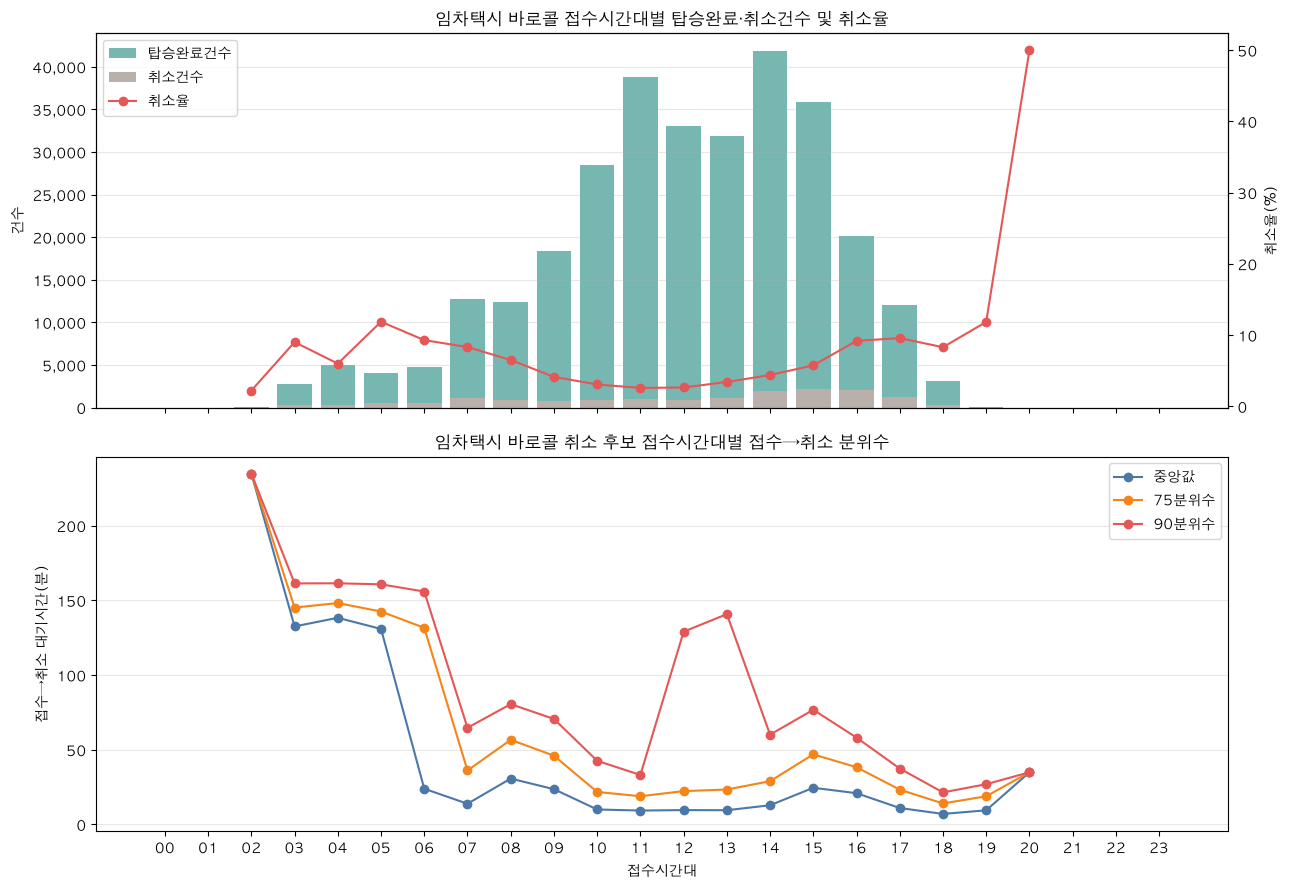

In [131]:
# 코드 셀 목적: 임차택시 바로콜의 접수시간대별 탑승완료·취소건수 및 취소율, 접수→취소 대기시간 분위수를 확인한다.

from matplotlib.ticker import FuncFormatter

# 탑승완료 건
rental_ride_by_hour = rental_ride_normal.copy()
rental_ride_by_hour["접수일시"] = pd.to_datetime(
    rental_ride_by_hour["접수일시"],
    errors="coerce",
)
rental_ride_by_hour["접수시간대_HH"] = rental_ride_by_hour["접수일시"].dt.strftime("%H")

# 취소 건
rental_cancel_by_hour = rental_cancel_normal.copy()
rental_cancel_by_hour["접수일시"] = pd.to_datetime(
    rental_cancel_by_hour["접수일시"],
    errors="coerce",
)
rental_cancel_by_hour["접수시간대_HH"] = rental_cancel_by_hour["접수일시"].dt.strftime("%H")
rental_cancel_by_hour["접수_취소_분"] = pd.to_numeric(
    rental_cancel_by_hour["접수_취소_분"],
    errors="coerce",
)

hour_order = [f"{hour:02d}" for hour in range(24)]

ride_hour_count = (
    rental_ride_by_hour
    .groupby("접수시간대_HH", observed=False)
    .size()
    .reindex(hour_order, fill_value=0)
    .rename("탑승완료건수")
)

cancel_hour_summary = (
    rental_cancel_by_hour
    .groupby("접수시간대_HH", observed=False)
    .agg(
        취소건수=("접수_취소_분", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        접수_취소_75분위수=("접수_취소_분", lambda x: x.quantile(0.75)),
        접수_취소_90분위수=("접수_취소_분", lambda x: x.quantile(0.90)),
    )
    .reindex(hour_order)
)

rental_baro_cancel_hour_summary = (
    pd.concat([ride_hour_count, cancel_hour_summary], axis=1)
    .reset_index()
    .rename(columns={"index": "접수시간대_HH"})
)

rental_baro_cancel_hour_summary["취소건수"] = (
    rental_baro_cancel_hour_summary["취소건수"]
    .fillna(0)
)

rental_baro_cancel_hour_summary["취소율(%)"] = (
    rental_baro_cancel_hour_summary["취소건수"]
    / (
        rental_baro_cancel_hour_summary["탑승완료건수"]
        + rental_baro_cancel_hour_summary["취소건수"]
    )
    * 100
)

display(rental_baro_cancel_hour_summary)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

x = rental_baro_cancel_hour_summary["접수시간대_HH"]

axes[0].bar(
    x,
    rental_baro_cancel_hour_summary["탑승완료건수"],
    color="#76b7b2",
    label="탑승완료건수",
)

axes[0].bar(
    x,
    rental_baro_cancel_hour_summary["취소건수"],
    color="#bab0ab",
    label="취소건수",
)

ax0_right = axes[0].twinx()
ax0_right.plot(
    x,
    rental_baro_cancel_hour_summary["취소율(%)"],
    marker="o",
    color="#e45756",
    label="취소율",
)

axes[0].set_title("임차택시 바로콜 접수시간대별 탑승완료·취소건수 및 취소율")
axes[0].set_ylabel("건수")
ax0_right.set_ylabel("취소율(%)")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)

lines_0, labels_0 = axes[0].get_legend_handles_labels()
lines_1, labels_1 = ax0_right.get_legend_handles_labels()
axes[0].legend(lines_0 + lines_1, labels_0 + labels_1, loc="upper left")

axes[1].plot(
    x,
    rental_baro_cancel_hour_summary["접수_취소_중앙값"],
    marker="o",
    label="중앙값",
    color="#4c78a8",
)

axes[1].plot(
    x,
    rental_baro_cancel_hour_summary["접수_취소_75분위수"],
    marker="o",
    label="75분위수",
    color="#f58518",
)

axes[1].plot(
    x,
    rental_baro_cancel_hour_summary["접수_취소_90분위수"],
    marker="o",
    label="90분위수",
    color="#e45756",
)

axes[1].set_title("임차택시 바로콜 취소 후보 접수시간대별 접수→취소 분위수")
axes[1].set_xlabel("접수시간대")
axes[1].set_ylabel("접수→취소 대기시간(분)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

임차택시 바로콜 취소가 많이 나는 시간대와 오래 기다린 뒤 취소되는 시간대가 다르다는 걸 보여줘.
- 실제 이용량은 10~16시에 집중됨
  - 탑승완료건수는 11~15시에 가장 많고, 특히 14시가 가장 큼.
  - 취소건수도 낮 시간대에 함께 늘어나지만, 탑승완료건수 대비로 보면 취소율은 낮은 편임.
  - 즉 낮 시간대는 “많이 접수되고 많이 배차되는 주 이용 시간대”라서 취소건수도 따라 늘어나는 구조임.
- 취소율은 이용량이 적은 시간대에서 튀어 보임
  - 20시 취소율이 약 50%로 매우 높게 보이는데, 이 시간대는 탑승완료·취소건수 자체가 적어서 비율이 과장됐을 가능성이 큼.
  - 그래서 취소율만 보고 20시가 가장 위험하다고 단정하면 안 되고, 반드시 건수와 같이 봐야 함.
- 장시간 대기 후 취소는 새벽 02~06시가 핵심
  - 아래 그래프에서 02~06시의 접수→취소 중앙값, 75분위수, 90분위수가 모두 매우 높음.
  - 특히 02시는 중앙값·75분위수·90분위수가 거의 230분대에 가까워, 대부분이 오래 기다린 뒤 취소된 시간대로 보임.
  - 03~06시도 90분위수가 150분 안팎이라 장시간 대기 후 취소 경향이 강함.
- 낮 시간대 취소는 대부분 빠르게 발생
  - 07~11시, 14~19시는 중앙값이 대체로 낮음.
  - 이 시간대의 취소는 장시간 대기 후 포기라기보다, 접수 직후 또는 비교적 이른 시점에 취소되는 비중이 큼.
  - 다만 12~13시는 중앙값은 낮은데 90분위수가 다시 높아져, 대부분은 빨리 취소하지만 일부 장시간 대기 후 취소가 섞여 있음.
- 종합하면
  - 취소건수 多: 10~16시
  - 취소율 튐: 표본 적은 20시
  - 장시간 대기 후 취소: 02~06시
  - 빠른 취소 중심: 07~11시, 14~19시
네비게이터 지표로 쓰려면 임차택시 바로콜은 단순 취소율보다 접수시간대별 접수→취소 90분위수와 장시간 대기 후 취소 비율을 따로 보는 게 맞아.

## 5. 접수시간대별 임차택시 대기시간 분석

`접수일시`에서 시간대를 추출해 임차택시 대기시간이 긴 시간대를 확인한다.

승차 대기시간은 `rental_ride_normal`, 취소 대기시간은 `rental_cancel_normal`을 기준으로 분석한다.

확인할 내용:

- 접수시간대별 `접수→배차` 중앙값
- 접수시간대별 `접수→승차` 중앙값
- 접수시간대별 `접수→취소` 중앙값
- 접수시간대별 `배차→취소` 중앙값
- 보조 확인: 접수시간대별 `배차→승차` 중앙값
- 시간대별 승차 완료 건수
- 시간대별 취소 건수

분석 근거:

임차택시 바로콜은 접수 시점의 수요 집중, 차량 공급 상황, 도로 상황에 영향을 받을 수 있다. 접수시간대별 분석은 하루 중 대기시간이 길어지는 시점을 찾는 데 필요하다.

In [132]:
# 접수시간대 생성
rental_ride_normal["접수시간대"] = (
    rental_ride_normal["접수일시"]
    .dt.hour
    .astype(str)
    .str.zfill(2)
    + ":00:00"
)

rental_cancel_normal["접수시간대"] = (
    rental_cancel_normal["접수일시"]
    .dt.hour
    .astype(str)
    .str.zfill(2)
    + ":00:00"
)

In [133]:
# 접수시간대별 승차 대기시간 집계
hourly_ride_wait_summary = (
    rental_ride_normal
    .groupby("접수시간대")
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_승차_중앙값=("접수_승차_분", "median"),
        배차_승차_중앙값=("배차_승차_분", "median"),
        접수_배차_평균=("접수_배차_분", "mean"),
        접수_승차_평균=("접수_승차_분", "mean"),
    )
    .reset_index()
)

display(hourly_ride_wait_summary)

,접수시간대,승차완료건수,접수_배차_중앙값,접수_승차_중앙값,배차_승차_중앙값,접수_배차_평균,접수_승차_평균
0,02:00:00,44,188.662525,205.225442,15.387450,194.120740,210.427146
1,03:00:00,2760,133.952167,160.741200,21.722775,145.872710,168.963657
2,04:00:00,5019,134.519283,156.968000,18.764500,137.547678,157.384892
3,05:00:00,4106,71.393667,91.368658,20.161667,82.903461,103.950303
4,06:00:00,4785,33.982383,53.289900,18.908050,49.571023,69.423368
5,07:00:00,12702,32.249783,51.747117,19.313225,38.563095,58.669760
6,08:00:00,12438,41.676533,60.338917,18.111417,45.203530,63.997162
7,09:00:00,18390,24.061083,42.226083,17.160833,32.372099,50.409130
8,10:00:00,28488,4.805892,23.046725,15.814433,13.983552,30.674140
9,11:00:00,38848,3.908917,21.164800,15.406608,9.369032,25.485643


In [134]:
# 접수시간대별 취소 대기시간 집계
hourly_cancel_wait_summary = (
    rental_cancel_normal
    .groupby("접수시간대")
    .agg(
        취소건수=("접수_취소_분", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        배차_취소_중앙값=("배차_취소_분", "median"),
        접수_취소_평균=("접수_취소_분", "mean"),
        배차_취소_평균=("배차_취소_분", "mean"),
    )
    .reset_index()
)

display(hourly_cancel_wait_summary)

,접수시간대,취소건수,접수_취소_중앙값,배차_취소_중앙값,접수_취소_평균,배차_취소_평균
0,02:00:00,1,234.965167,7.952550,234.965167,7.952550
1,03:00:00,274,132.598333,2.402417,139.952221,4.176290
2,04:00:00,321,138.380383,3.090000,141.833913,5.513969
3,05:00:00,554,130.915467,2.520725,110.073621,4.389553
4,06:00:00,491,23.952283,2.759617,58.658027,4.977700
5,07:00:00,1155,13.883333,2.300000,26.853921,3.925697
6,08:00:00,867,30.739450,2.828783,38.372672,5.057813
7,09:00:00,796,23.644642,2.841417,34.205044,5.269186
8,10:00:00,906,10.066525,2.951950,21.329272,5.800196
9,11:00:00,1036,9.333392,3.485192,18.238342,6.534458


In [135]:
# 승차 완료건수와 취소건수 결합
hourly_wait_summary = pd.merge(
    hourly_ride_wait_summary,
    hourly_cancel_wait_summary,
    on="접수시간대",
    how="outer",
).sort_values("접수시간대")

display(hourly_wait_summary)

,접수시간대,승차완료건수,접수_배차_중앙값,접수_승차_중앙값,배차_승차_중앙값,접수_배차_평균,접수_승차_평균,취소건수,접수_취소_중앙값,배차_취소_중앙값,접수_취소_평균,배차_취소_평균
0,02:00:00,44,188.662525,205.225442,15.387450,194.120740,210.427146,1,234.965167,7.952550,234.965167,7.952550
1,03:00:00,2760,133.952167,160.741200,21.722775,145.872710,168.963657,274,132.598333,2.402417,139.952221,4.176290
2,04:00:00,5019,134.519283,156.968000,18.764500,137.547678,157.384892,321,138.380383,3.090000,141.833913,5.513969
3,05:00:00,4106,71.393667,91.368658,20.161667,82.903461,103.950303,554,130.915467,2.520725,110.073621,4.389553
4,06:00:00,4785,33.982383,53.289900,18.908050,49.571023,69.423368,491,23.952283,2.759617,58.658027,4.977700
5,07:00:00,12702,32.249783,51.747117,19.313225,38.563095,58.669760,1155,13.883333,2.300000,26.853921,3.925697
6,08:00:00,12438,41.676533,60.338917,18.111417,45.203530,63.997162,867,30.739450,2.828783,38.372672,5.057813
7,09:00:00,18390,24.061083,42.226083,17.160833,32.372099,50.409130,796,23.644642,2.841417,34.205044,5.269186
8,10:00:00,28488,4.805892,23.046725,15.814433,13.983552,30.674140,906,10.066525,2.951950,21.329272,5.800196
9,11:00:00,38848,3.908917,21.164800,15.406608,9.369032,25.485643,1036,9.333392,3.485192,18.238342,6.534458


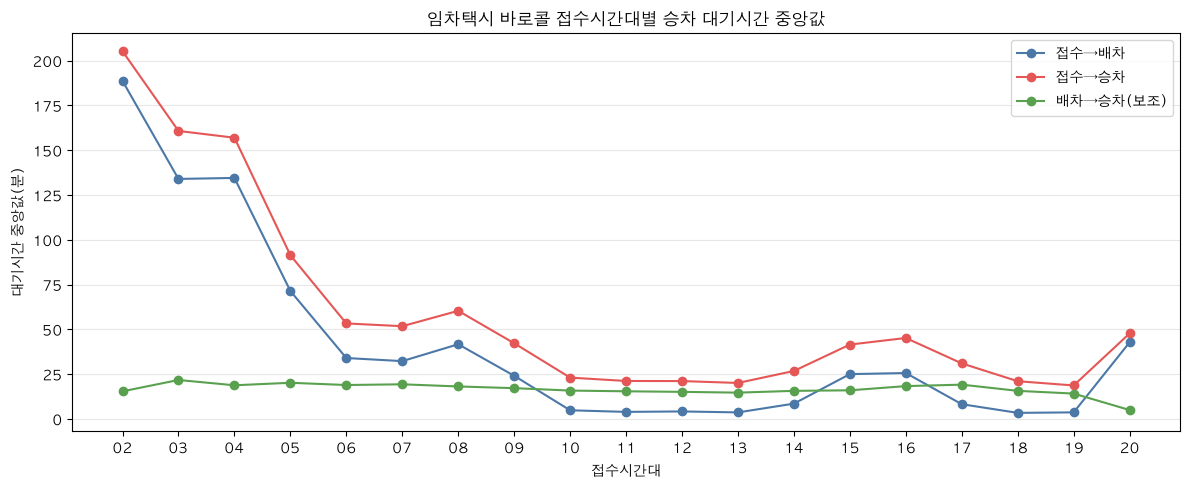

In [136]:
# 접수시간대별 승차 대기시간 선그래프
plot_data = hourly_ride_wait_summary.copy()

plot_data["접수시간_표시"] = (
    plot_data["접수시간대"]
    .astype(str)
    .str.slice(0, 2)
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_data["접수시간_표시"],
    plot_data["접수_배차_중앙값"],
    marker="o",
    label="접수→배차",
    color="#4c78a8",
)

ax.plot(
    plot_data["접수시간_표시"],
    plot_data["접수_승차_중앙값"],
    marker="o",
    label="접수→승차",
    color="#e45756",
)

ax.plot(
    plot_data["접수시간_표시"],
    plot_data["배차_승차_중앙값"],
    marker="o",
    label="배차→승차(보조)",
    color="#59a14f",
)

ax.set_title("임차택시 바로콜 접수시간대별 승차 대기시간 중앙값")
ax.set_xlabel("접수시간대")
ax.set_ylabel("대기시간 중앙값(분)")

ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [137]:
hourly_ride_wait_summary = (
    rental_ride_normal
    .groupby("접수시간대")
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_승차_평균=("접수_승차_분", "mean"),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        접수_배차_평균=("접수_배차_분", "mean"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

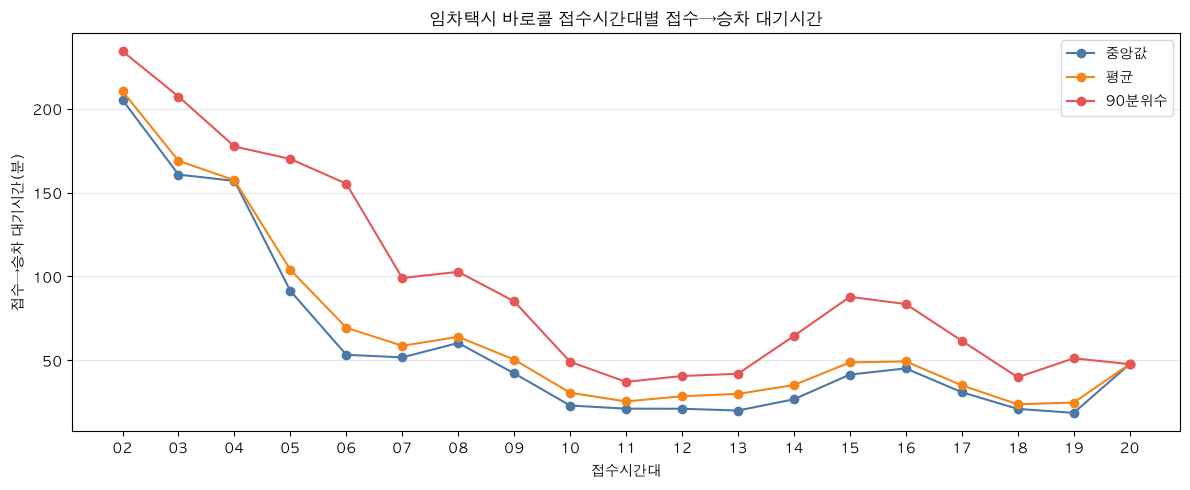

In [138]:
# 접수→승차 평균·중앙값·90분위수 그래프
plot_data = hourly_ride_wait_summary.copy()

plot_data["접수시간_표시"] = (
    plot_data["접수시간대"]
    .astype(str)
    .str.slice(0, 2)
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_data["접수시간_표시"],
    plot_data["접수_승차_중앙값"],
    marker="o",
    label="중앙값",
    color="#4c78a8",
)

ax.plot(
    plot_data["접수시간_표시"],
    plot_data["접수_승차_평균"],
    marker="o",
    label="평균",
    color="#f58518",
)

ax.plot(
    plot_data["접수시간_표시"],
    plot_data["접수_승차_90분위수"],
    marker="o",
    label="90분위수",
    color="#e45756",
)

ax.set_title("임차택시 바로콜 접수시간대별 접수→승차 대기시간")
ax.set_xlabel("접수시간대")
ax.set_ylabel("접수→승차 대기시간(분)")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

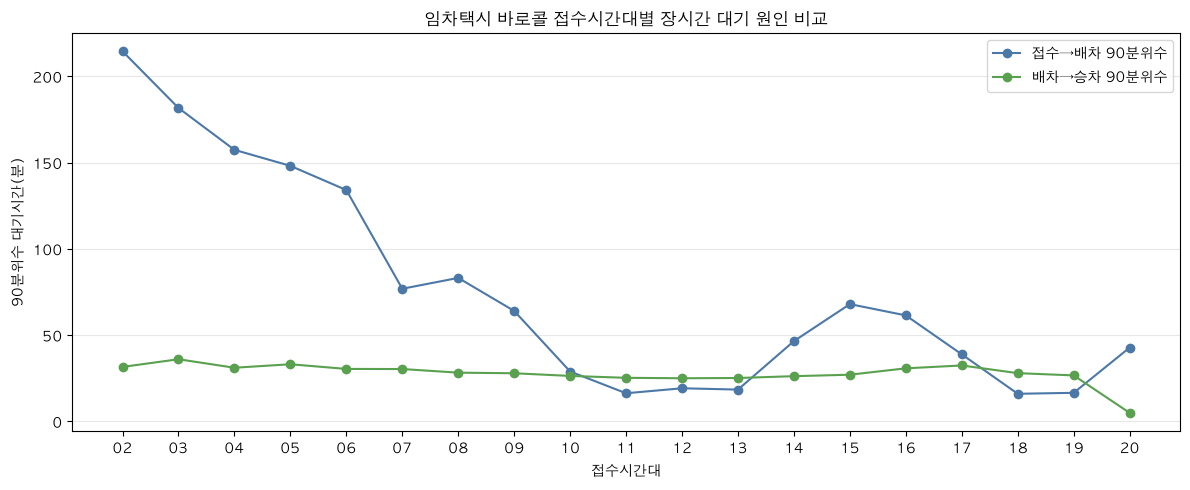

In [139]:
# 장시간 대기 원인 확인 그래프
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_data["접수시간_표시"],
    plot_data["접수_배차_90분위수"],
    marker="o",
    label="접수→배차 90분위수",
    color="#4c78a8",
)

ax.plot(
    plot_data["접수시간_표시"],
    plot_data["배차_승차_90분위수"],
    marker="o",
    label="배차→승차 90분위수",
    color="#59a14f",
)

ax.set_title("임차택시 바로콜 접수시간대별 장시간 대기 원인 비교")
ax.set_xlabel("접수시간대")
ax.set_ylabel("90분위수 대기시간(분)")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**1. 새벽·이른 아침 접수는 대기시간이 매우 김**

`02~06시` 구간에서 `접수→승차` 대기시간이 가장 길다 ⇒ **해당 시간대에 접수는 가능하지만 실제 배차가 원활하지 않은 시간대**로 추정. 임차택시 운영/공급이 적거나, 첫 운행 시작 전 접수가 누적되는 영향일 수 있어.

**2. 긴 대기의 원인은 배차 후가 아니라 배차 전**

세 번째 그래프가 제일 중요해.

`접수→배차 90분위수`가 `배차→승차 90분위수`보다 훨씬 크게 튄다(3번 그래프)

특히 `02~06시`에는 `접수→배차 90분위수`가 매우 높고, 반면 `배차→승차 90분위수`는 대체로 25~35분 수준에서 크게 흔들리지 않음

```
차가 배정된 뒤 늦게 타는 문제가 아니라
차가 배정되기까지 오래 걸리는 문제가 큼
```

**3. 낮 시간대는 비교적 안정적**

`10~13시`는 가장 안정적인 구간 ⇒ 이 시간대는 임차택시 바로콜이 비교적 원활하게 작동하는 시간대로 추정

**4. 오후 15~16시에 다시 대기시간이 증가**

`15~16시`에 접수→승차 평균과 90분위수가 다시 올라가.

세 번째 그래프에서도 이 시간대에 `접수→배차 90분위수`가 올라가니까, 오후에도 일부 시간대에서 **배차 지연성 장시간 대기**가 발생하는 것으로 보임.

다만 새벽처럼 전체적으로 심한 수준은 아니고, 일부 장시간 건이 평균과 90분위수를 끌어올리는 형태에 가까움

**5. 20시는 해석 주의**

20시는 값이 다시 올라가는데, 이 시간대 이후 데이터가 없거나 표본 수가 적을 가능성이 있어 보임. 그래서 20시는 반드시 **승차완료건수**를 같이 보고 해석해야 함. 표본 수가 적으면 중앙값이나 90분위수가 쉽게 튈 수 있음.

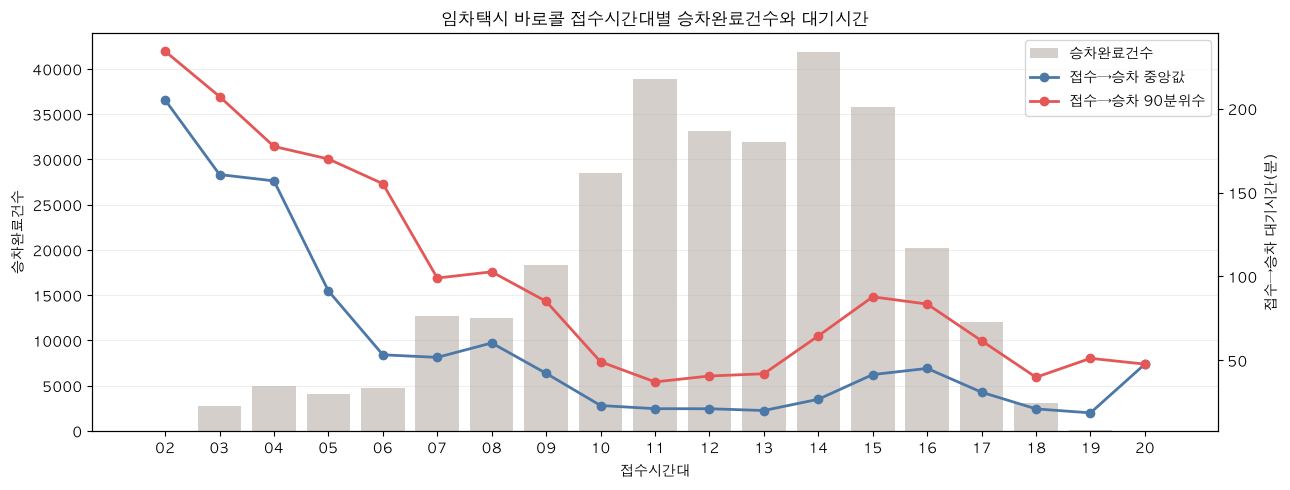

In [140]:
plot_data = hourly_ride_wait_summary.copy()

plot_data["접수시간_표시"] = (
    plot_data["접수시간대"]
    .astype(str)
    .str.slice(0, 2)
)

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(
    plot_data["접수시간_표시"],
    plot_data["승차완료건수"],
    color="#bab0ab",
    alpha=0.6,
    label="승차완료건수",
)

ax1.set_xlabel("접수시간대")
ax1.set_ylabel("승차완료건수")
ax1.tick_params(axis="y")
ax1.grid(axis="y", alpha=0.2)

ax2 = ax1.twinx()

ax2.plot(
    plot_data["접수시간_표시"],
    plot_data["접수_승차_중앙값"],
    marker="o",
    color="#4c78a8",
    linewidth=2,
    label="접수→승차 중앙값",
)

ax2.plot(
    plot_data["접수시간_표시"],
    plot_data["접수_승차_90분위수"],
    marker="o",
    color="#e45756",
    linewidth=2,
    label="접수→승차 90분위수",
)

ax2.set_ylabel("접수→승차 대기시간(분)")
ax2.tick_params(axis="y")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
)

ax1.set_title("임차택시 바로콜 접수시간대별 승차완료건수와 대기시간")

plt.tight_layout()
plt.show()

접수시간대별 승차완료건수와 `접수→승차` 대기시간을 함께 보면, 수요가 많은 시간대와 대기시간이 긴 시간대가 일치하지 않는다. 10~14시는 승차완료건수가 가장 많은 구간이지만 대기시간 중앙값과 90분위수는 낮아, 수요가 많음에도 비교적 안정적으로 처리되는 시간대로 해석된다.

반면 02~06시는 승차완료건수는 적지만 `접수→승차` 중앙값과 90분위수가 매우 높게 나타난다. 이는 전체 운영 부담보다는 소수 이용자가 장시간 대기하는 취약 시간대일 가능성이 크다.

15~16시는 승차완료건수가 비교적 많은 동시에 90분위수 대기시간이 다시 상승한다. 따라서 이 시간대는 수요 규모와 장시간 대기가 함께 나타나는 실질적인 병목 후보로 볼 수 있다. 20시는 대기시간이 상승하지만 표본 수가 적어 해석에 주의가 필요하다.

## 6. 요일별 임차택시 대기시간 분석

`접수일시`에서 요일을 추출해 요일별 차이를 확인한다.

승차 대기시간은 `rental_ride_normal`, 취소 대기시간은 `rental_cancel_normal`을 기준으로 분석한다.

확인할 내용:

- 요일별 승차 대기시간 핵심 구간
- 요일별 취소 대기시간
- 평일/주말 차이
- 요일별 승차 완료 건수
- 요일별 취소 건수

분석 근거:

평일과 주말은 이용 목적과 차량 운영 패턴이 다를 수 있다. 요일별 분석은 특정 요일에 임차택시 대기시간이 길어지는지 확인하기 위한 기본 분석이다.

In [141]:
# 요일 컬럼 생성
weekday_order = ["월", "화", "수", "목", "금", "토", "일"]

rental_ride_normal["접수요일"] = pd.Categorical(
    rental_ride_normal["접수일시"].dt.day_name().map({
        "Monday": "월",
        "Tuesday": "화",
        "Wednesday": "수",
        "Thursday": "목",
        "Friday": "금",
        "Saturday": "토",
        "Sunday": "일",
    }),
    categories=weekday_order,
    ordered=True,
)

rental_cancel_normal["접수요일"] = pd.Categorical(
    rental_cancel_normal["접수일시"].dt.day_name().map({
        "Monday": "월",
        "Tuesday": "화",
        "Wednesday": "수",
        "Thursday": "목",
        "Friday": "금",
        "Saturday": "토",
        "Sunday": "일",
    }),
    categories=weekday_order,
    ordered=True,
)

In [142]:
# 평일/주말 컬럼 생성
rental_ride_normal["평일주말"] = rental_ride_normal["접수요일"].apply(
    lambda x: "주말" if x in ["토", "일"] else "평일"
)

rental_cancel_normal["평일주말"] = rental_cancel_normal["접수요일"].apply(
    lambda x: "주말" if x in ["토", "일"] else "평일"
)

In [143]:
# 요일별 승차 대기시간 집계
weekday_ride_wait_summary = (
    rental_ride_normal
    .groupby("접수요일", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(weekday_ride_wait_summary)

,접수요일,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수
0,월,58664,8.322600,66.578172,26.862108,86.972680,16.006558,26.824103
1,화,58916,9.268892,64.238050,28.469858,84.685192,16.206758,27.213608
2,수,61267,9.927283,70.613050,29.409333,91.467477,16.308117,27.318413
3,목,57970,8.765917,64.468117,27.623583,85.389127,16.222692,27.412527
4,금,55756,9.617242,68.101858,29.207533,89.095750,16.412392,27.809142
5,토,8034,11.675800,64.431350,33.830275,86.055050,18.504833,30.324748
6,일,5122,11.957000,63.370833,33.202808,83.052445,17.655500,27.815357


In [144]:
# 요일별 취소 대기시간 집계
weekday_cancel_wait_summary = (
    rental_cancel_normal
    .groupby("접수요일", observed=False)
    .agg(
        취소건수=("접수_취소_분", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        접수_취소_90분위수=("접수_취소_분", lambda x: x.quantile(0.90)),
        배차_취소_중앙값=("배차_취소_분", "median"),
        배차_취소_90분위수=("배차_취소_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(weekday_cancel_wait_summary)

,접수요일,취소건수,접수_취소_중앙값,접수_취소_90분위수,배차_취소_중앙값,배차_취소_90분위수
0,월,3001,14.806783,106.743500,2.730217,12.311283
1,화,3140,16.766667,129.382683,2.617167,12.254157
2,수,3217,18.200000,126.722067,2.729883,11.673337
3,목,3140,15.808917,129.036510,2.653475,11.639133
4,금,2981,18.122333,130.021450,2.832283,12.426050
5,토,440,14.753308,100.088622,2.485617,11.611733
6,일,264,15.405392,68.543218,2.680025,13.780813


In [145]:
# 평일/주말 승차 대기시간 집계
weektype_ride_wait_summary = (
    rental_ride_normal
    .groupby("평일주말", observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(weektype_ride_wait_summary)

,평일주말,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수
0,주말,13156,11.82780,64.123725,33.622217,84.534083,18.159775,29.419508
1,평일,292573,9.20945,66.811623,28.307950,87.491317,16.213783,27.315157


In [146]:
# 평일/주말 취소 대기시간 집계
weektype_cancel_wait_summary = (
    rental_cancel_normal
    .groupby("평일주말", observed=False)
    .agg(
        취소건수=("접수_취소_분", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        접수_취소_90분위수=("접수_취소_분", lambda x: x.quantile(0.90)),
        배차_취소_중앙값=("배차_취소_분", "median"),
        배차_취소_90분위수=("배차_취소_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(weektype_cancel_wait_summary)

,평일주말,취소건수,접수_취소_중앙값,접수_취소_90분위수,배차_취소_중앙값,배차_취소_90분위수
0,주말,704,14.940192,79.697582,2.548217,12.574877
1,평일,15479,16.666667,128.729663,2.703050,12.064400


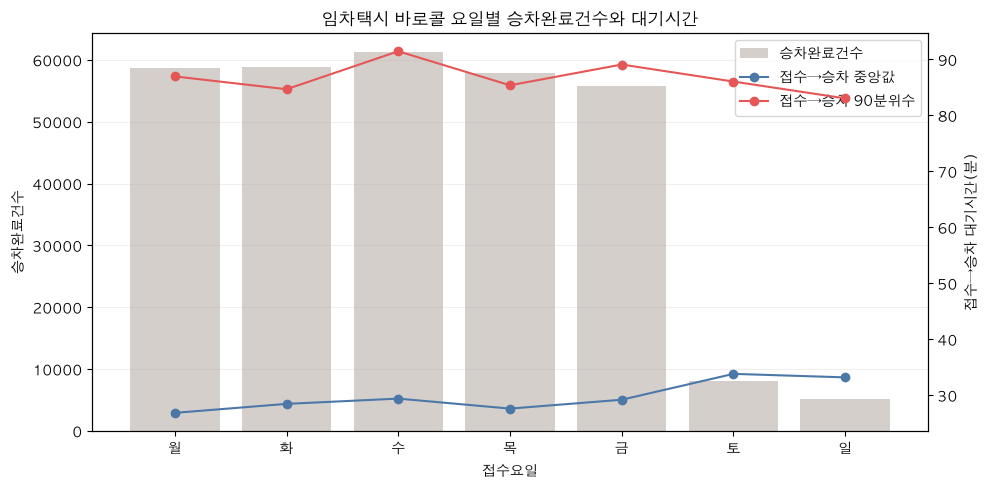

In [147]:
# 요일별 승차 대기시간 그래프
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    weekday_ride_wait_summary["접수요일"].astype(str),
    weekday_ride_wait_summary["승차완료건수"],
    color="#bab0ab",
    alpha=0.6,
    label="승차완료건수",
)

ax1.set_xlabel("접수요일")
ax1.set_ylabel("승차완료건수")
ax1.grid(axis="y", alpha=0.2)

ax2 = ax1.twinx()

ax2.plot(
    weekday_ride_wait_summary["접수요일"].astype(str),
    weekday_ride_wait_summary["접수_승차_중앙값"],
    marker="o",
    color="#4c78a8",
    label="접수→승차 중앙값",
)

ax2.plot(
    weekday_ride_wait_summary["접수요일"].astype(str),
    weekday_ride_wait_summary["접수_승차_90분위수"],
    marker="o",
    color="#e45756",
    label="접수→승차 90분위수",
)

ax2.set_ylabel("접수→승차 대기시간(분)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
)

ax1.set_title("임차택시 바로콜 요일별 승차완료건수와 대기시간")

plt.tight_layout()
plt.show()

- 승차완료건수는 평일에 집중, 주말은 급감, 승차 대기시간은 주말에 더 길어지는 경향
    - 수요가 적다고 대기시간이 짧아지는 건 아님  
- 90분위수는 평일이 더 높거나 비슷, 주말은 오히려 낮음
    - 평일: 이용건수가 많고 일부 장시간 대기 건도 존재
    - 주말: 전체 건수는 적고 중앙값은 높지만, 극단적인 장시간 대기는 상대적으로 적음

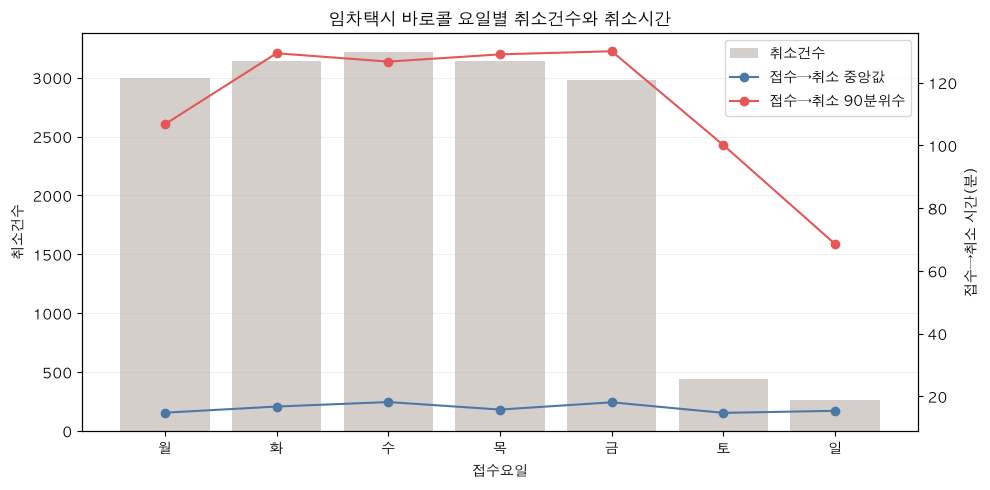

In [148]:
# 요일별 취소 대기시간 그래프
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    weekday_cancel_wait_summary["접수요일"].astype(str),
    weekday_cancel_wait_summary["취소건수"],
    color="#bab0ab",
    alpha=0.6,
    label="취소건수",
)

ax1.set_xlabel("접수요일")
ax1.set_ylabel("취소건수")
ax1.grid(axis="y", alpha=0.2)

ax2 = ax1.twinx()

ax2.plot(
    weekday_cancel_wait_summary["접수요일"].astype(str),
    weekday_cancel_wait_summary["접수_취소_중앙값"],
    marker="o",
    color="#4c78a8",
    label="접수→취소 중앙값",
)

ax2.plot(
    weekday_cancel_wait_summary["접수요일"].astype(str),
    weekday_cancel_wait_summary["접수_취소_90분위수"],
    marker="o",
    color="#e45756",
    label="접수→취소 90분위수",
)

ax2.set_ylabel("접수→취소 시간(분)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
)

ax1.set_title("임차택시 바로콜 요일별 취소건수와 취소시간")

plt.tight_layout()
plt.show()

- 취소건수도 평일 중심, 취소시간은 금요일이 약간 길고 일요일은 짧음
- 평일 취소는 접수 후 오래 기다리다 취소되는 사례가 일부 존재
- 주말 취소는 건수도 적고, 비교적 이른 시점에 취소되는 경향

## 7. 출발구별·이동유형별 임차택시 대기시간 분석

*어느 구에서 장시간 대기자가 많이 발생하나?*

`출발구` 기준으로 임차택시 대기시간을 집계한다. 단, 이동유형에 따라 대기시간의 의미가 달라질 수 있으므로 전체 현황을 먼저 확인한 뒤, `구 내 이동`, `구 간 이동`, `서울→서울 외`, `서울 외→서울`로 나누어 비교한다.

세부이동유형은 다음과 같이 정의한다.

| 세부이동유형 | 기준 | 해석 |
|---|---|---|
| 구 내 이동 | `출발구 == 목적구` | 같은 자치구 안에서 발생한 이동 |
| 구 간 이동 | `출발구 != 목적구`이고 출발·목적이 모두 서울 25개 자치구 | 서울 내부 다른 자치구로 이동 |
| 서울→서울 외 | 출발구는 서울 25개 자치구, 목적구는 서울 외 | 서울에서 외부 지역으로 나가는 이동 |
| 서울 외→서울 | 출발구는 서울 외, 목적구는 서울 25개 자치구 | 외부 지역에서 서울로 들어오는 이동 |

확인할 내용:

- 세부이동유형별 승차 완료 건수와 취소 건수
- 출발구별 `접수→배차` 중앙값
- 출발구별 `접수→승차` 중앙값
- 출발구별 `접수→취소` 중앙값
- 출발구별 `배차→취소` 중앙값
- 보조 확인: 출발구별 `배차→승차` 중앙값
- 출발구별 승차 완료 건수
- 출발구별 취소 건수
- 세부이동유형별 출발구 대기시간 차이

분석 근거:

대기시간은 이용자가 출발하는 지역의 차량 접근성 및 수요 집중과 관련될 수 있다. 다만 같은 출발구라도 `구 내 이동`, `구 간 이동`, `서울→서울 외`, `서울 외→서울`은 이동거리와 차량 회차 부담이 다를 수 있다.

따라서 출발구별 대기시간은 전체 순위만 보지 않고 세부이동유형별로 나누어 해석해야 지역별 임차택시 공급 부담을 더 정확히 볼 수 있다.

In [149]:
# 세부이동유형 생성
SEOUL_25 = [
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
]

def add_detail_movement_type(df):
    df = df.copy()

    origin_seoul = df["출발구"].isin(SEOUL_25)
    destination_seoul = df["목적구"].isin(SEOUL_25)

    df["세부이동유형"] = pd.NA

    df.loc[
        origin_seoul
        & destination_seoul
        & df["출발구"].eq(df["목적구"]),
        "세부이동유형"
    ] = "구 내 이동"

    df.loc[
        origin_seoul
        & destination_seoul
        & ~df["출발구"].eq(df["목적구"]),
        "세부이동유형"
    ] = "구 간 이동"

    df.loc[
        origin_seoul
        & ~destination_seoul,
        "세부이동유형"
    ] = "서울→서울 외"

    df.loc[
        ~origin_seoul
        & destination_seoul,
        "세부이동유형"
    ] = "서울 외→서울"

    return df


rental_ride_normal = add_detail_movement_type(rental_ride_normal)
rental_cancel_normal = add_detail_movement_type(rental_cancel_normal)

In [150]:
# 세부이동유형별 승차·취소 건수 확인
movement_type_ride_summary = (
    rental_ride_normal["세부이동유형"]
    .value_counts(dropna=False)
    .reset_index()
)

movement_type_ride_summary.columns = [
    "세부이동유형",
    "승차완료건수",
]

movement_type_cancel_summary = (
    rental_cancel_normal["세부이동유형"]
    .value_counts(dropna=False)
    .reset_index()
)

movement_type_cancel_summary.columns = [
    "세부이동유형",
    "취소건수",
]

movement_type_summary = pd.merge(
    movement_type_ride_summary,
    movement_type_cancel_summary,
    on="세부이동유형",
    how="outer",
).fillna(0)

movement_type_summary["승차완료건수"] = movement_type_summary["승차완료건수"].astype(int)
movement_type_summary["취소건수"] = movement_type_summary["취소건수"].astype(int)

display(movement_type_summary)

,세부이동유형,승차완료건수,취소건수
0,구 간 이동,164698,9015
1,구 내 이동,119011,6206
2,서울 외→서울,1551,6
3,서울→서울 외,20469,956


In [151]:
# 출발구별 승차 대기시간 집계
district_ride_wait_summary = (
    rental_ride_normal
    .groupby("출발구", dropna=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(
    district_ride_wait_summary
    .sort_values("접수_승차_90분위수", ascending=False)
)

,출발구,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수
14,김포시,356,117.561083,159.845108,130.782033,185.660725,17.104467,42.110842
23,부천시원미구,65,119.815383,159.771513,130.965050,182.931250,8.857567,38.639800
34,양주시,144,120.720833,160.156618,131.836250,178.050885,8.004392,29.063650
6,고양시일산서구,32,95.212942,152.273267,116.963117,175.724228,29.930308,43.731050
15,남양주시,335,97.464333,152.894000,123.047883,172.454287,21.141950,43.593247
5,고양시일산동구,59,86.293000,133.338843,108.685333,166.638943,25.265217,42.518850
26,성남시분당구,124,93.311975,116.806800,125.831667,152.112218,37.873867,49.028965
32,안양시동안구,8,76.805192,125.111265,91.277167,149.561317,24.832642,34.742933
37,용산구,4168,13.883892,127.452515,38.122533,148.099683,20.064950,31.472352
8,관악구,10941,17.423950,127.093950,38.416783,147.411500,18.509067,30.518050


In [152]:
# 출발구별 취소 대기시간 집계
district_cancel_wait_summary = (
    rental_cancel_normal
    .groupby("출발구", dropna=False)
    .agg(
        취소건수=("접수_취소_분", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        접수_취소_90분위수=("접수_취소_분", lambda x: x.quantile(0.90)),
        배차_취소_중앙값=("배차_취소_분", "median"),
        배차_취소_90분위수=("배차_취소_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(
    district_cancel_wait_summary
    .sort_values("접수_취소_90분위수", ascending=False)
)

,출발구,취소건수,접수_취소_중앙값,접수_취소_90분위수,배차_취소_중앙값,배차_취소_90분위수
15,서초구,552,24.505025,156.142883,2.873083,10.213222
4,관악구,715,21.100000,143.929050,2.973550,12.159940
0,강남구,901,20.183333,138.919167,2.810750,12.776238
22,용산구,293,20.133333,136.492850,2.797225,16.071078
5,광진구,518,35.069550,133.464580,2.648275,11.760718
11,동대문구,411,17.341167,132.493283,3.597000,13.586050
21,영등포구,829,17.933333,131.515940,2.442167,10.608003
8,금천구,446,23.772833,130.144892,2.668033,10.971608
19,송파구,757,15.050000,129.549800,2.521617,11.241667
6,구로구,475,17.689333,128.084817,2.429500,11.640857


In [153]:
# 세부이동유형·출발구별 승차 대기시간 집계
district_movement_ride_wait_summary = (
    rental_ride_normal
    .groupby(["세부이동유형", "출발구"], dropna=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(
    district_movement_ride_wait_summary
    .sort_values(["세부이동유형", "접수_승차_90분위수"], ascending=[True, False])
)

,세부이동유형,출발구,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수,배차_승차_중앙값,배차_승차_90분위수
4,구 간 이동,관악구,6207,15.268117,129.738833,36.361283,156.101163,18.607283,30.716633
20,구 간 이동,용산구,3327,15.493267,129.815047,39.324667,151.021800,20.163217,31.569253
7,구 간 이동,금천구,2917,21.984783,128.203603,44.153767,150.041207,19.709717,31.417750
12,구 간 이동,마포구,11488,12.918975,125.786902,33.538842,138.539852,16.812642,27.681635
1,구 간 이동,강동구,8839,9.551333,125.625117,26.469550,134.681110,14.756283,23.624153
...,...,...,...,...,...,...,...,...,...
78,서울→서울 외,노원구,1737,6.358267,44.256410,20.620567,62.122880,12.103617,21.760040
73,서울→서울 외,강서구,1221,7.017267,41.558883,24.780217,60.659050,15.557050,27.015783
71,서울→서울 외,강동구,3040,7.946892,42.068122,24.456025,58.409800,14.606333,23.364197
79,서울→서울 외,도봉구,499,8.133450,33.979527,25.111667,54.795253,15.061217,26.030957


In [154]:
# 세부이동유형·출발구별 취소 대기시간 집계
district_movement_cancel_wait_summary = (
    rental_cancel_normal
    .groupby(["세부이동유형", "출발구"], dropna=False)
    .agg(
        취소건수=("접수_취소_분", "count"),
        접수_취소_중앙값=("접수_취소_분", "median"),
        접수_취소_90분위수=("접수_취소_분", lambda x: x.quantile(0.90)),
        배차_취소_중앙값=("배차_취소_분", "median"),
        배차_취소_90분위수=("배차_취소_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(
    district_movement_cancel_wait_summary
    .sort_values(["세부이동유형", "접수_취소_90분위수"], ascending=[True, False])
)

,세부이동유형,출발구,취소건수,접수_취소_중앙값,접수_취소_90분위수,배차_취소_중앙값,배차_취소_90분위수
14,구 간 이동,서초구,305,20.490950,167.184667,2.695883,9.614620
0,구 간 이동,강남구,483,20.700783,146.517130,2.651250,12.786973
20,구 간 이동,용산구,216,19.036108,138.129558,2.817558,16.078800
7,구 간 이동,금천구,315,29.214617,135.569837,2.680117,10.450230
2,구 간 이동,강북구,332,13.434392,135.386195,2.411975,12.399477
...,...,...,...,...,...,...,...
59,서울→서울 외,구로구,25,13.802617,32.111847,3.369217,10.414123
75,서울→서울 외,종로구,29,12.026833,27.464207,3.711283,8.103993
63,서울→서울 외,동대문구,10,19.041667,26.915000,4.340000,13.705623
68,서울→서울 외,성동구,8,16.000000,24.806667,4.544858,15.104385


In [155]:
movement_ride_wait_summary = (
    rental_ride_normal
    .groupby("세부이동유형", dropna=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_승차_평균=("접수_승차_분", "mean"),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
        접수_배차_평균=("접수_배차_분", "mean"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

display(movement_ride_wait_summary)

,세부이동유형,승차완료건수,접수_승차_평균,접수_승차_중앙값,접수_승차_90분위수,접수_배차_평균,접수_배차_중앙값,접수_배차_90분위수
0,구 간 이동,164698,44.323512,29.856300,91.489567,26.510903,9.904500,70.260463
1,구 내 이동,119011,39.103095,26.329550,79.572000,22.587128,8.014500,59.975217
2,서울 외→서울,1551,116.663886,116.410117,169.563000,96.150363,93.848450,147.906833
3,서울→서울 외,20469,41.195861,29.161783,80.529953,23.576324,9.547783,59.627870


In [156]:
# 세부이동유형별 승차 비중 계산
movement_ride_share_summary = movement_ride_wait_summary.copy()

movement_ride_share_summary["승차비중(%)"] = (
    movement_ride_share_summary["승차완료건수"]
    / movement_ride_share_summary["승차완료건수"].sum()
    * 100
)

movement_ride_share_summary = (
    movement_ride_share_summary
    .sort_values("승차비중(%)", ascending=False)
)

display(movement_ride_share_summary)

,세부이동유형,승차완료건수,접수_승차_평균,접수_승차_중앙값,접수_승차_90분위수,접수_배차_평균,접수_배차_중앙값,접수_배차_90분위수,승차비중(%)
0,구 간 이동,164698,44.323512,29.856300,91.489567,26.510903,9.904500,70.260463,53.870585
1,구 내 이동,119011,39.103095,26.329550,79.572000,22.587128,8.014500,59.975217,38.926958
3,서울→서울 외,20469,41.195861,29.161783,80.529953,23.576324,9.547783,59.627870,6.695145
2,서울 외→서울,1551,116.663886,116.410117,169.563000,96.150363,93.848450,147.906833,0.507312


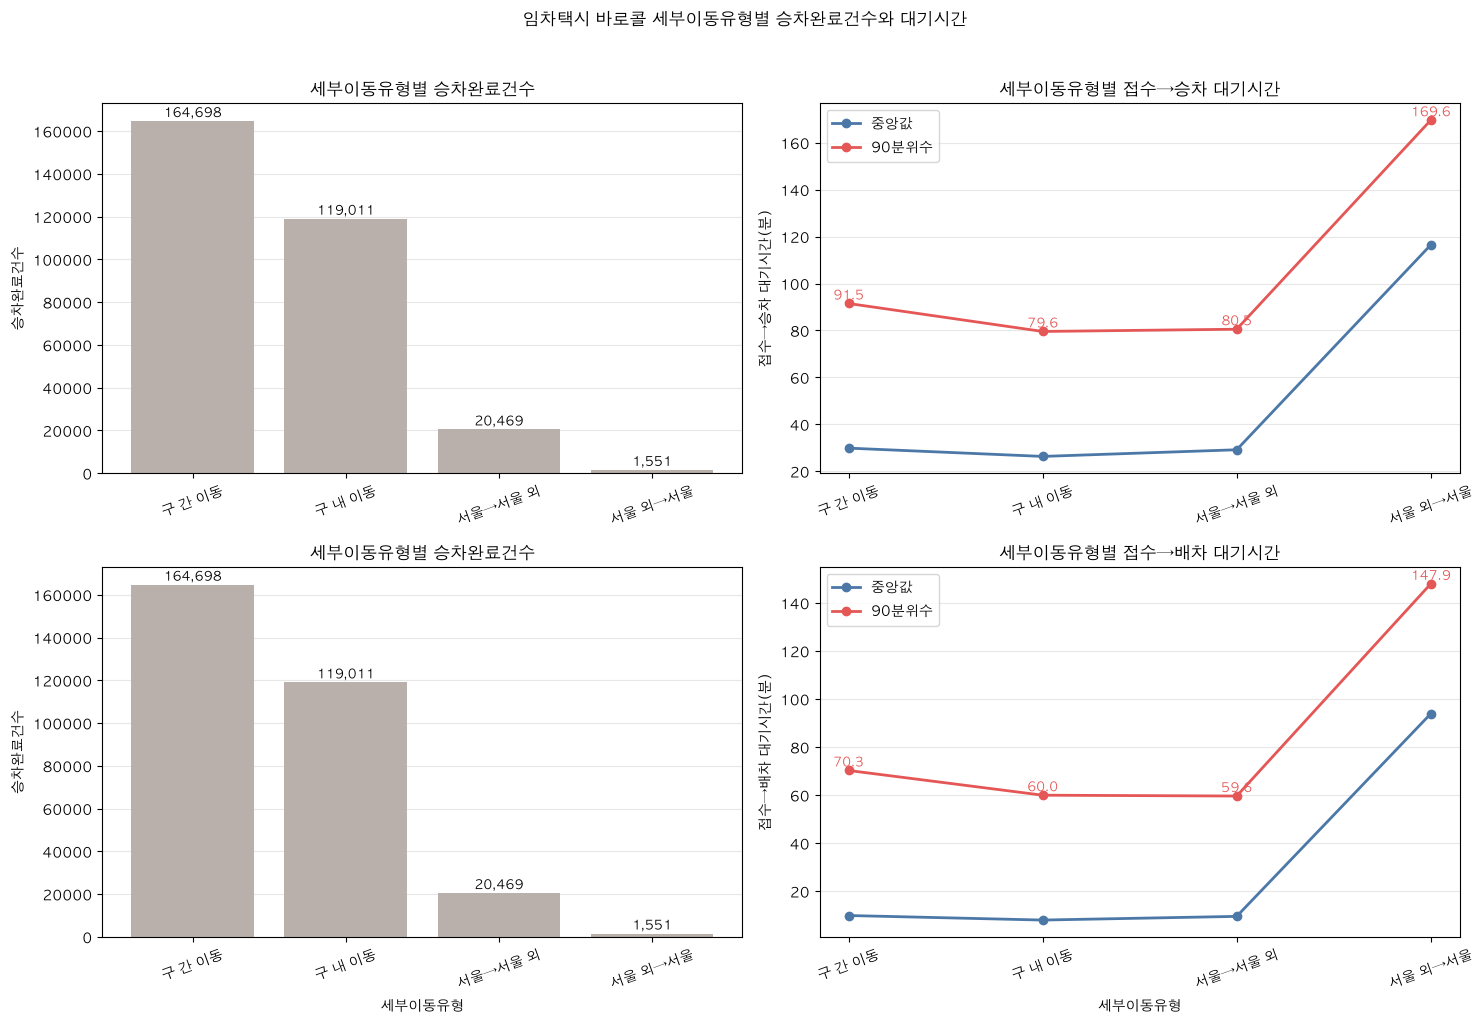

In [157]:
plot_data = (
    movement_ride_wait_summary
    .sort_values("승차완료건수", ascending=False)
    .reset_index(drop=True)
)

x = range(len(plot_data))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 세부이동유형별 승차완료건수 - 접수→승차 비교용
axes[0, 0].bar(
    x,
    plot_data["승차완료건수"],
    color="#bab0ab",
)

for i, row in plot_data.iterrows():
    axes[0, 0].text(
        i,
        row["승차완료건수"],
        f'{row["승차완료건수"]:,}',
        ha="center",
        va="bottom",
        fontsize=9,
    )

axes[0, 0].set_title("세부이동유형별 승차완료건수")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("승차완료건수")
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(plot_data["세부이동유형"], rotation=20)
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. 세부이동유형별 접수→승차 대기시간
axes[0, 1].plot(
    x,
    plot_data["접수_승차_중앙값"],
    marker="o",
    color="#4c78a8",
    linewidth=2,
    label="중앙값",
)

axes[0, 1].plot(
    x,
    plot_data["접수_승차_90분위수"],
    marker="o",
    color="#e45756",
    linewidth=2,
    label="90분위수",
)

for i, row in plot_data.iterrows():
    axes[0, 1].text(
        i,
        row["접수_승차_90분위수"],
        f'{row["접수_승차_90분위수"]:.1f}',
        ha="center",
        va="bottom",
        fontsize=9,
        color="#e45756",
    )

axes[0, 1].set_title("세부이동유형별 접수→승차 대기시간")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("접수→승차 대기시간(분)")
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(plot_data["세부이동유형"], rotation=20)
axes[0, 1].grid(axis="y", alpha=0.3)
axes[0, 1].legend()

# 3. 세부이동유형별 승차완료건수 - 접수→배차 비교용
axes[1, 0].bar(
    x,
    plot_data["승차완료건수"],
    color="#bab0ab",
)

for i, row in plot_data.iterrows():
    axes[1, 0].text(
        i,
        row["승차완료건수"],
        f'{row["승차완료건수"]:,}',
        ha="center",
        va="bottom",
        fontsize=9,
    )

axes[1, 0].set_title("세부이동유형별 승차완료건수")
axes[1, 0].set_xlabel("세부이동유형")
axes[1, 0].set_ylabel("승차완료건수")
axes[1, 0].set_xticks(list(x))
axes[1, 0].set_xticklabels(plot_data["세부이동유형"], rotation=20)
axes[1, 0].grid(axis="y", alpha=0.3)

# 4. 세부이동유형별 접수→배차 대기시간
axes[1, 1].plot(
    x,
    plot_data["접수_배차_중앙값"],
    marker="o",
    color="#4c78a8",
    linewidth=2,
    label="중앙값",
)

axes[1, 1].plot(
    x,
    plot_data["접수_배차_90분위수"],
    marker="o",
    color="#e45756",
    linewidth=2,
    label="90분위수",
)

for i, row in plot_data.iterrows():
    axes[1, 1].text(
        i,
        row["접수_배차_90분위수"],
        f'{row["접수_배차_90분위수"]:.1f}',
        ha="center",
        va="bottom",
        fontsize=9,
        color="#e45756",
    )

axes[1, 1].set_title("세부이동유형별 접수→배차 대기시간")
axes[1, 1].set_xlabel("세부이동유형")
axes[1, 1].set_ylabel("접수→배차 대기시간(분)")
axes[1, 1].set_xticks(list(x))
axes[1, 1].set_xticklabels(plot_data["세부이동유형"], rotation=20)
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].legend()

plt.suptitle(
    "임차택시 바로콜 세부이동유형별 승차완료건수와 대기시간",
    y=1.02,
)

plt.tight_layout()
plt.show()

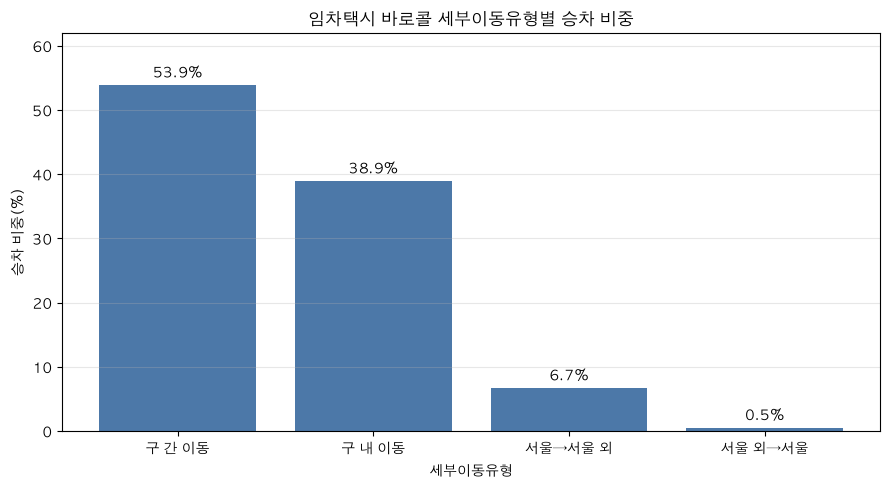

In [158]:
plot_data = (
    movement_ride_share_summary
    .sort_values("승차비중(%)", ascending=False)
    .reset_index(drop=True)
)

x = range(len(plot_data))

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    x,
    plot_data["승차비중(%)"],
    color="#4c78a8",
)

for i, row in plot_data.iterrows():
    ax.text(
        i,
        row["승차비중(%)"] + 0.5,
        f'{row["승차비중(%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("임차택시 바로콜 세부이동유형별 승차 비중")
ax.set_xlabel("세부이동유형")
ax.set_ylabel("승차 비중(%)")
ax.set_xticks(list(x))
ax.set_xticklabels(plot_data["세부이동유형"], rotation=0)
ax.set_ylim(0, plot_data["승차비중(%)"].max() * 1.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [159]:
# 세부이동유형별 취소율 계산
movement_type_cancel_rate_summary = movement_type_summary.copy()

movement_type_cancel_rate_summary["전체건수"] = (
    movement_type_cancel_rate_summary["승차완료건수"]
    + movement_type_cancel_rate_summary["취소건수"]
)

movement_type_cancel_rate_summary["취소율(%)"] = (
    movement_type_cancel_rate_summary["취소건수"]
    / movement_type_cancel_rate_summary["전체건수"]
    * 100
)

movement_type_cancel_rate_summary = (
    movement_type_cancel_rate_summary
    .sort_values("취소율(%)", ascending=False)
)

display(movement_type_cancel_rate_summary)

,세부이동유형,승차완료건수,취소건수,전체건수,취소율(%)
0,구 간 이동,164698,9015,173713,5.189594
1,구 내 이동,119011,6206,125217,4.956196
3,서울→서울 외,20469,956,21425,4.462077
2,서울 외→서울,1551,6,1557,0.385356


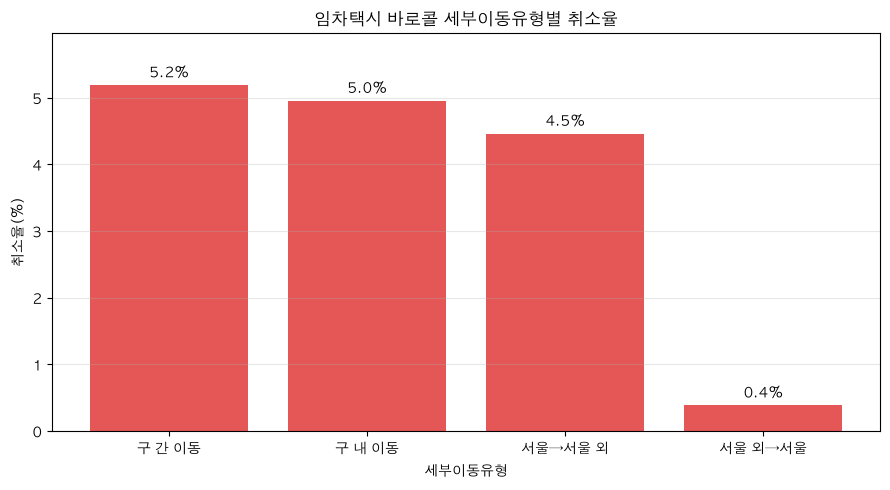

In [160]:
plot_data = (
    movement_type_cancel_rate_summary
    .sort_values("취소율(%)", ascending=False)
    .reset_index(drop=True)
)

x = range(len(plot_data))

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    x,
    plot_data["취소율(%)"],
    color="#e45756",
)

for i, row in plot_data.iterrows():
    ax.text(
        i,
        row["취소율(%)"] + 0.05,
        f'{row["취소율(%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("임차택시 바로콜 세부이동유형별 취소율")
ax.set_xlabel("세부이동유형")
ax.set_ylabel("취소율(%)")
ax.set_xticks(list(x))
ax.set_xticklabels(plot_data["세부이동유형"], rotation=0)
ax.set_ylim(0, plot_data["취소율(%)"].max() * 1.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

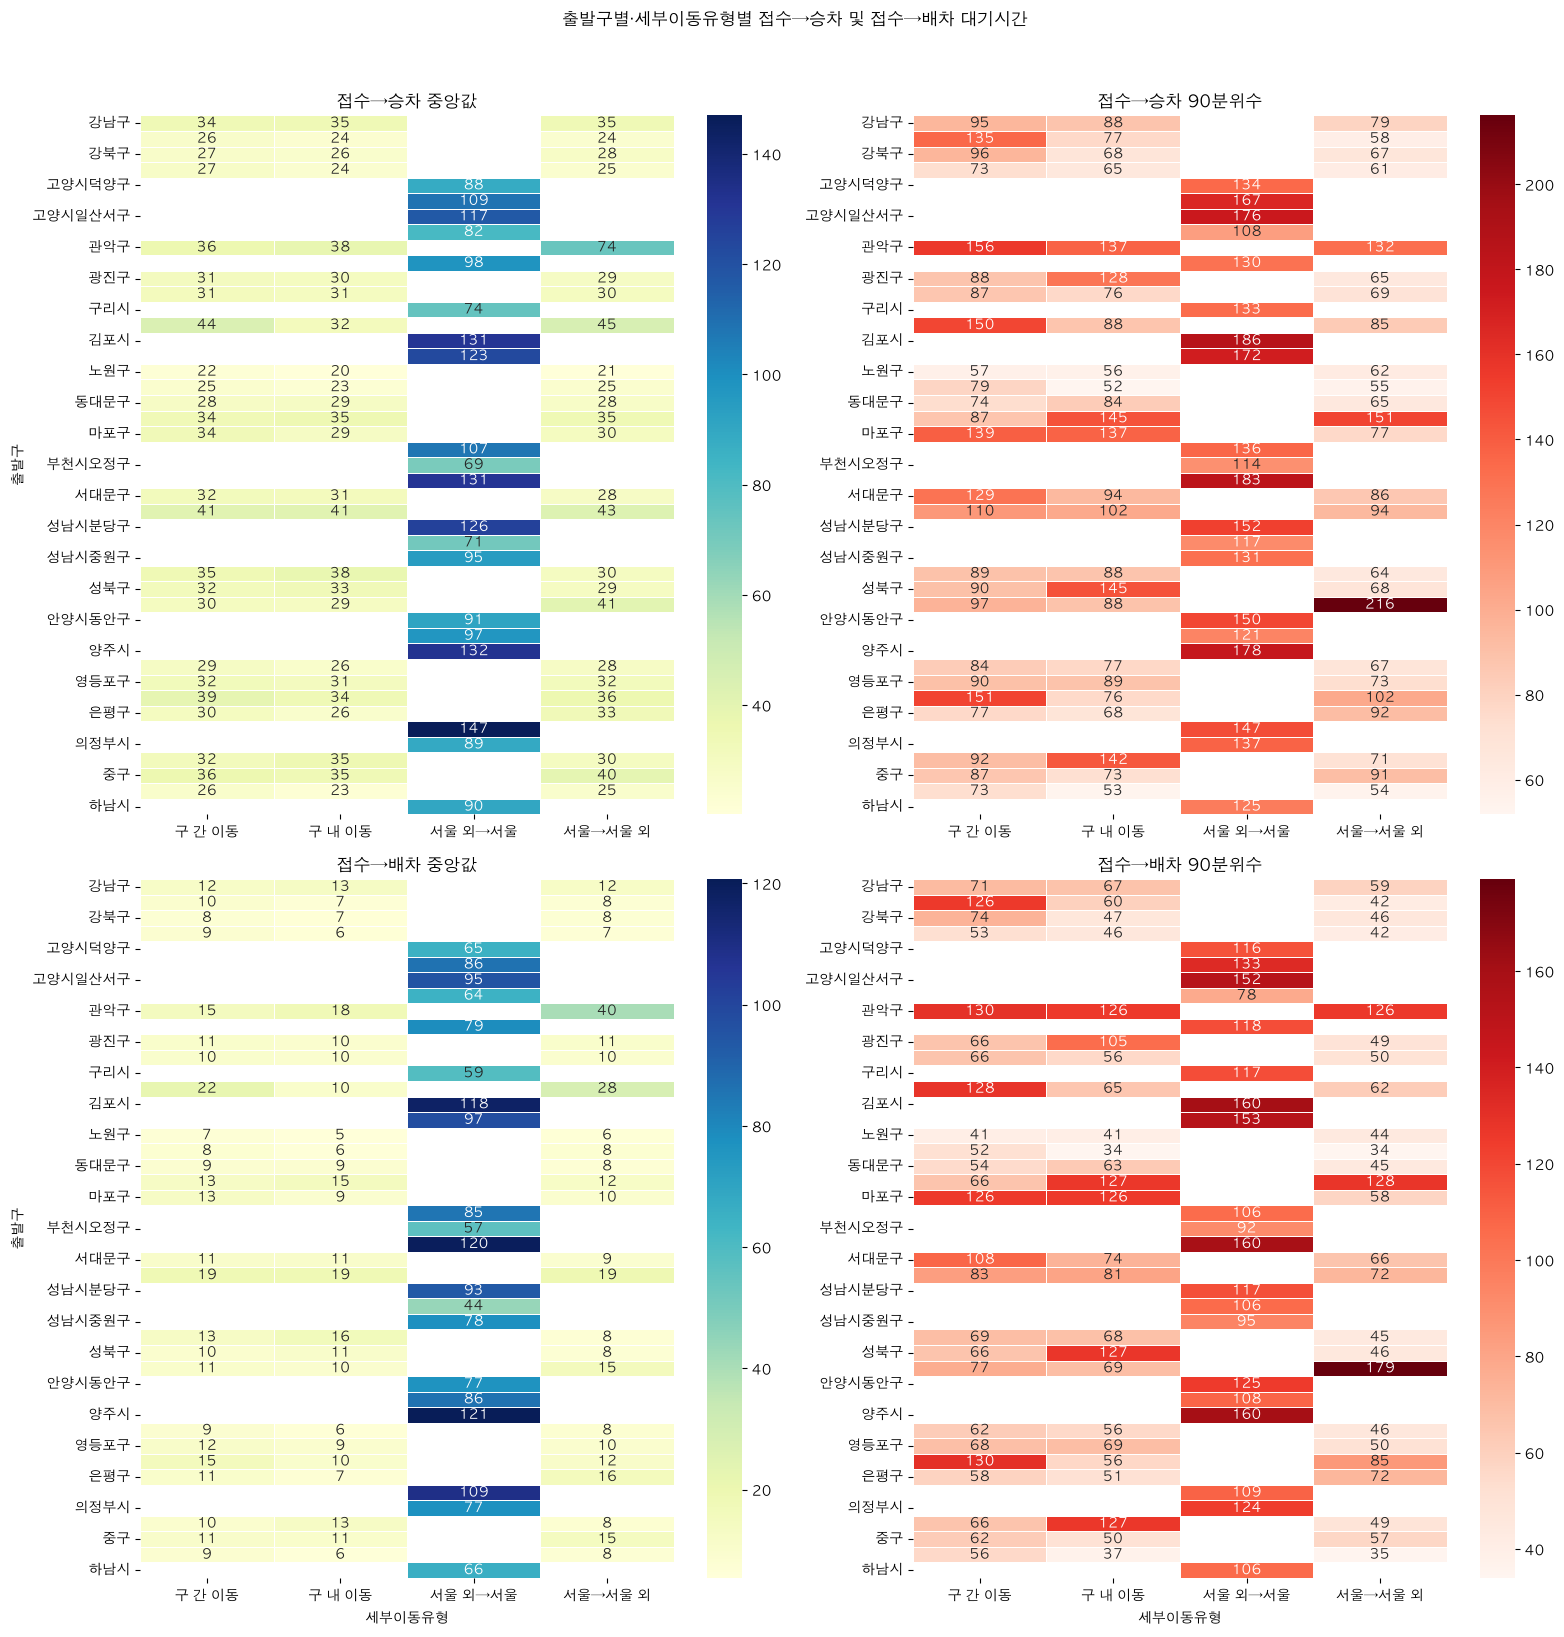

In [161]:
# 출발구별·세부이동유형별 접수→승차 / 접수→배차 중앙값·90분위수 히트맵

boarding_median_pivot = district_movement_ride_wait_summary.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_승차_중앙값",
    aggfunc="median",
)

boarding_p90_pivot = district_movement_ride_wait_summary.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_승차_90분위수",
    aggfunc="median",
)

dispatch_median_pivot = district_movement_ride_wait_summary.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_중앙값",
    aggfunc="median",
)

dispatch_p90_pivot = district_movement_ride_wait_summary.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_90분위수",
    aggfunc="median",
)

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

sns.heatmap(
    boarding_median_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[0, 0],
)

axes[0, 0].set_title("접수→승차 중앙값")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("출발구")

sns.heatmap(
    boarding_p90_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[0, 1],
)

axes[0, 1].set_title("접수→승차 90분위수")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("")

sns.heatmap(
    dispatch_median_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[1, 0],
)

axes[1, 0].set_title("접수→배차 중앙값")
axes[1, 0].set_xlabel("세부이동유형")
axes[1, 0].set_ylabel("출발구")

sns.heatmap(
    dispatch_p90_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[1, 1],
)

axes[1, 1].set_title("접수→배차 90분위수")
axes[1, 1].set_xlabel("세부이동유형")
axes[1, 1].set_ylabel("")

plt.suptitle(
    "출발구별·세부이동유형별 접수→승차 및 접수→배차 대기시간",
    y=1.02,
)

plt.tight_layout()
plt.show()

- 중앙값 높음 = 전반적인 대기 수준 높음 : 서울 외 -> 서울
- 중앙값은 보통인데 90분위수 높음 = 대부분은 괜찮지만 상위 10%가 오래 기다림 : 구 간 이동 몇, 구 내 이동 몇, 서울 -> 서울 외
- 중앙값 높음 + 90분위수 높음 = 전반적으로도 오래 기다리고 장시간 대기 위험도 큼 : 서울 외 -> 서울 (단, 건수 1500 건 취소 6건으로 표본 수가 적음)

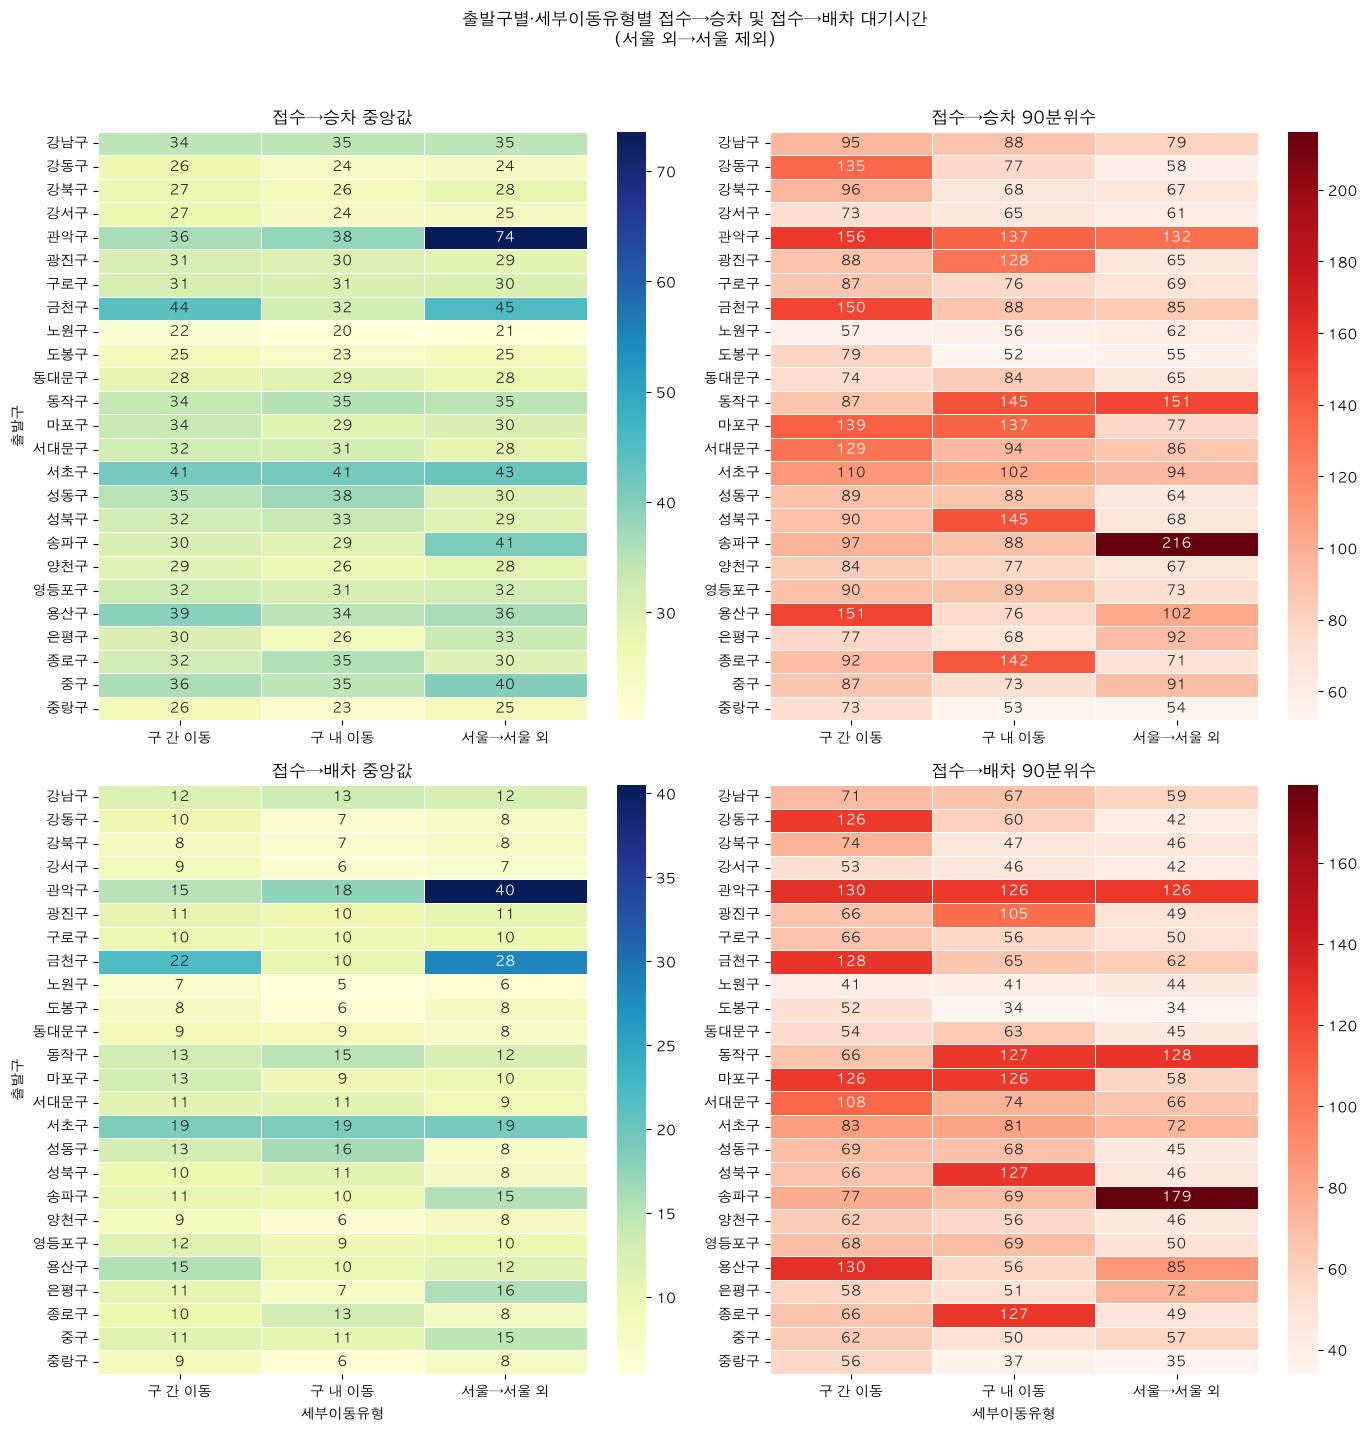

In [162]:
# 서울 외→서울 제외 후 출발구별·세부이동유형별 히트맵

heatmap_data = district_movement_ride_wait_summary[
    district_movement_ride_wait_summary["세부이동유형"] != "서울 외→서울"
].copy()

boarding_median_pivot = heatmap_data.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_승차_중앙값",
    aggfunc="median",
)

boarding_p90_pivot = heatmap_data.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_승차_90분위수",
    aggfunc="median",
)

dispatch_median_pivot = heatmap_data.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_중앙값",
    aggfunc="median",
)

dispatch_p90_pivot = heatmap_data.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_90분위수",
    aggfunc="median",
)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

sns.heatmap(
    boarding_median_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[0, 0],
)

axes[0, 0].set_title("접수→승차 중앙값")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("출발구")

sns.heatmap(
    boarding_p90_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[0, 1],
)

axes[0, 1].set_title("접수→승차 90분위수")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("")

sns.heatmap(
    dispatch_median_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[1, 0],
)

axes[1, 0].set_title("접수→배차 중앙값")
axes[1, 0].set_xlabel("세부이동유형")
axes[1, 0].set_ylabel("출발구")

sns.heatmap(
    dispatch_p90_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[1, 1],
)

axes[1, 1].set_title("접수→배차 90분위수")
axes[1, 1].set_xlabel("세부이동유형")
axes[1, 1].set_ylabel("")

plt.suptitle(
    "출발구별·세부이동유형별 접수→승차 및 접수→배차 대기시간\n(서울 외→서울 제외)",
    y=1.02,
)

plt.tight_layout()
plt.show()

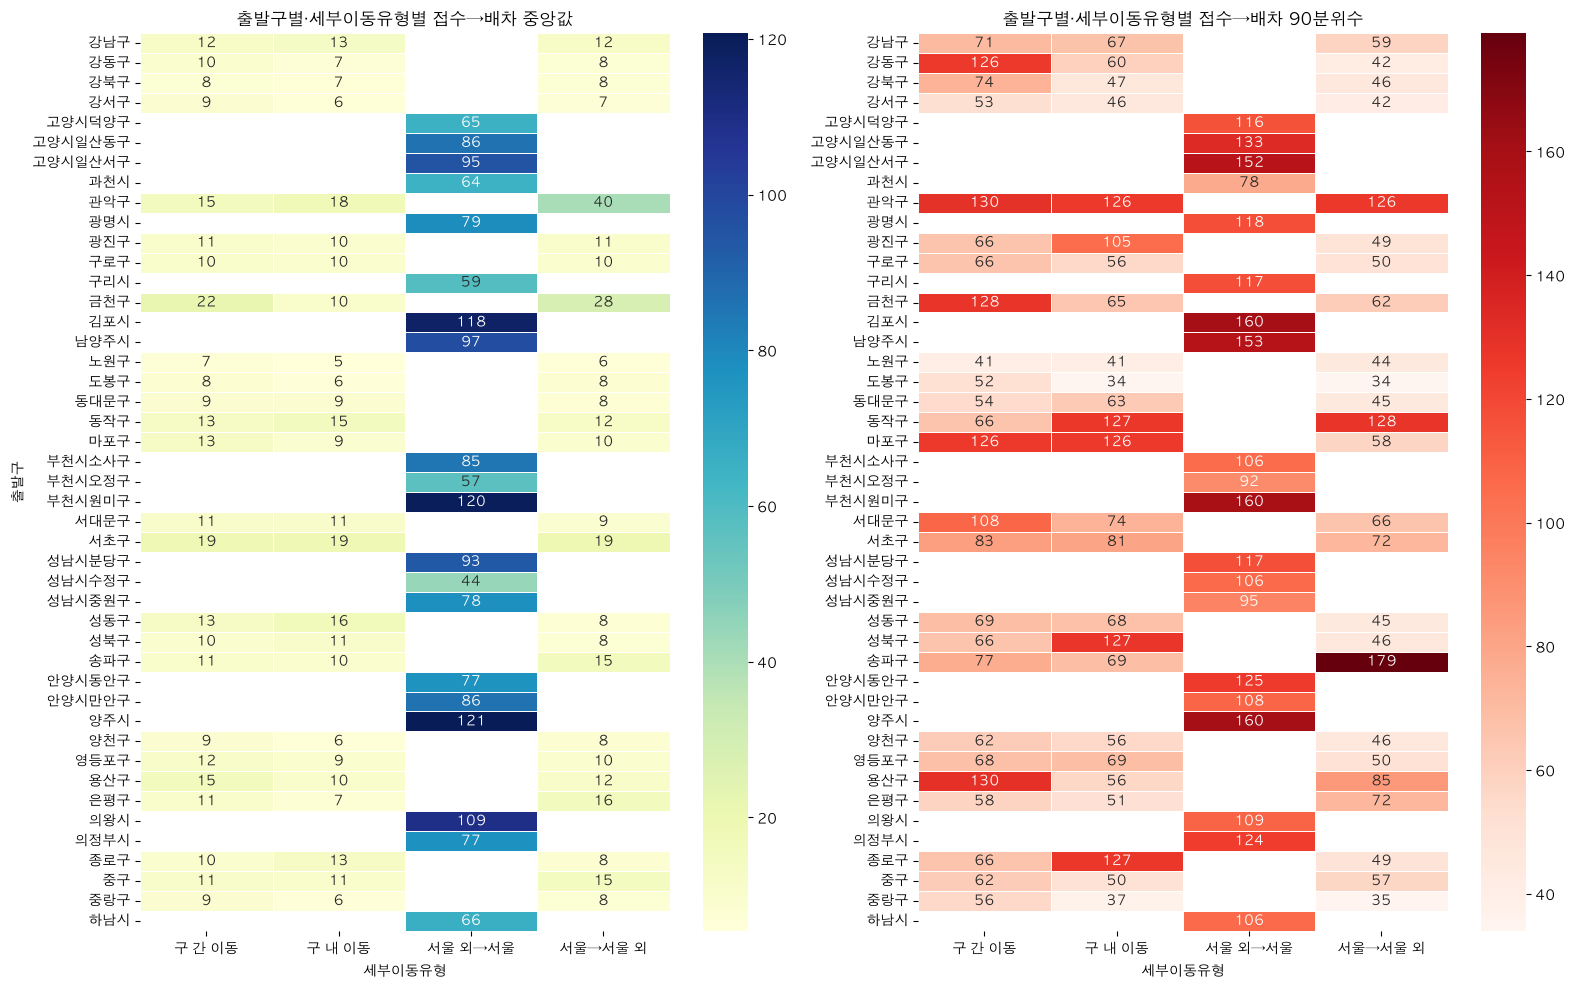

In [163]:
# 출발구별·세부이동유형별 접수→배차 중앙값/90분위수 히트맵

dispatch_median_pivot = district_movement_ride_wait_summary.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_중앙값",
    aggfunc="median",
)

dispatch_p90_pivot = district_movement_ride_wait_summary.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_90분위수",
    aggfunc="median",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

sns.heatmap(
    dispatch_median_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[0],
)

axes[0].set_title("출발구별·세부이동유형별 접수→배차 중앙값")
axes[0].set_xlabel("세부이동유형")
axes[0].set_ylabel("출발구")

sns.heatmap(
    dispatch_p90_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[1],
)

axes[1].set_title("출발구별·세부이동유형별 접수→배차 90분위수")
axes[1].set_xlabel("세부이동유형")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

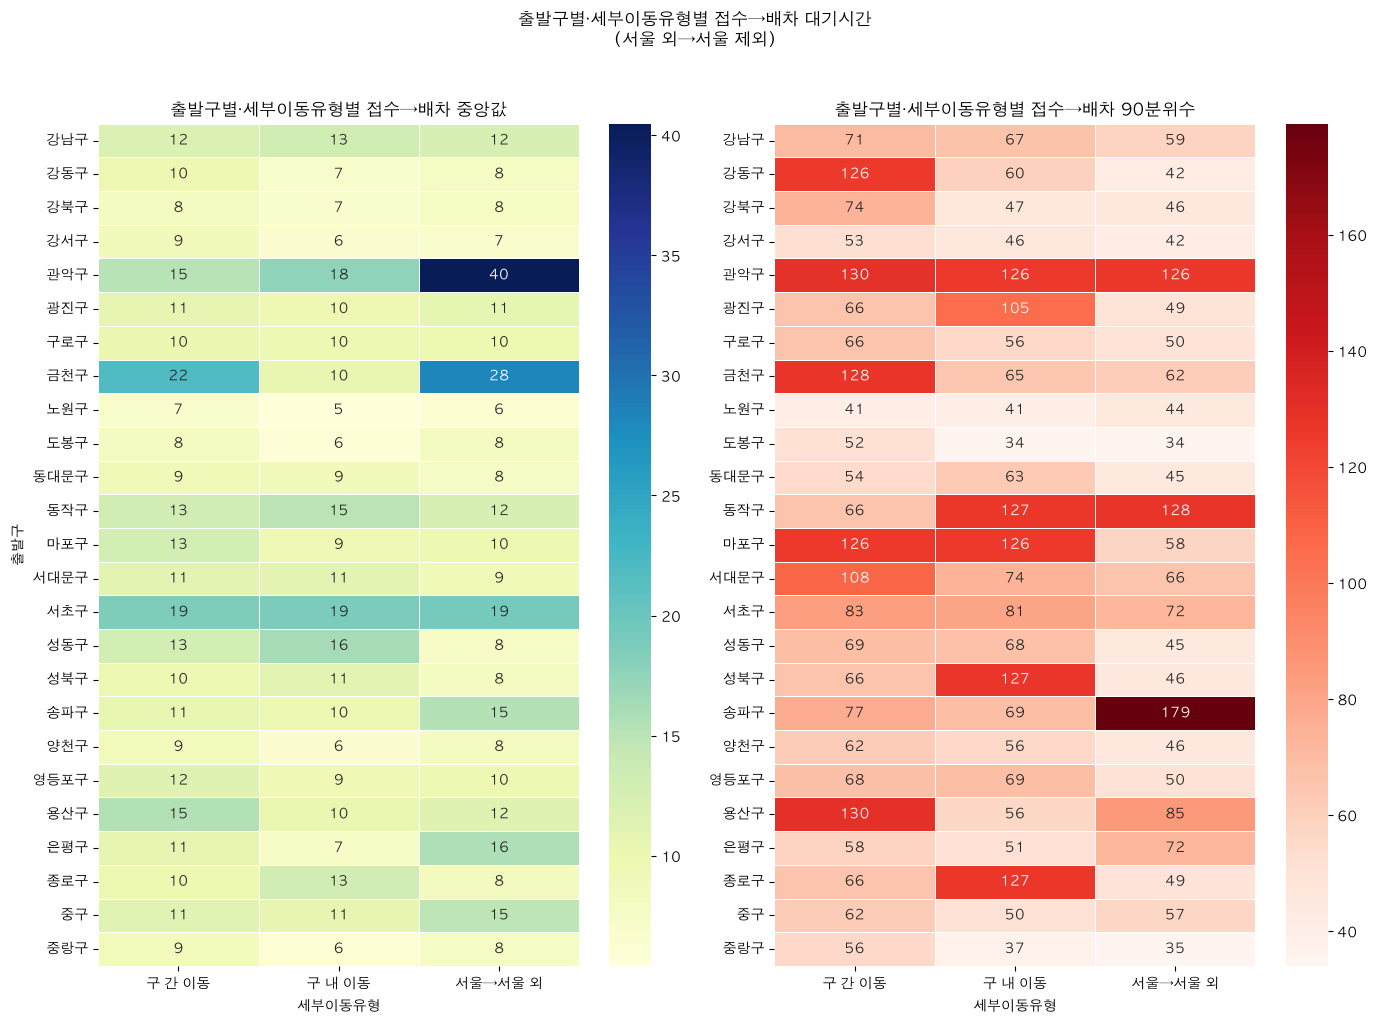

In [164]:
# 서울 외→서울 제외 후 출발구별·세부이동유형별 접수→배차 중앙값/90분위수 히트맵

heatmap_data = district_movement_ride_wait_summary[
    district_movement_ride_wait_summary["세부이동유형"] != "서울 외→서울"
].copy()

dispatch_median_pivot = heatmap_data.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_중앙값",
    aggfunc="median",
)

dispatch_p90_pivot = heatmap_data.pivot_table(
    index="출발구",
    columns="세부이동유형",
    values="접수_배차_90분위수",
    aggfunc="median",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

sns.heatmap(
    dispatch_median_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[0],
)

axes[0].set_title("출발구별·세부이동유형별 접수→배차 중앙값")
axes[0].set_xlabel("세부이동유형")
axes[0].set_ylabel("출발구")

sns.heatmap(
    dispatch_p90_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=axes[1],
)

axes[1].set_title("출발구별·세부이동유형별 접수→배차 90분위수")
axes[1].set_xlabel("세부이동유형")
axes[1].set_ylabel("")

plt.suptitle(
    "출발구별·세부이동유형별 접수→배차 대기시간\n(서울 외→서울 제외)",
    y=1.02,
)

plt.tight_layout()
plt.show()

## 8. 승차거리에 따른 임차택시 대기시간 분석

`승차거리`에 따라 임차택시 바로콜 대기시간이 달라지는지 확인한다.

승차거리가 긴 이동은 기사 입장에서 운행 부담이나 회차 부담이 커질 수 있으므로, 배차가 늦어질 가능성이 있다. 따라서 승차거리별로 `접수→배차`와 `접수→승차` 대기시간을 비교한다.

확인할 내용:

- 승차거리 구간별 승차완료건수
- 승차거리 구간별 `접수→배차` 중앙값
- 승차거리 구간별 `접수→배차` 90분위수
- 승차거리 구간별 `접수→승차` 중앙값
- 승차거리 구간별 `접수→승차` 90분위수
- 승차거리 구간별 `배차→승차` 중앙값
- 승차거리 구간별 `배차→승차` 90분위수
- 세부이동유형별 승차거리와 대기시간 관계

분석 근거:

승차거리가 긴 이동은 기사 입장에서 운행 및 회차 부담이 커질 수 있다. 이 경우 전체 승차 대기시간인 `접수→승차`보다, 차량이 배정되기까지 걸리는 `접수→배차` 시간이 길어질 가능성이 있다.

따라서 승차거리에 따른 대기시간 분석에서는 `접수→배차`를 핵심 지표로 보고, `접수→승차`와 `배차→승차`를 함께 확인한다.

만약 승차거리가 길어질수록 `접수→배차` 중앙값 또는 90분위수가 증가한다면, 장거리 이동에서 배차 지연이 발생할 가능성을 시사한다. 반대로 `접수→배차`는 크게 변하지 않고 `배차→승차`만 증가한다면, 배차 자체보다 차량 이동 또는 실제 승차까지의 시간이 길어진 것으로 해석할 수 있다.

단, 승차거리는 이동유형과 지역의 영향을 함께 받을 수 있으므로 전체 분석 이후 `구 내 이동`, `구 간 이동`, `서울→서울 외`, `서울 외→서울`로 나누어 확인한다.

In [165]:
# 승차거리 km 변환 및 기본 분포 확인
rental_ride_normal["승차거리_km"] = (
    rental_ride_normal["승차거리"] / 1000
)

distance_distribution_summary = rental_ride_normal["승차거리_km"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

display(distance_distribution_summary)

count    305729.000000
mean          7.878269
std           8.050733
min           0.000000
25%           2.960000
50%           5.081000
75%           9.646000
90%          17.657200
95%          24.508600
99%          38.329720
max         116.710000
Name: 승차거리_km, dtype: float64

In [166]:
# 승차거리 결측/0/음수 확인
distance_quality_summary = pd.DataFrame({
    "항목": [
        "전체 건수",
        "승차거리 결측",
        "승차거리 0",
        "승차거리 음수",
        "승차거리 양수",
    ],
    "건수": [
        len(rental_ride_normal),
        rental_ride_normal["승차거리"].isna().sum(),
        rental_ride_normal["승차거리"].eq(0).sum(),
        rental_ride_normal["승차거리"].lt(0).sum(),
        rental_ride_normal["승차거리"].gt(0).sum(),
    ],
})

display(distance_quality_summary)

,항목,건수
0,전체 건수,305729
1,승차거리 결측,0
2,승차거리 0,9
3,승차거리 음수,0
4,승차거리 양수,305720


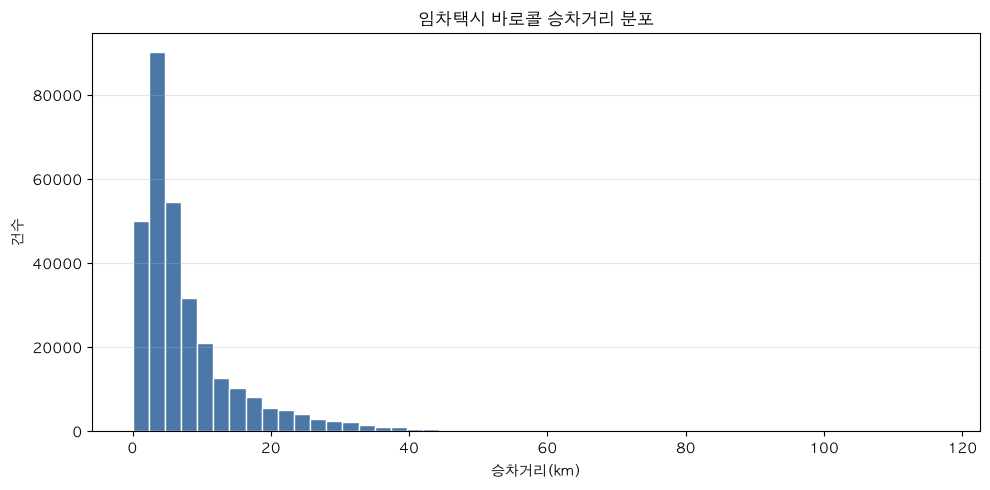

In [167]:
# 승차거리 히스토그램
plot_distance = rental_ride_normal["승차거리_km"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    plot_distance,
    bins=50,
    color="#4c78a8",
    edgecolor="white",
)

ax.set_title("임차택시 바로콜 승차거리 분포")
ax.set_xlabel("승차거리(km)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

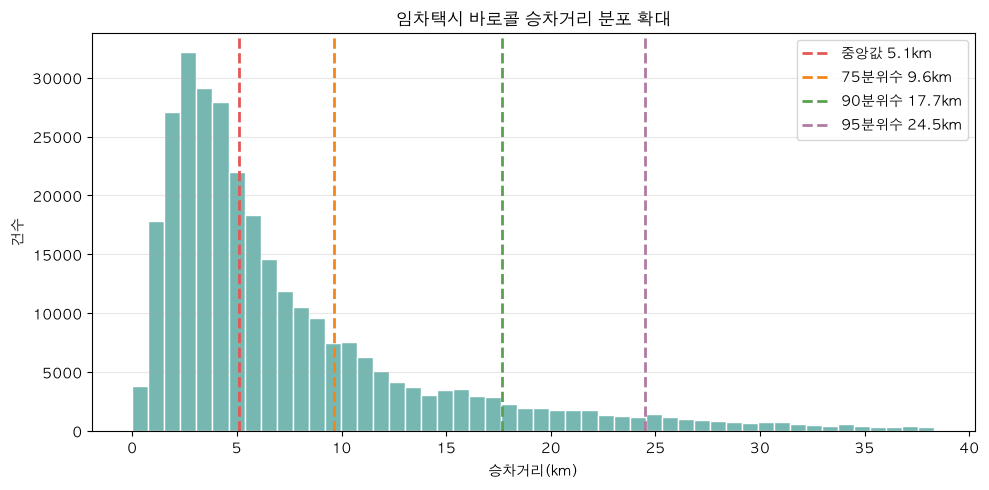

In [168]:
# 긴 꼬리 제외해서 분포 확대
p99_distance = rental_ride_normal["승차거리_km"].quantile(0.99)

plot_distance_zoom = rental_ride_normal[
    rental_ride_normal["승차거리_km"].between(0, p99_distance, inclusive="both")
]["승차거리_km"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    plot_distance_zoom,
    bins=50,
    color="#76b7b2",
    edgecolor="white",
)

ax.axvline(
    rental_ride_normal["승차거리_km"].median(),
    color="#e45756",
    linestyle="--",
    linewidth=2,
    label=f"중앙값 {rental_ride_normal['승차거리_km'].median():.1f}km",
)

ax.axvline(
    rental_ride_normal["승차거리_km"].quantile(0.75),
    color="#f58518",
    linestyle="--",
    linewidth=2,
    label=f"75분위수 {rental_ride_normal['승차거리_km'].quantile(0.75):.1f}km",
)

ax.axvline(
    rental_ride_normal["승차거리_km"].quantile(0.90),
    color="#59a14f",
    linestyle="--",
    linewidth=2,
    label=f"90분위수 {rental_ride_normal['승차거리_km'].quantile(0.90):.1f}km",
)

ax.axvline(
    rental_ride_normal["승차거리_km"].quantile(0.95),
    color="#b07aa1",
    linestyle="--",
    linewidth=2,
    label=f"95분위수 {rental_ride_normal['승차거리_km'].quantile(0.95):.1f}km",
)

ax.set_title("임차택시 바로콜 승차거리 분포 확대")
ax.set_xlabel("승차거리(km)")
ax.set_ylabel("건수")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [169]:
# 분포 기준 구간 후보 확인
distance_bins = [0, 5, 10, 15, 25, float("inf")]
distance_labels = [
    "0~5km",
    "5~10km",
    "10~15km",
    "15~25km",
    "25km 초과",
]

rental_ride_normal["승차거리구간"] = pd.cut(
    rental_ride_normal["승차거리_km"],
    bins=distance_bins,
    labels=distance_labels,
    right=False,
)

distance_bin_summary = (
    rental_ride_normal["승차거리구간"]
    .value_counts(sort=False)
    .reset_index()
)

distance_bin_summary.columns = [
    "승차거리구간",
    "건수",
]

distance_bin_summary["비율(%)"] = (
    distance_bin_summary["건수"]
    / distance_bin_summary["건수"].sum()
    * 100
)

display(distance_bin_summary)

,승차거리구간,건수,비율(%)
0,0~5km,150731,49.302160
1,5~10km,81925,26.796607
2,10~15km,31119,10.178622
3,15~25km,27486,8.990315
4,25km 초과,14468,4.732296


In [170]:
# 승차거리 구간별 접수→배차 대기시간 요약
distance_dispatch_wait_summary = (
    rental_ride_normal
    .groupby("승차거리구간", observed=False)
    .agg(
        승차완료건수=("접수_배차_분", "count"),
        접수_배차_평균=("접수_배차_분", "mean"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_75분위수=("접수_배차_분", lambda x: x.quantile(0.75)),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_배차_95분위수=("접수_배차_분", lambda x: x.quantile(0.95)),
        접수_배차_최대값=("접수_배차_분", "max"),
    )
    .reset_index()
)

display(distance_dispatch_wait_summary)

,승차거리구간,승차완료건수,접수_배차_평균,접수_배차_중앙값,접수_배차_75분위수,접수_배차_90분위수,접수_배차_95분위수,접수_배차_최대값
0,0~5km,150731,23.243595,8.338600,27.781950,61.828550,126.762325,227.805833
1,5~10km,81925,24.260095,9.525950,32.162217,62.500933,125.777907,219.334833
2,10~15km,31119,26.530894,10.115500,33.672892,69.304217,128.336540,211.989283
3,15~25km,27486,30.066860,11.506692,37.982054,94.978642,131.840850,219.888217
4,25km 초과,14468,37.534643,13.728117,51.607117,126.237798,141.590157,231.220450


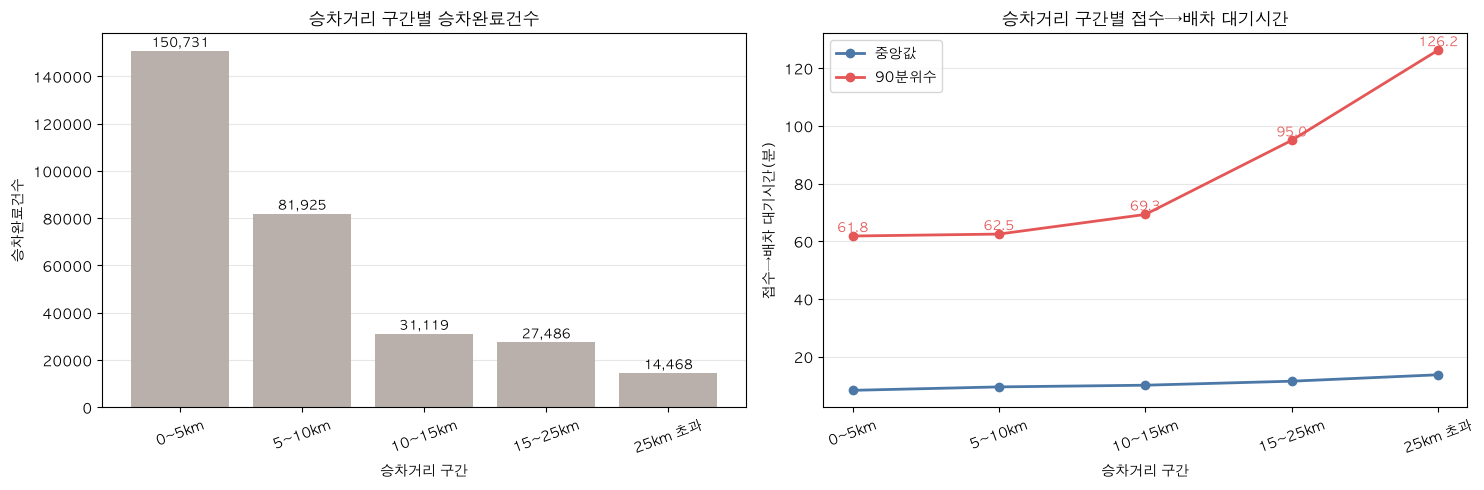

In [171]:
# 승차거리 구간별 접수→배차 대기시간 그래프
plot_data = distance_dispatch_wait_summary.copy()
x = range(len(plot_data))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(
    x,
    plot_data["승차완료건수"],
    color="#bab0ab",
)

for i, row in plot_data.iterrows():
    axes[0].text(
        i,
        row["승차완료건수"],
        f'{row["승차완료건수"]:,}',
        ha="center",
        va="bottom",
        fontsize=9,
    )

axes[0].set_title("승차거리 구간별 승차완료건수")
axes[0].set_xlabel("승차거리 구간")
axes[0].set_ylabel("승차완료건수")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(plot_data["승차거리구간"].astype(str), rotation=20)
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(
    x,
    plot_data["접수_배차_중앙값"],
    marker="o",
    color="#4c78a8",
    linewidth=2,
    label="중앙값",
)

axes[1].plot(
    x,
    plot_data["접수_배차_90분위수"],
    marker="o",
    color="#e45756",
    linewidth=2,
    label="90분위수",
)

for i, row in plot_data.iterrows():
    axes[1].text(
        i,
        row["접수_배차_90분위수"],
        f'{row["접수_배차_90분위수"]:.1f}',
        ha="center",
        va="bottom",
        fontsize=9,
        color="#e45756",
    )

axes[1].set_title("승차거리 구간별 접수→배차 대기시간")
axes[1].set_xlabel("승차거리 구간")
axes[1].set_ylabel("접수→배차 대기시간(분)")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(plot_data["승차거리구간"].astype(str), rotation=20)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

거리가 멀어질수록 배차 시간이 길어지는 건 맞으나 택시기사의 콜 거부일 수도 있고 아니면 택시기사 위치부터 출발지까지 거리 때문일 수도 있고 이건 어케 확인하지 하

In [172]:
# 승차거리와 접수→배차 대기시간 상관 확인
distance_dispatch_corr = rental_ride_normal[
    ["승차거리_km", "접수_배차_분"]
].corr(method="spearman")

display(distance_dispatch_corr)

,승차거리_km,접수_배차_분
승차거리_km,1.0000,0.0898
접수_배차_분,0.0898,1.0000


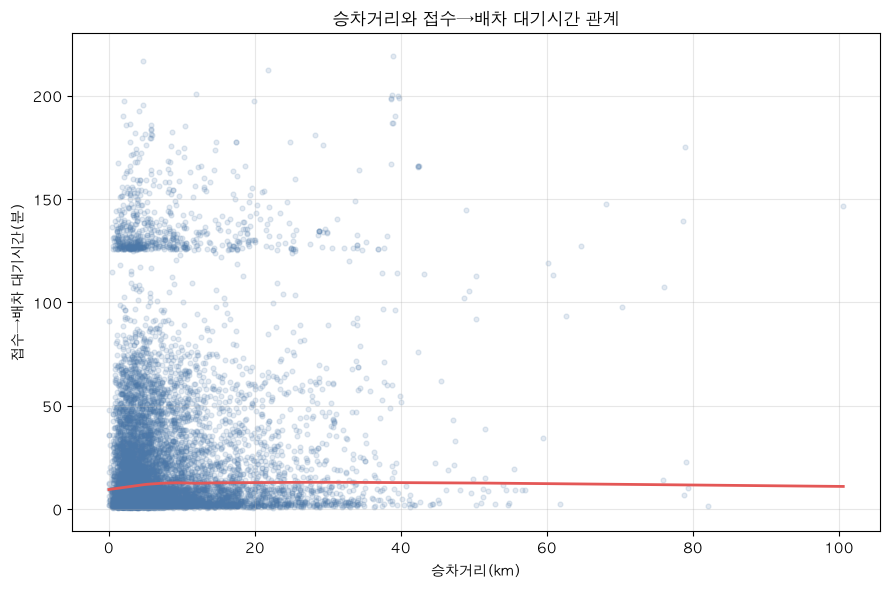

In [173]:
scatter_data = rental_ride_normal[
    ["승차거리_km", "접수_배차_분"]
].dropna().copy()

scatter_sample = scatter_data.sample(
    n=min(10000, len(scatter_data)),
    random_state=42,
)

fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=scatter_sample,
    x="승차거리_km",
    y="접수_배차_분",
    scatter_kws={
        "alpha": 0.15,
        "s": 12,
        "color": "#4c78a8",
    },
    line_kws={
        "color": "#e45756",
        "linewidth": 2,
    },
    lowess=True,
    ax=ax,
)

ax.set_title("승차거리와 접수→배차 대기시간 관계")
ax.set_xlabel("승차거리(km)")
ax.set_ylabel("접수→배차 대기시간(분)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

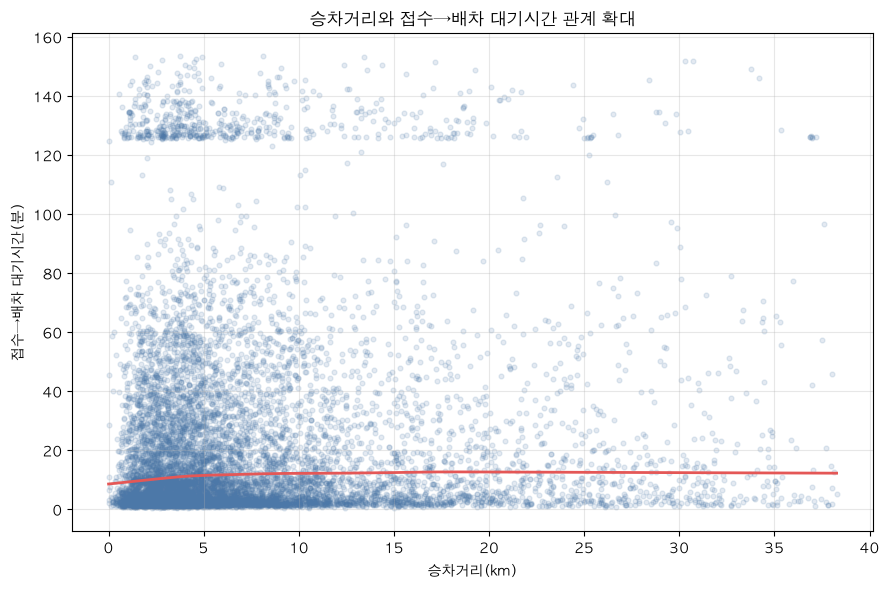

In [174]:
# 99분위수 기준 확대 산점도
x_limit = rental_ride_normal["승차거리_km"].quantile(0.99)
y_limit = rental_ride_normal["접수_배차_분"].quantile(0.99)

scatter_data_zoom = rental_ride_normal[
    rental_ride_normal["승차거리_km"].between(0, x_limit, inclusive="both")
    & rental_ride_normal["접수_배차_분"].between(0, y_limit, inclusive="both")
][
    ["승차거리_km", "접수_배차_분"]
].dropna().copy()

scatter_sample_zoom = scatter_data_zoom.sample(
    n=min(10000, len(scatter_data_zoom)),
    random_state=42,
)

fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(
    data=scatter_sample_zoom,
    x="승차거리_km",
    y="접수_배차_분",
    scatter_kws={
        "alpha": 0.15,
        "s": 12,
        "color": "#4c78a8",
    },
    line_kws={
        "color": "#e45756",
        "linewidth": 2,
    },
    lowess=True,
    ax=ax,
)

ax.set_title("승차거리와 접수→배차 대기시간 관계 확대")
ax.set_xlabel("승차거리(km)")
ax.set_ylabel("접수→배차 대기시간(분)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

*승차거리가 길어질수록 접수→배차 대기시간도 같이 길어지는 경향이 있나?*
- 추세선이 오른쪽으로 갈수록 올라감
  → 승차거리가 길수록 배차 대기시간이 길어지는 경향
- 추세선이 거의 평평함
  → 승차거리와 배차 대기시간의 관계가 약함

빨간 추세선이 살짝 올라가긴 하지만 거의 평평한 편이야. => “장거리라서 배차가 확 늦어진다”는 근거는 약함

## 8-2. 0~5km 단거리 이동의 세부이동유형 확인

승차거리가 짧은 이동이 모두 `구 내 이동`인지 확인한다.

행정구 기준으로는 `구 간 이동`이더라도 실제 거리는 짧을 수 있다. 예를 들어 자치구 경계에 가까운 지역에서 인접 구로 이동하는 경우, `출발구 != 목적구`이지만 승차거리는 0~5km 안에 포함될 수 있다.

따라서 0~5km 단거리 이동을 따로 추출한 뒤, 이 안에서 `구 내 이동`, `구 간 이동`, `서울→서울 외`, `서울 외→서울`이 각각 몇 건인지 확인한다.

확인할 내용:

- 0~5km 승차완료건수
- 구 내 이동 승차완료건수
- 0~5km 승차완료건수와 구 내 이동 승차완료건수의 차이
- 0~5km 안에서 세부이동유형별 승차완료건수
- 세부이동유형별 전체 승차완료건수 중 0~5km가 차지하는 비율

분석 근거:

`구 내 이동`은 행정구 기준이고, `0~5km 단거리 이동`은 실제 이동거리 기준이다. 두 기준은 서로 다르기 때문에 같은 값으로 해석하면 안 된다. 이 확인을 통해 단거리 이동이 실제로 구 내 이동 중심인지, 아니면 인접 구 간 단거리 이동도 많이 포함되는지 구분한다.

In [175]:
# 0~5km 단거리 데이터 생성
short_distance_ride = rental_ride_normal[
    rental_ride_normal["승차거리_km"].between(0, 5, inclusive="left")
].copy()

# 전체 비교용 건수
short_distance_count = len(short_distance_ride)

same_gu_count = (
    rental_ride_normal["세부이동유형"]
    .eq("구 내 이동")
    .sum()
)

print(f"0~5km 승차완료건수: {short_distance_count:,}건")
print(f"구 내 이동 승차완료건수: {same_gu_count:,}건")
print(f"차이: {short_distance_count - same_gu_count:,}건")

0~5km 승차완료건수: 150,731건
구 내 이동 승차완료건수: 119,011건
차이: 31,720건


In [176]:
# 0~5km 안에서 세부이동유형별 건수 확인
short_distance_movement_summary = (
    short_distance_ride
    .groupby("세부이동유형", observed=False)
    .size()
    .reset_index(name="승차완료건수")
    .sort_values("승차완료건수", ascending=False)
    .reset_index(drop=True)
)

short_distance_movement_summary["비율(%)"] = (
    short_distance_movement_summary["승차완료건수"]
    / short_distance_movement_summary["승차완료건수"].sum()
    * 100
)

display(short_distance_movement_summary)

,세부이동유형,승차완료건수,비율(%)
0,구 내 이동,105714,70.134213
1,구 간 이동,43306,28.730653
2,서울→서울 외,1642,1.089358
3,서울 외→서울,69,0.045777


In [177]:
# 전체 이동유형별 승차완료건수와 0~5km 단거리 내 이동유형별 건수 비교
movement_total_summary = (
    rental_ride_normal
    .groupby("세부이동유형", observed=False)
    .size()
    .reset_index(name="전체승차완료건수")
)

short_distance_movement_compare = movement_total_summary.merge(
    short_distance_movement_summary,
    on="세부이동유형",
    how="left"
)

short_distance_movement_compare = short_distance_movement_compare.rename(
    columns={
        "승차완료건수": "0~5km승차완료건수",
        "비율(%)": "0~5km내비율(%)",
    }
)

short_distance_movement_compare["0~5km승차완료건수"] = (
    short_distance_movement_compare["0~5km승차완료건수"]
    .fillna(0)
    .astype(int)
)

short_distance_movement_compare["전체중_0~5km비율(%)"] = (
    short_distance_movement_compare["0~5km승차완료건수"]
    / short_distance_movement_compare["전체승차완료건수"]
    * 100
)

display(short_distance_movement_compare)

,세부이동유형,전체승차완료건수,0~5km승차완료건수,0~5km내비율(%),전체중_0~5km비율(%)
0,구 간 이동,164698,43306,28.730653,26.294187
1,구 내 이동,119011,105714,70.134213,88.827083
2,서울 외→서울,1551,69,0.045777,4.448743
3,서울→서울 외,20469,1642,1.089358,8.021887


| 지표 | 분모 | 의미 |
|---|---:|---|
| `0~5km내비율(%)` | 0~5km 전체 건수 | 단거리 이동 안에서 어떤 유형이 많은가 |
| `전체중_0~5km비율(%)` | 해당 이동유형 전체 건수 | 해당 이동유형 자체가 얼마나 단거리인가 |

## 9. 장시간 대기 건 특징 분석

임차택시 바로콜 승차완료 건 중 `접수→배차` 또는 `접수→승차` 대기시간이 긴 건을 따로 추출해 특징을 확인한다.

장시간 대기 기준은 각 지표의 90분위수로 설정한다. 90분위수는 전체 건 중 상위 10%에 해당하는 긴 대기 사례를 의미하므로, 일반적인 대기시간이 아니라 운영상 부담이 큰 대기 사례를 확인하는 데 적합하다.

확인할 내용:

- 장시간 대기 건수
- 장시간 대기 건 비율
- 장시간 대기 건의 접수시간대 분포
- 장시간 대기 건의 요일 분포
- 장시간 대기 건의 출발구 분포
- 장시간 대기 건의 세부이동유형 분포
- 장시간 대기 건의 승차거리구간 분포

분석 근거:

전체 평균이나 중앙값만 보면 일부 이용자가 겪는 긴 대기 문제가 드러나지 않을 수 있다. 따라서 상위 10% 장시간 대기 건을 따로 분리해, 특정 시간대, 지역, 이동유형, 승차거리구간에 집중되는지 확인한다. 만약 장시간 대기 건이 특정 조건에 집중된다면 해당 조건은 임차택시 배차 지연의 주요 관리 대상이 될 수 있다.

In [178]:
# 장시간 대기 기준 생성 및 전체 건수 확인
long_wait_dispatch_cutoff = rental_ride_normal["접수_배차_분"].quantile(0.90)
long_wait_ride_cutoff = rental_ride_normal["접수_승차_분"].quantile(0.90)

print(f"접수→배차 90분위수 기준: {long_wait_dispatch_cutoff:.1f}분")
print(f"접수→승차 90분위수 기준: {long_wait_ride_cutoff:.1f}분")

rental_ride_normal["접수_배차_장시간대기여부"] = (
    rental_ride_normal["접수_배차_분"] >= long_wait_dispatch_cutoff
)

rental_ride_normal["접수_승차_장시간대기여부"] = (
    rental_ride_normal["접수_승차_분"] >= long_wait_ride_cutoff
)

rental_ride_normal["장시간대기여부"] = (
    rental_ride_normal["접수_배차_장시간대기여부"]
    | rental_ride_normal["접수_승차_장시간대기여부"]
)

long_wait_ride = rental_ride_normal[
    rental_ride_normal["장시간대기여부"]
].copy()

long_wait_summary = pd.DataFrame({
    "구분": [
        "전체 승차완료",
        "접수→배차 장시간 대기",
        "접수→승차 장시간 대기",
        "접수→배차 또는 접수→승차 장시간 대기",
    ],
    "건수": [
        len(rental_ride_normal),
        rental_ride_normal["접수_배차_장시간대기여부"].sum(),
        rental_ride_normal["접수_승차_장시간대기여부"].sum(),
        rental_ride_normal["장시간대기여부"].sum(),
    ],
})

long_wait_summary["비율(%)"] = (
    long_wait_summary["건수"] / len(rental_ride_normal) * 100
)

display(long_wait_summary)

접수→배차 90분위수 기준: 66.6분
접수→승차 90분위수 기준: 87.3분


,구분,건수,비율(%)
0,전체 승차완료,305729,100.000000
1,접수→배차 장시간 대기,30573,10.000033
2,접수→승차 장시간 대기,30573,10.000033
3,접수→배차 또는 접수→승차 장시간 대기,32647,10.678411


In [179]:
# 장시간 대기 비율 집계 함수 생성
def summarize_long_wait_share(df, group_col):
    summary = (
        df
        .groupby(group_col, observed=False)
        .agg(
            전체건수=("장시간대기여부", "size"),
            장시간대기건수=("장시간대기여부", "sum"),
        )
        .reset_index()
    )

    summary["장시간대기비율(%)"] = (
        summary["장시간대기건수"] / summary["전체건수"] * 100
    )

    return (
        summary
        .sort_values(["장시간대기비율(%)", "장시간대기건수"], ascending=False)
        .reset_index(drop=True)
    )

In [180]:
# 조건별 장시간 대기 비율 표 생성
long_wait_by_hour = summarize_long_wait_share(
    rental_ride_normal,
    "접수시간대"
)

long_wait_by_weekday = summarize_long_wait_share(
    rental_ride_normal,
    "접수요일"
)

long_wait_by_district = summarize_long_wait_share(
    rental_ride_normal,
    "출발구"
)

long_wait_by_movement = summarize_long_wait_share(
    rental_ride_normal,
    "세부이동유형"
)

long_wait_by_distance = summarize_long_wait_share(
    rental_ride_normal,
    "승차거리구간"
)

display(long_wait_by_hour)
display(long_wait_by_weekday)
display(long_wait_by_district.head(20))
display(long_wait_by_movement)
display(long_wait_by_distance)

,접수시간대,전체건수,장시간대기건수,장시간대기비율(%)
0,03:00:00,2760,2760,100.000000
1,02:00:00,44,44,100.000000
2,04:00:00,5019,4991,99.442120
3,05:00:00,4106,2256,54.943984
4,06:00:00,4785,1267,26.478579
5,08:00:00,12438,2527,20.316771
6,07:00:00,12702,2009,15.816407
7,15:00:00,35841,4286,11.958372
8,09:00:00,18390,1849,10.054377
9,16:00:00,20176,1884,9.337827


,접수요일,전체건수,장시간대기건수,장시간대기비율(%)
0,수,61267,7088,11.569034
1,금,55756,6133,10.999713
2,월,58664,6229,10.618096
3,토,8034,843,10.492905
4,목,57970,5923,10.217354
5,화,58916,5939,10.080454
6,일,5122,492,9.605623


,출발구,전체건수,장시간대기건수,장시간대기비율(%)
0,의왕시,1,1,100.000000
1,김포시,356,338,94.943820
2,성남시분당구,124,117,94.354839
3,양주시,144,135,93.750000
4,남양주시,335,300,89.552239
5,안양시만안구,13,11,84.615385
6,부천시원미구,65,54,83.076923
7,고양시일산서구,32,24,75.000000
8,부천시소사구,12,9,75.000000
9,안양시동안구,8,6,75.000000


,세부이동유형,전체건수,장시간대기건수,장시간대기비율(%)
0,서울 외→서울,1551,1265,81.560284
1,구 간 이동,164698,18927,11.491943
2,구 내 이동,119011,10708,8.997488
3,서울→서울 외,20469,1747,8.534858


,승차거리구간,전체건수,장시간대기건수,장시간대기비율(%)
0,25km 초과,14468,3007,20.783799
1,15~25km,27486,3923,14.272721
2,10~15km,31119,3507,11.269642
3,5~10km,81925,7900,9.642966
4,0~5km,150731,14310,9.493734


장시간 장거리

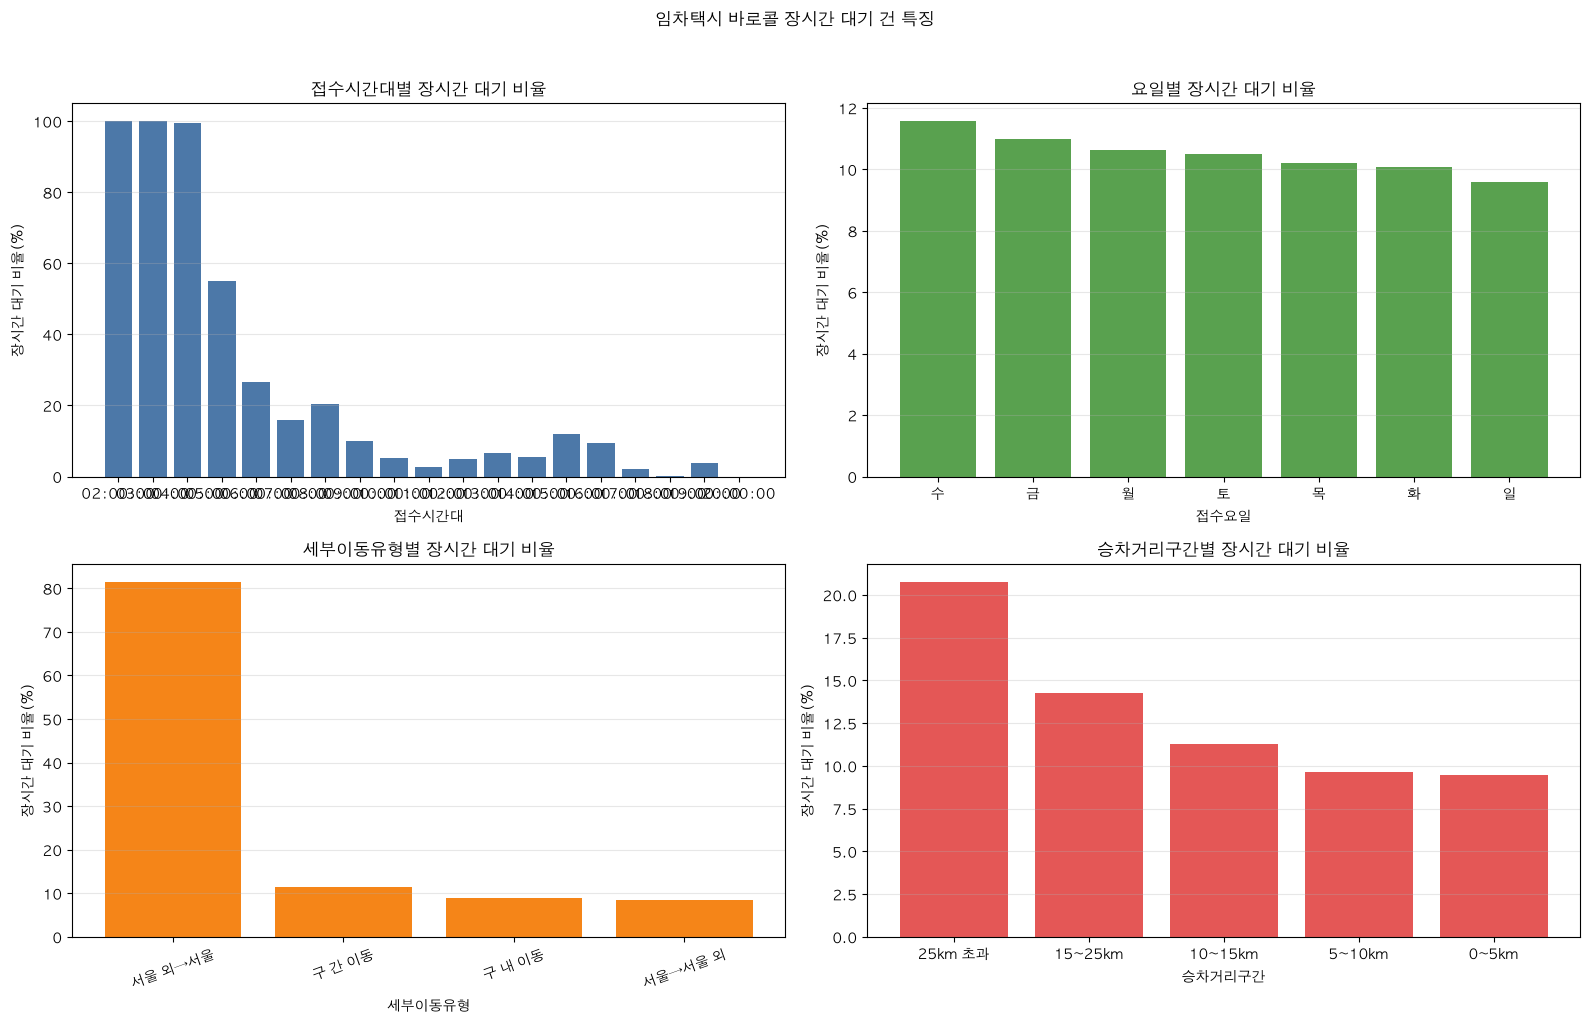

In [181]:
# 시간대·요일·이동유형·승차거리구간별 장시간 대기 비율 그래프
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_hour = long_wait_by_hour.sort_values("접수시간대")
axes[0, 0].bar(
    plot_hour["접수시간대"],
    plot_hour["장시간대기비율(%)"],
    color="#4c78a8",
)
axes[0, 0].set_title("접수시간대별 장시간 대기 비율")
axes[0, 0].set_xlabel("접수시간대")
axes[0, 0].set_ylabel("장시간 대기 비율(%)")
axes[0, 0].grid(axis="y", alpha=0.3)

plot_weekday = long_wait_by_weekday.copy()
axes[0, 1].bar(
    plot_weekday["접수요일"],
    plot_weekday["장시간대기비율(%)"],
    color="#59a14f",
)
axes[0, 1].set_title("요일별 장시간 대기 비율")
axes[0, 1].set_xlabel("접수요일")
axes[0, 1].set_ylabel("장시간 대기 비율(%)")
axes[0, 1].grid(axis="y", alpha=0.3)

plot_movement = long_wait_by_movement.sort_values(
    "장시간대기비율(%)",
    ascending=False
)
axes[1, 0].bar(
    plot_movement["세부이동유형"],
    plot_movement["장시간대기비율(%)"],
    color="#f58518",
)
axes[1, 0].set_title("세부이동유형별 장시간 대기 비율")
axes[1, 0].set_xlabel("세부이동유형")
axes[1, 0].set_ylabel("장시간 대기 비율(%)")
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].grid(axis="y", alpha=0.3)

plot_distance = long_wait_by_distance.copy()
axes[1, 1].bar(
    plot_distance["승차거리구간"].astype(str),
    plot_distance["장시간대기비율(%)"],
    color="#e45756",
)
axes[1, 1].set_title("승차거리구간별 장시간 대기 비율")
axes[1, 1].set_xlabel("승차거리구간")
axes[1, 1].set_ylabel("장시간 대기 비율(%)")
axes[1, 1].grid(axis="y", alpha=0.3)

plt.suptitle("임차택시 바로콜 장시간 대기 건 특징", y=1.02)
plt.tight_layout()
plt.show()

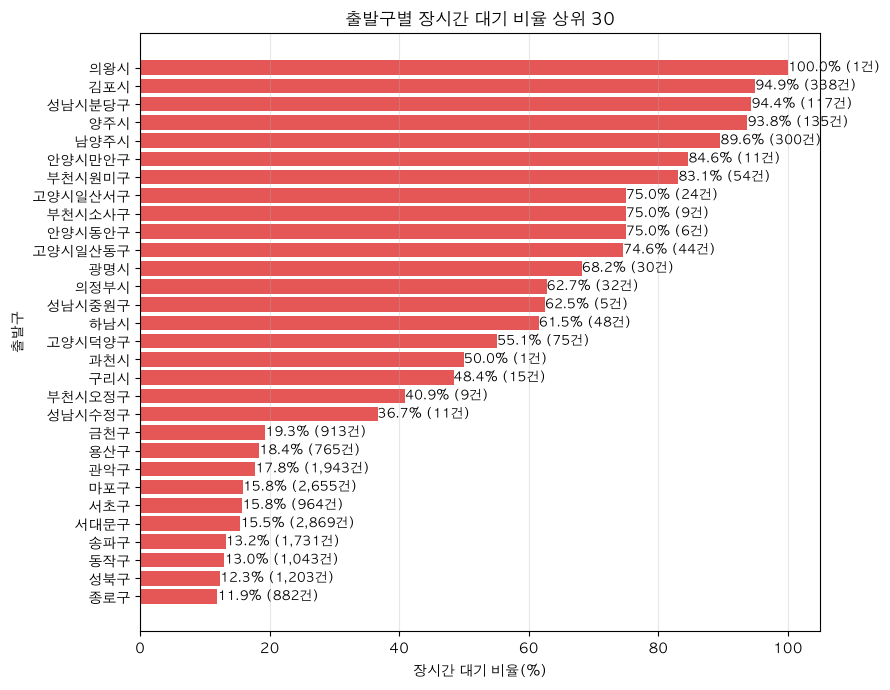

In [182]:
# 출발구별 장시간 대기 비율 TOP 30 그래프
plot_district = long_wait_by_district.head(30).sort_values(
    "장시간대기비율(%)",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    plot_district["출발구"],
    plot_district["장시간대기비율(%)"],
    color="#e45756",
)

for _, row in plot_district.iterrows():
    ax.text(
        row["장시간대기비율(%)"],
        row["출발구"],
        f'{row["장시간대기비율(%)"]:.1f}% ({row["장시간대기건수"]:,}건)',
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_title("출발구별 장시간 대기 비율 상위 30")
ax.set_xlabel("장시간 대기 비율(%)")
ax.set_ylabel("출발구")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 10. 취소율과 대기시간 관계 분석

임차택시 바로콜에서 어떤 조건일 때 취소가 많이 발생하는지 확인한다.

취소율은 `바로콜 취소건수 / (바로콜 승차완료건수 + 바로콜 취소건수)`로 계산한다. 승차완료 건과 취소 건은 기준 컬럼이 다르므로, 각각 `rental_ride_normal`과 `rental_cancel_normal`을 사용해 집계한 뒤 합쳐서 비교한다.

확인할 내용:

- 접수시간대별 취소율
- 요일별 취소율
- 출발구별 취소율
- 세부이동유형별 취소율
- 승차완료 건의 접수→배차 대기시간과 취소율의 관계

분석 근거:

취소율은 단순 취소건수보다 해석력이 높다. 취소건수가 많은 지역이나 시간대는 전체 호출 자체가 많아서 취소건수도 많을 수 있기 때문이다. 따라서 승차완료건수와 취소건수를 함께 놓고 취소율을 계산해야, 실제로 취소가 상대적으로 많이 발생하는 조건을 확인할 수 있다.

In [183]:
# 취소율 집계 함수 생성
def summarize_cancel_rate(ride_df, cancel_df, group_col):
    ride_summary = (
        ride_df
        .groupby(group_col, observed=False)
        .size()
        .reset_index(name="승차완료건수")
    )

    cancel_summary = (
        cancel_df
        .groupby(group_col, observed=False)
        .size()
        .reset_index(name="취소건수")
    )

    summary = ride_summary.merge(
        cancel_summary,
        on=group_col,
        how="outer",
    )

    summary["승차완료건수"] = summary["승차완료건수"].fillna(0).astype(int)
    summary["취소건수"] = summary["취소건수"].fillna(0).astype(int)
    summary["전체접수건수"] = summary["승차완료건수"] + summary["취소건수"]

    summary["취소율(%)"] = (
        summary["취소건수"] / summary["전체접수건수"] * 100
    )

    return (
        summary
        .sort_values(["취소율(%)", "전체접수건수"], ascending=False)
        .reset_index(drop=True)
    )

In [184]:
# 조건별 취소율 표 생성
cancel_rate_by_hour = summarize_cancel_rate(
    rental_ride_normal,
    rental_cancel_normal,
    "접수시간대",
)

cancel_rate_by_weekday = summarize_cancel_rate(
    rental_ride_normal,
    rental_cancel_normal,
    "접수요일",
)

cancel_rate_by_district = summarize_cancel_rate(
    rental_ride_normal,
    rental_cancel_normal,
    "출발구",
)

cancel_rate_by_movement = summarize_cancel_rate(
    rental_ride_normal,
    rental_cancel_normal,
    "세부이동유형",
)

display(cancel_rate_by_hour)
display(cancel_rate_by_weekday)
display(cancel_rate_by_district.head(20))
display(cancel_rate_by_movement)

,접수시간대,승차완료건수,취소건수,전체접수건수,취소율(%)
0,20:00:00,1,1,2,50.000000
1,05:00:00,4106,554,4660,11.888412
2,19:00:00,52,7,59,11.864407
3,17:00:00,12092,1283,13375,9.592523
4,06:00:00,4785,491,5276,9.306293
5,16:00:00,20176,2045,22221,9.203006
6,03:00:00,2760,274,3034,9.030982
7,07:00:00,12702,1155,13857,8.335137
8,18:00:00,3122,283,3405,8.311307
9,08:00:00,12438,867,13305,6.516347


,접수요일,승차완료건수,취소건수,전체접수건수,취소율(%)
0,토,8034,440,8474,5.192353
1,목,57970,3140,61110,5.138275
2,금,55756,2981,58737,5.075166
3,화,58916,3140,62056,5.059946
4,수,61267,3217,64484,4.988834
5,일,5122,264,5386,4.901597
6,월,58664,3001,61665,4.866618


,출발구,승차완료건수,취소건수,전체접수건수,취소율(%)
0,강남구,9437,901,10338,8.715419
1,금천구,4730,446,5176,8.616692
2,종로구,7391,673,8064,8.345734
3,서초구,6118,552,6670,8.275862
4,영등포구,11635,829,12464,6.651155
5,용산구,4168,293,4461,6.568034
6,중구,3057,210,3267,6.427916
7,은평구,16927,1107,18034,6.138405
8,관악구,10941,715,11656,6.134180
9,동작구,8011,517,8528,6.062383


,세부이동유형,승차완료건수,취소건수,전체접수건수,취소율(%)
0,구 간 이동,164698,9015,173713,5.189594
1,구 내 이동,119011,6206,125217,4.956196
2,서울→서울 외,20469,956,21425,4.462077
3,서울 외→서울,1551,6,1557,0.385356


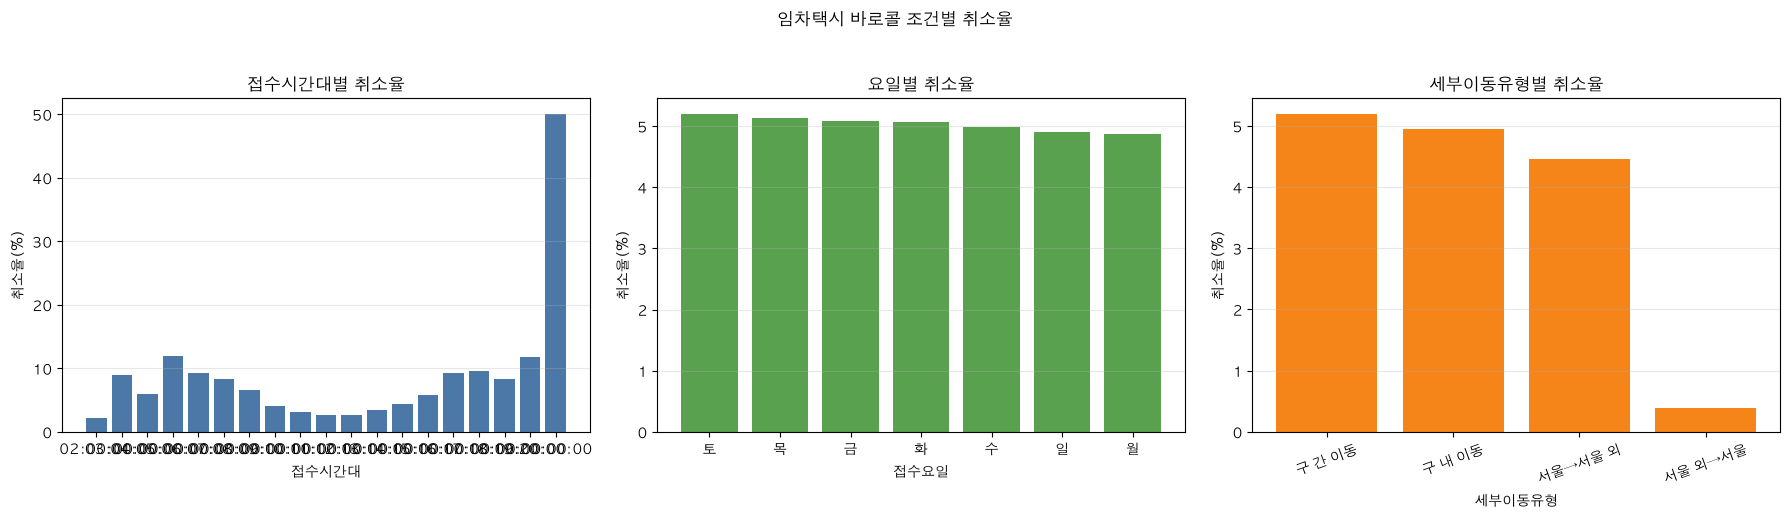

In [185]:
# 접수시간대·요일·세부이동유형별 취소율 그래프
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_hour = cancel_rate_by_hour.sort_values("접수시간대")
axes[0].bar(
    plot_hour["접수시간대"],
    plot_hour["취소율(%)"],
    color="#4c78a8",
)
axes[0].set_title("접수시간대별 취소율")
axes[0].set_xlabel("접수시간대")
axes[0].set_ylabel("취소율(%)")
axes[0].grid(axis="y", alpha=0.3)

plot_weekday = cancel_rate_by_weekday.copy()
axes[1].bar(
    plot_weekday["접수요일"],
    plot_weekday["취소율(%)"],
    color="#59a14f",
)
axes[1].set_title("요일별 취소율")
axes[1].set_xlabel("접수요일")
axes[1].set_ylabel("취소율(%)")
axes[1].grid(axis="y", alpha=0.3)

plot_movement = cancel_rate_by_movement.sort_values(
    "취소율(%)",
    ascending=False,
)
axes[2].bar(
    plot_movement["세부이동유형"],
    plot_movement["취소율(%)"],
    color="#f58518",
)
axes[2].set_title("세부이동유형별 취소율")
axes[2].set_xlabel("세부이동유형")
axes[2].set_ylabel("취소율(%)")
axes[2].tick_params(axis="x", rotation=20)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("임차택시 바로콜 조건별 취소율", y=1.03)
plt.tight_layout()
plt.show()

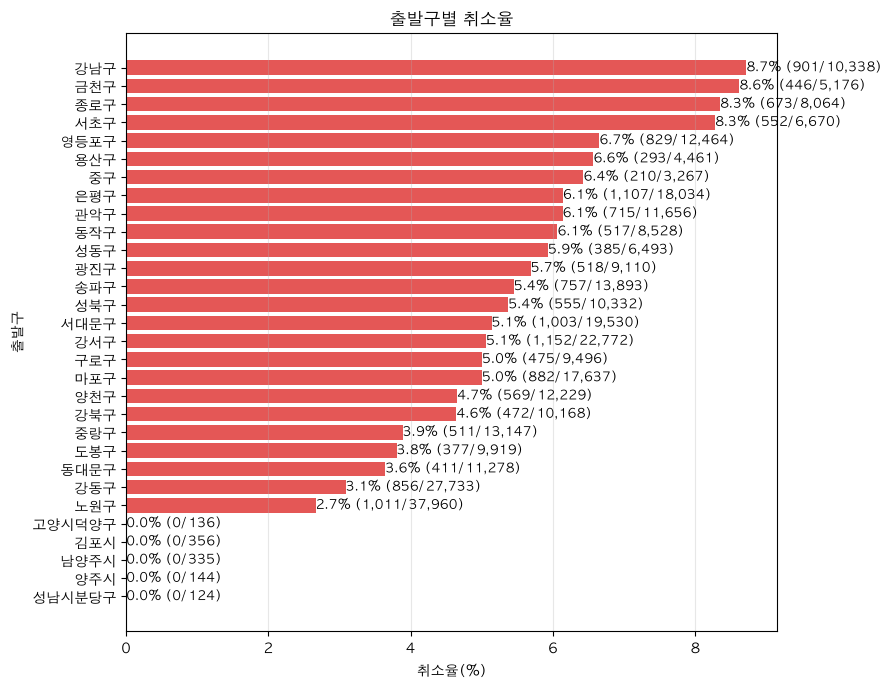

In [186]:
# 출발구별 취소율 TOP 15 그래프
plot_district = (
    cancel_rate_by_district
    .query("전체접수건수 >= 100")
    .sort_values("취소율(%)", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    plot_district["출발구"],
    plot_district["취소율(%)"],
    color="#e45756",
)

for _, row in plot_district.iterrows():
    ax.text(
        row["취소율(%)"],
        row["출발구"],
        f'{row["취소율(%)"]:.1f}% ({row["취소건수"]:,}/{row["전체접수건수"]:,})',
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_title("출발구별 취소율")
ax.set_xlabel("취소율(%)")
ax.set_ylabel("출발구")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 배차 후 취소 원인 후보 분석

임차택시 바로콜 취소 건 중 배차 후 취소된 건의 시간 흐름을 확인한다.

배차 후 취소는 `배차일시`와 `취소일시`가 모두 있는 건으로 정의한다. 이때 `배차→취소` 시간이 짧다면, 실제로 배차 후 오래 기다리다가 취소했다기보다 배차 직후 이용자 사정 변경, 안내 과정에서의 취소, 또는 기록 처리 특성일 가능성이 있다.

확인할 내용:

- `배차→취소` 0~5분 취소 비율
- 배차 직후 취소가 특정 시간대에 몰리는지
- 배차 직후 취소가 특정 출발구에 몰리는지
- `배차→취소`가 긴 건의 원자료

분석 근거:

취소 건의 대부분이 배차 후 취소로 기록되더라도, `배차→취소` 시간이 매우 짧다면 배차 후 장시간 대기 때문에 취소했다고 보기 어렵다. 따라서 배차 후 취소는 단순 건수보다 배차 이후 몇 분 만에 취소되었는지를 중심으로 해석한다.

In [187]:
# 배차 후 취소 데이터 생성 및 0~5분 취소 비율 확인
cancel_after_dispatch = rental_cancel_normal[
    rental_cancel_normal["배차_취소_분"].notna()
].copy()

cancel_after_dispatch["배차직후취소_0_5분여부"] = (
    cancel_after_dispatch["배차_취소_분"].between(0, 5, inclusive="both")
)

cancel_after_dispatch_summary = pd.DataFrame({
    "구분": [
        "배차 후 취소 전체",
        "배차→취소 0~5분",
        "배차→취소 5분 초과",
    ],
    "건수": [
        len(cancel_after_dispatch),
        cancel_after_dispatch["배차직후취소_0_5분여부"].sum(),
        (~cancel_after_dispatch["배차직후취소_0_5분여부"]).sum(),
    ],
})

cancel_after_dispatch_summary["비율(%)"] = (
    cancel_after_dispatch_summary["건수"]
    / len(cancel_after_dispatch)
    * 100
)

display(cancel_after_dispatch_summary)

,구분,건수,비율(%)
0,배차 후 취소 전체,16167,100.000000
1,배차→취소 0~5분,11769,72.796437
2,배차→취소 5분 초과,4398,27.203563


In [188]:
# 코드 셀 2: 배차→취소 시간 구간별 분포 확인
cancel_after_dispatch_bins = [
    0,
    1,
    3,
    5,
    10,
    20,
    30,
    60,
    float("inf"),
]

cancel_after_dispatch_labels = [
    "0~1분",
    "1~3분",
    "3~5분",
    "5~10분",
    "10~20분",
    "20~30분",
    "30~60분",
    "60분 초과",
]

cancel_after_dispatch["배차_취소_구간"] = pd.cut(
    cancel_after_dispatch["배차_취소_분"],
    bins=cancel_after_dispatch_bins,
    labels=cancel_after_dispatch_labels,
    right=False,
)

cancel_after_dispatch_bin_summary = (
    cancel_after_dispatch
    .groupby("배차_취소_구간", observed=False)
    .size()
    .reset_index(name="취소건수")
)

cancel_after_dispatch_bin_summary["비율(%)"] = (
    cancel_after_dispatch_bin_summary["취소건수"]
    / cancel_after_dispatch_bin_summary["취소건수"].sum()
    * 100
)

cancel_after_dispatch_bin_summary["누적비율(%)"] = (
    cancel_after_dispatch_bin_summary["비율(%)"].cumsum()
)

display(cancel_after_dispatch_bin_summary)

,배차_취소_구간,취소건수,비율(%),누적비율(%)
0,0~1분,1483,9.173007,9.173007
1,1~3분,7378,45.636172,54.809179
2,3~5분,2908,17.987258,72.796437
3,5~10분,2205,13.638894,86.435331
4,10~20분,1530,9.463722,95.899054
5,20~30분,456,2.820560,98.719614
6,30~60분,184,1.138121,99.857735
7,60분 초과,23,0.142265,100.000000


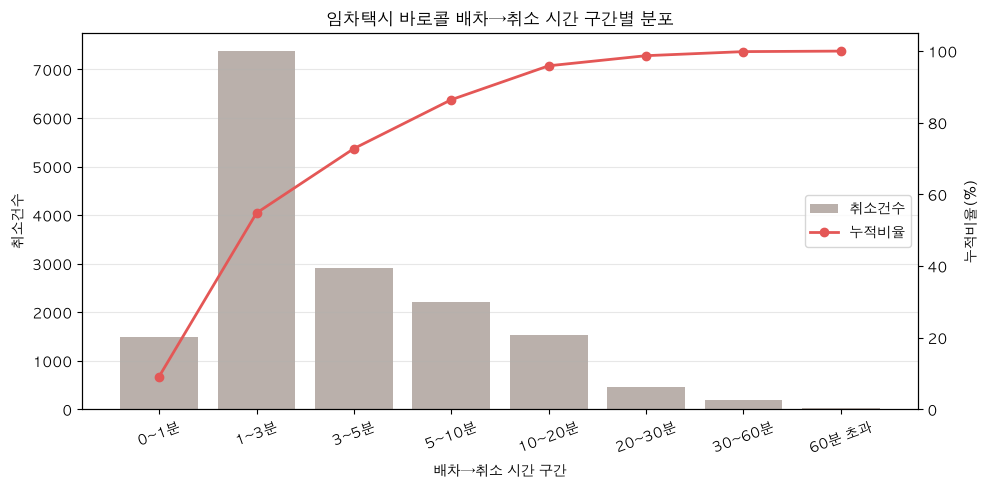

In [189]:
# 배차→취소 시간 구간별 그래프
fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(cancel_after_dispatch_bin_summary))

ax1.bar(
    x,
    cancel_after_dispatch_bin_summary["취소건수"],
    color="#bab0ab",
    label="취소건수",
)

ax1.set_xlabel("배차→취소 시간 구간")
ax1.set_ylabel("취소건수")
ax1.set_xticks(list(x))
ax1.set_xticklabels(
    cancel_after_dispatch_bin_summary["배차_취소_구간"].astype(str),
    rotation=20,
)
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    x,
    cancel_after_dispatch_bin_summary["누적비율(%)"],
    marker="o",
    color="#e45756",
    linewidth=2,
    label="누적비율",
)

ax2.set_ylabel("누적비율(%)")
ax2.set_ylim(0, 105)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center right",
)

ax1.set_title("임차택시 바로콜 배차→취소 시간 구간별 분포")

plt.tight_layout()
plt.show()

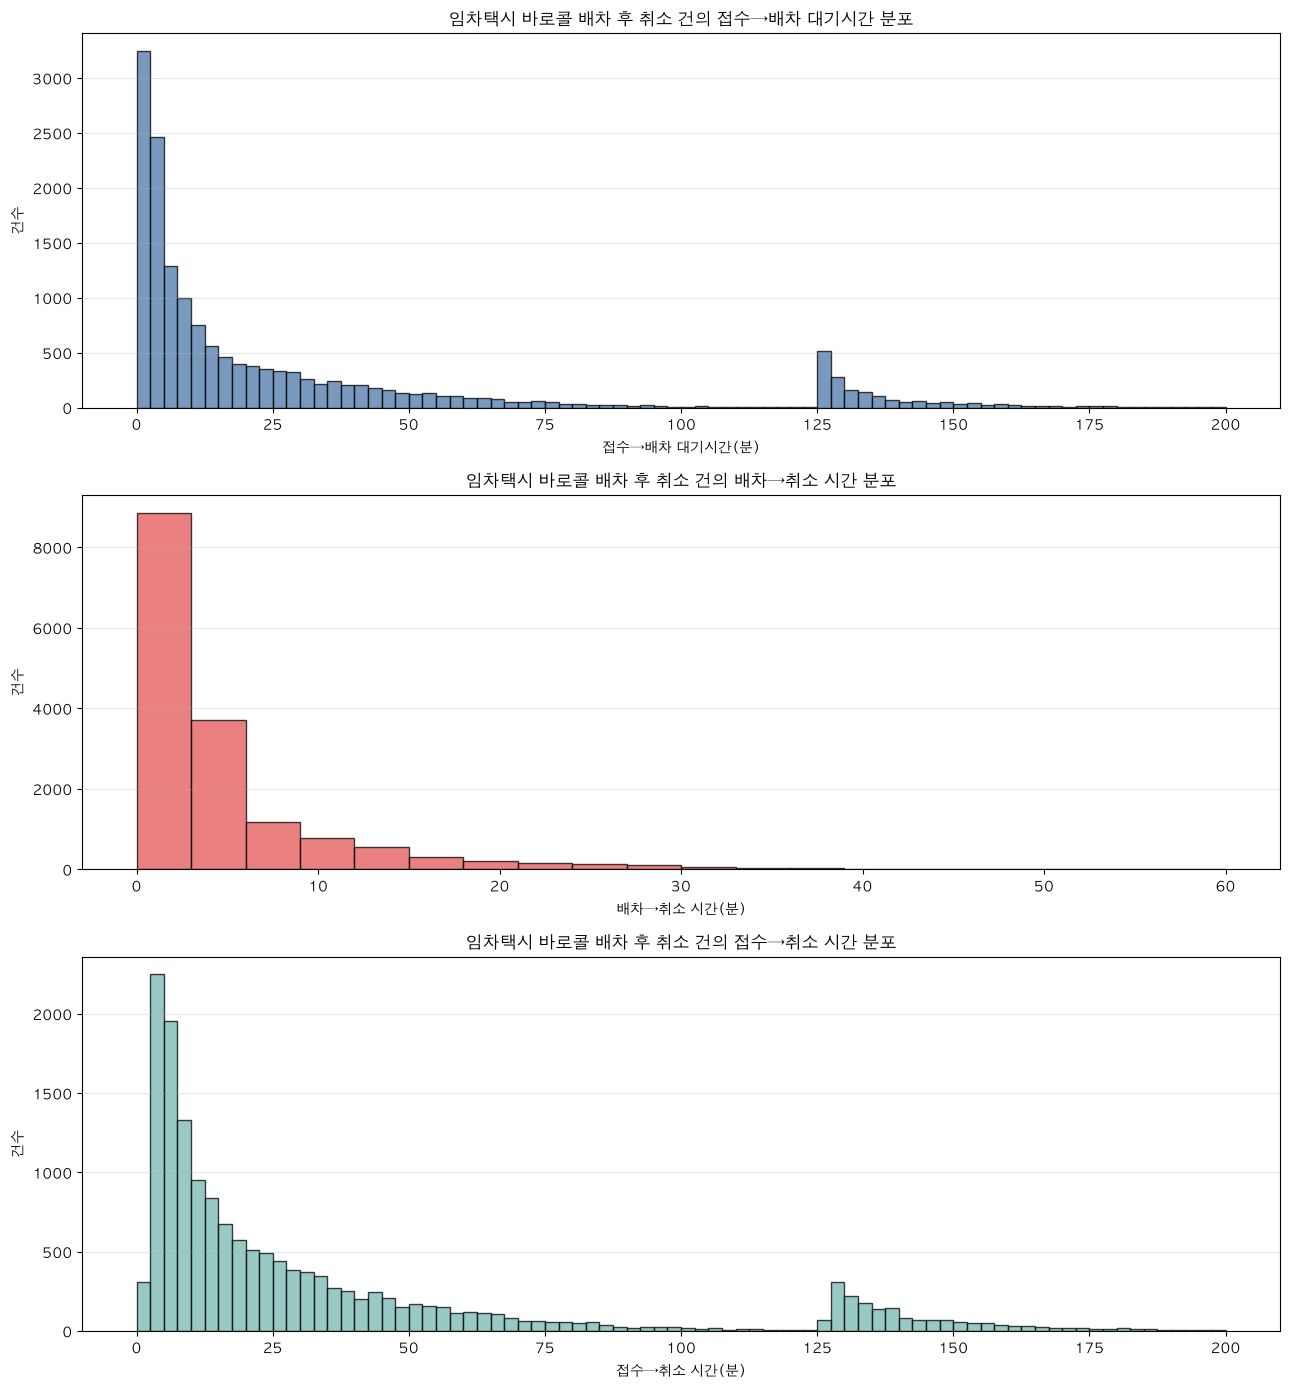

In [190]:
# 코드 셀 목적: 임차택시 바로콜 배차 후 취소 건의 접수→배차, 배차→취소, 접수→취소 시간 분포를 확인한다.

rental_dispatch_cancel = rental_cancel_normal[
    rental_cancel_normal["배차일시"].notna()
].copy()

wait_cols = [
    "접수_배차_분",
    "배차_취소_분",
    "접수_취소_분",
]

for col in wait_cols:
    rental_dispatch_cancel[col] = pd.to_numeric(
        rental_dispatch_cancel[col],
        errors="coerce",
    )

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

axes[0].hist(
    rental_dispatch_cancel["접수_배차_분"].dropna(),
    bins=80,
    range=(0, 200),
    color="#4c78a8",
    edgecolor="black",
    alpha=0.75,
)
axes[0].set_title("임차택시 바로콜 배차 후 취소 건의 접수→배차 대기시간 분포")
axes[0].set_xlabel("접수→배차 대기시간(분)")
axes[0].set_ylabel("건수")
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(
    rental_dispatch_cancel["배차_취소_분"].dropna(),
    bins=20,
    range=(0, 60),
    color="#e45756",
    edgecolor="black",
    alpha=0.75,
)
axes[1].set_title("임차택시 바로콜 배차 후 취소 건의 배차→취소 시간 분포")
axes[1].set_xlabel("배차→취소 시간(분)")
axes[1].set_ylabel("건수")
axes[1].grid(axis="y", alpha=0.3)

axes[2].hist(
    rental_dispatch_cancel["접수_취소_분"].dropna(),
    bins=80,
    range=(0, 200),
    color="#76b7b2",
    edgecolor="black",
    alpha=0.75,
)
axes[2].set_title("임차택시 바로콜 배차 후 취소 건의 접수→취소 시간 분포")
axes[2].set_xlabel("접수→취소 시간(분)")
axes[2].set_ylabel("건수")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

,배차시간대_HH,배차후취소건수,배차직후_0_5분_취소건수,접수_배차_중앙값,배차_취소_중앙값,접수_취소_중앙값
0,00,0.0,0.0,NaN,NaN,NaN
1,01,0.0,0.0,NaN,NaN,NaN
2,02,0.0,0.0,NaN,NaN,NaN
3,03,0.0,0.0,NaN,NaN,NaN
4,04,0.0,0.0,NaN,NaN,NaN
5,05,0.0,0.0,NaN,NaN,NaN
6,06,887.0,686.0,125.894000,2.530950,127.593950
7,07,1208.0,939.0,11.050700,2.391608,15.842808
8,08,1065.0,819.0,29.254933,2.491450,33.470283
9,09,791.0,543.0,30.817667,2.890717,35.774217


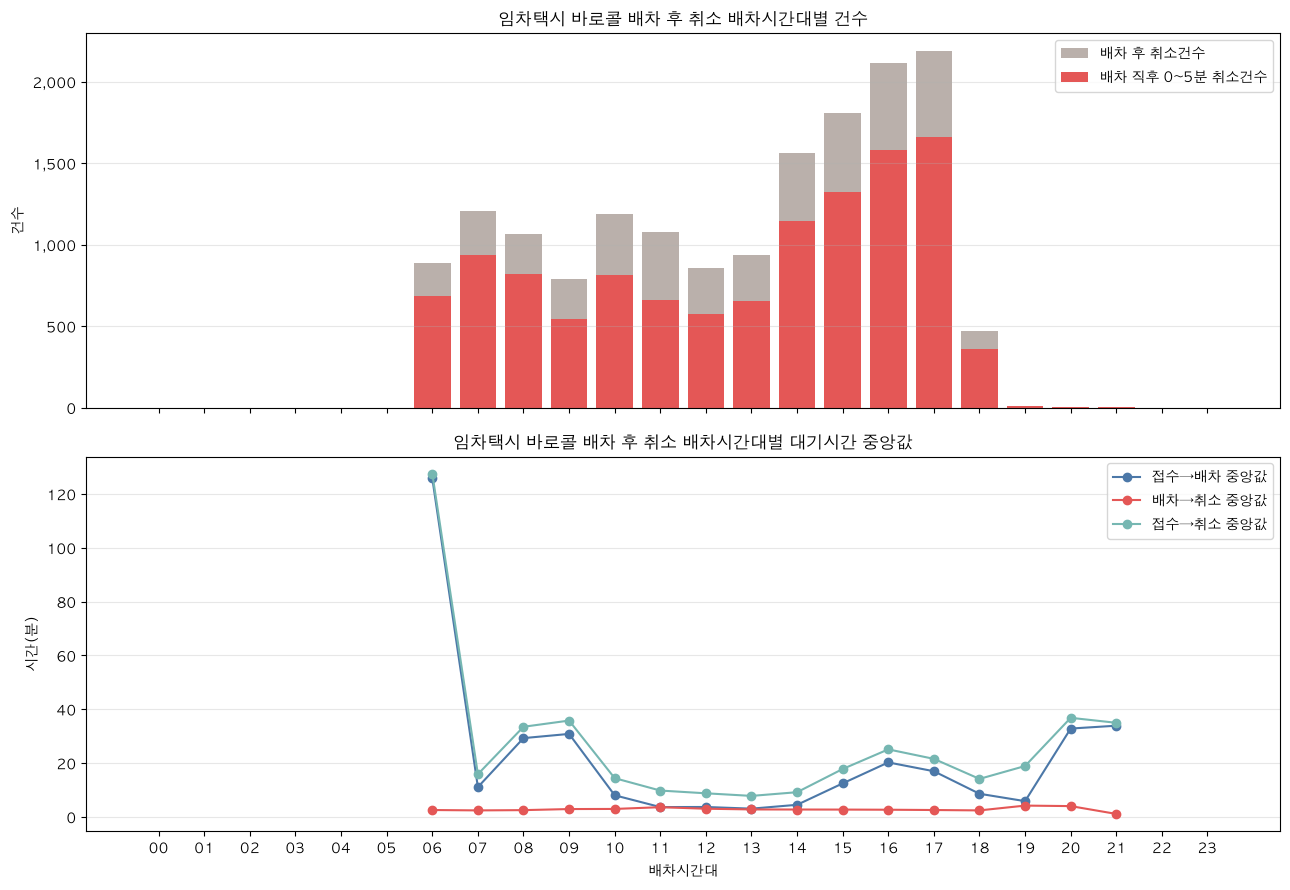

In [191]:
# 코드 셀 목적: 임차택시 바로콜 배차 후 취소 건의 배차시간대별 취소건수와 대기시간 중앙값을 확인한다.

from matplotlib.ticker import FuncFormatter

rental_dispatch_cancel = rental_cancel_normal[
    rental_cancel_normal["배차일시"].notna()
].copy()

rental_dispatch_cancel["배차일시"] = pd.to_datetime(
    rental_dispatch_cancel["배차일시"],
    errors="coerce",
)

rental_dispatch_cancel["배차시간대_HH"] = (
    rental_dispatch_cancel["배차일시"]
    .dt.strftime("%H")
)

wait_cols = [
    "접수_배차_분",
    "배차_취소_분",
    "접수_취소_분",
]

for col in wait_cols:
    rental_dispatch_cancel[col] = pd.to_numeric(
        rental_dispatch_cancel[col],
        errors="coerce",
    )

rental_dispatch_cancel["배차직후_0_5분_취소여부"] = (
    rental_dispatch_cancel["배차_취소_분"].between(0, 5, inclusive="both")
)

hour_order = [f"{hour:02d}" for hour in range(24)]

rental_dispatch_cancel_hour_summary = (
    rental_dispatch_cancel
    .groupby("배차시간대_HH", observed=False)
    .agg(
        배차후취소건수=("취소일시", "count"),
        배차직후_0_5분_취소건수=("배차직후_0_5분_취소여부", "sum"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        배차_취소_중앙값=("배차_취소_분", "median"),
        접수_취소_중앙값=("접수_취소_분", "median"),
    )
    .reindex(hour_order)
    .fillna({
        "배차후취소건수": 0,
        "배차직후_0_5분_취소건수": 0,
    })
    .reset_index()
    .rename(columns={"index": "배차시간대_HH"})
)

display(rental_dispatch_cancel_hour_summary)

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

x = rental_dispatch_cancel_hour_summary["배차시간대_HH"]

axes[0].bar(
    x,
    rental_dispatch_cancel_hour_summary["배차후취소건수"],
    color="#bab0ab",
    label="배차 후 취소건수",
)

axes[0].bar(
    x,
    rental_dispatch_cancel_hour_summary["배차직후_0_5분_취소건수"],
    color="#e45756",
    label="배차 직후 0~5분 취소건수",
)

axes[0].set_title("임차택시 바로콜 배차 후 취소 배차시간대별 건수")
axes[0].set_ylabel("건수")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

axes[1].plot(
    x,
    rental_dispatch_cancel_hour_summary["접수_배차_중앙값"],
    marker="o",
    label="접수→배차 중앙값",
    color="#4c78a8",
)

axes[1].plot(
    x,
    rental_dispatch_cancel_hour_summary["배차_취소_중앙값"],
    marker="o",
    label="배차→취소 중앙값",
    color="#e45756",
)

axes[1].plot(
    x,
    rental_dispatch_cancel_hour_summary["접수_취소_중앙값"],
    marker="o",
    label="접수→취소 중앙값",
    color="#76b7b2",
)

axes[1].set_title("임차택시 바로콜 배차 후 취소 배차시간대별 대기시간 중앙값")
axes[1].set_xlabel("배차시간대")
axes[1].set_ylabel("시간(분)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

배차_취소_구간,0~5분,5~10분,10~30분,30~60분,60분 초과
배차시간대_HH,,,,,
00,0,0,0,0,0
01,0,0,0,0,0
02,0,0,0,0,0
03,0,0,0,0,0
04,0,0,0,0,0
05,0,0,0,0,0
06,686,90,99,10,2
07,939,161,95,13,0
08,819,138,101,6,1


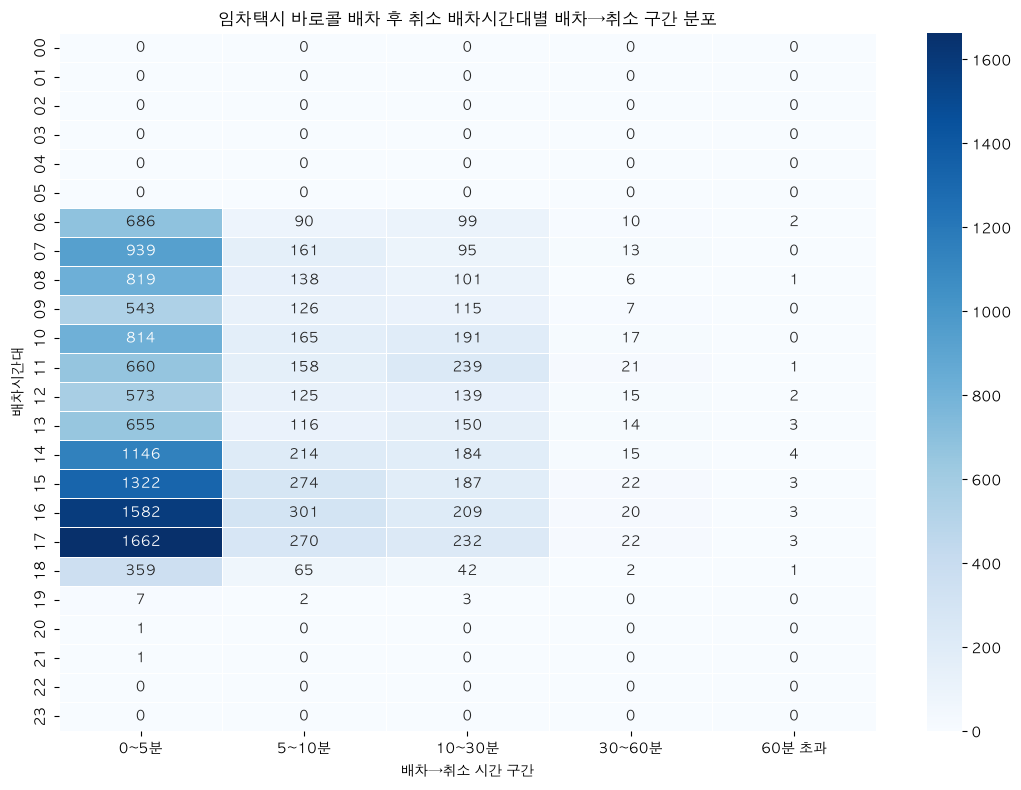

In [192]:
# 코드 셀 목적: 임차택시 바로콜 배차 후 취소 건의 배차시간대별 배차→취소 시간 구간 분포를 확인한다.

rental_dispatch_cancel_heatmap_data = rental_cancel_normal[
    rental_cancel_normal["배차일시"].notna()
].copy()

rental_dispatch_cancel_heatmap_data["배차일시"] = pd.to_datetime(
    rental_dispatch_cancel_heatmap_data["배차일시"],
    errors="coerce",
)

rental_dispatch_cancel_heatmap_data["배차시간대_HH"] = (
    rental_dispatch_cancel_heatmap_data["배차일시"]
    .dt.strftime("%H")
)

rental_dispatch_cancel_heatmap_data["배차_취소_분"] = pd.to_numeric(
    rental_dispatch_cancel_heatmap_data["배차_취소_분"],
    errors="coerce",
)

dispatch_cancel_bins = [0, 5, 10, 30, 60, float("inf")]
dispatch_cancel_labels = [
    "0~5분",
    "5~10분",
    "10~30분",
    "30~60분",
    "60분 초과",
]

rental_dispatch_cancel_heatmap_data["배차_취소_구간"] = pd.cut(
    rental_dispatch_cancel_heatmap_data["배차_취소_분"],
    bins=dispatch_cancel_bins,
    labels=dispatch_cancel_labels,
    right=True,
    include_lowest=True,
)

hour_order = [f"{hour:02d}" for hour in range(24)]

rental_dispatch_cancel_heatmap = (
    rental_dispatch_cancel_heatmap_data
    .pivot_table(
        index="배차시간대_HH",
        columns="배차_취소_구간",
        values="취소일시",
        aggfunc="count",
        observed=False,
    )
    .reindex(index=hour_order, columns=dispatch_cancel_labels)
    .fillna(0)
    .astype(int)
)

display(rental_dispatch_cancel_heatmap)

fig, ax = plt.subplots(figsize=(11, 8))

sns.heatmap(
    rental_dispatch_cancel_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("임차택시 바로콜 배차 후 취소 배차시간대별 배차→취소 구간 분포")
ax.set_xlabel("배차→취소 시간 구간")
ax.set_ylabel("배차시간대")

plt.tight_layout()
plt.show()

In [193]:
rental_dispatch_cancel_hour_summary[
    rental_dispatch_cancel_hour_summary["배차시간대_HH"].isin(
        ["22", "23", "00", "01", "02", "03", "04", "05"]
    )
]

,배차시간대_HH,배차후취소건수,배차직후_0_5분_취소건수,접수_배차_중앙값,배차_취소_중앙값,접수_취소_중앙값
0,00,0.0,0.0,NaN,NaN,NaN
1,01,0.0,0.0,NaN,NaN,NaN
2,02,0.0,0.0,NaN,NaN,NaN
3,03,0.0,0.0,NaN,NaN,NaN
4,04,0.0,0.0,NaN,NaN,NaN
5,05,0.0,0.0,NaN,NaN,NaN
22,22,0.0,0.0,NaN,NaN,NaN
23,23,0.0,0.0,NaN,NaN,NaN


In [194]:
# 접수시간대별 배차 직후 취소 집중도 확인
dispatch_quick_cancel_by_hour = (
    cancel_after_dispatch
    .groupby("접수시간대", observed=False)
    .agg(
        배차후취소건수=("배차직후취소_0_5분여부", "size"),
        배차직후취소건수=("배차직후취소_0_5분여부", "sum"),
    )
    .reset_index()
)

dispatch_quick_cancel_by_hour["배차직후취소비율(%)"] = (
    dispatch_quick_cancel_by_hour["배차직후취소건수"]
    / dispatch_quick_cancel_by_hour["배차후취소건수"]
    * 100
)

dispatch_quick_cancel_by_hour["접수시간대_HH"] = (
    dispatch_quick_cancel_by_hour["접수시간대"]
    .astype(str)
    .str.slice(0, 2)
)

dispatch_quick_cancel_by_hour = dispatch_quick_cancel_by_hour.sort_values(
    "접수시간대_HH"
)

display(dispatch_quick_cancel_by_hour)

,접수시간대,배차후취소건수,배차직후취소건수,배차직후취소비율(%),접수시간대_HH
0,02:00:00,1,0,0.000000,02
1,03:00:00,274,220,80.291971,03
2,04:00:00,321,218,67.912773,04
3,05:00:00,554,427,77.075812,05
4,06:00:00,491,355,72.301426,06
5,07:00:00,1155,922,79.826840,07
6,08:00:00,867,609,70.242215,08
7,09:00:00,796,569,71.482412,09
8,10:00:00,906,611,67.439294,10
9,11:00:00,1036,648,62.548263,11


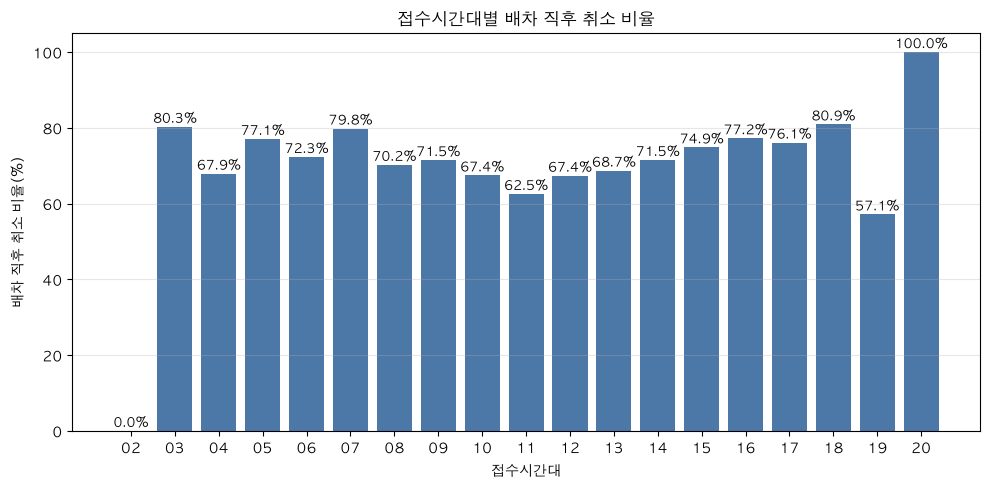

In [195]:
# 접수시간대별 배차 직후 취소 비율 그래프
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    dispatch_quick_cancel_by_hour["접수시간대_HH"],
    dispatch_quick_cancel_by_hour["배차직후취소비율(%)"],
    color="#4c78a8",
)

for _, row in dispatch_quick_cancel_by_hour.iterrows():
    ax.text(
        row["접수시간대_HH"],
        row["배차직후취소비율(%)"],
        f'{row["배차직후취소비율(%)"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("접수시간대별 배차 직후 취소 비율")
ax.set_xlabel("접수시간대")
ax.set_ylabel("배차 직후 취소 비율(%)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [196]:
# 출발구별 배차 직후 취소 집중도 확인
dispatch_quick_cancel_by_district = (
    cancel_after_dispatch
    .groupby("출발구", observed=False)
    .agg(
        배차후취소건수=("배차직후취소_0_5분여부", "size"),
        배차직후취소건수=("배차직후취소_0_5분여부", "sum"),
    )
    .reset_index()
)

dispatch_quick_cancel_by_district["배차직후취소비율(%)"] = (
    dispatch_quick_cancel_by_district["배차직후취소건수"]
    / dispatch_quick_cancel_by_district["배차후취소건수"]
    * 100
)

dispatch_quick_cancel_by_district = (
    dispatch_quick_cancel_by_district
    .query("배차후취소건수 >= 30")
    .sort_values(
        ["배차직후취소비율(%)", "배차직후취소건수"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(dispatch_quick_cancel_by_district.head(20))

,출발구,배차후취소건수,배차직후취소건수,배차직후취소비율(%)
0,종로구,673,530,78.751857
1,구로구,475,368,77.473684
2,송파구,757,579,76.486129
3,영등포구,829,628,75.753920
4,강서구,1151,869,75.499566
5,금천구,446,334,74.887892
6,마포구,881,656,74.460840
7,광진구,518,382,73.745174
8,은평구,1106,815,73.688969
9,강남구,900,662,73.555556


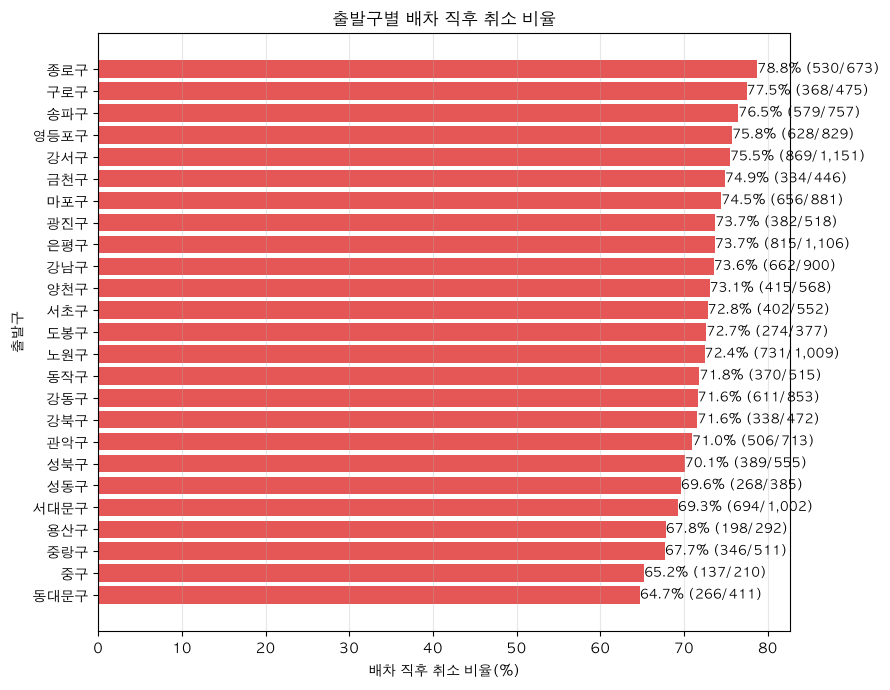

In [197]:
# 출발구별 배차 직후 취소 비율 그래프
plot_district = (
    dispatch_quick_cancel_by_district
    .sort_values("배차직후취소비율(%)", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    plot_district["출발구"],
    plot_district["배차직후취소비율(%)"],
    color="#e45756",
)

for _, row in plot_district.iterrows():
    ax.text(
        row["배차직후취소비율(%)"],
        row["출발구"],
        f'{row["배차직후취소비율(%)"]:.1f}% ({row["배차직후취소건수"]:,}/{row["배차후취소건수"]:,})',
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_title("출발구별 배차 직후 취소 비율")
ax.set_xlabel("배차 직후 취소 비율(%)")
ax.set_ylabel("출발구")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [198]:
# 배차→취소 시간이 긴 원자료 확인
long_cancel_after_dispatch = (
    cancel_after_dispatch
    .sort_values("배차_취소_분", ascending=False)
    .head(10)
)

check_cols = [
    "접수일시",
    "배차일시",
    "취소일시",
    "접수_취소_분",
    "배차_취소_분",
    "출발구",
    "목적구",
    "세부이동유형",
    "이용목적",
]

display(long_cancel_after_dispatch[check_cols])

,접수일시,배차일시,취소일시,접수_취소_분,배차_취소_분,출발구,목적구,세부이동유형,이용목적
302535,2025-12-03 17:16:42.693,2025-12-03 17:25:33.913,2025-12-03 20:13:56,177.221783,168.368117,강서구,강서구,구 내 이동,기타
294833,2025-11-26 12:18:55.063,2025-11-26 13:00:36.570,2025-11-26 15:39:39,200.732283,159.040500,강동구,강동구,구 내 이동,기타
7849,2025-01-10 16:37:54.990,2025-01-10 16:43:11.663,2025-01-10 19:06:44,148.816833,143.538950,은평구,서대문구,구 간 이동,기타
169169,2025-07-22 12:17:13.927,2025-07-22 12:18:53.523,2025-07-22 14:08:55,111.684550,110.024617,중랑구,중랑구,구 내 이동,기타
240462,2025-10-01 14:07:23.163,2025-10-01 14:22:39.443,2025-10-01 16:11:35,124.197283,108.925950,강동구,김포시,서울→서울 외,기타
154817,2025-07-08 13:55:01.157,2025-07-08 14:45:15.107,2025-07-08 16:27:14,152.214050,101.981550,금천구,성북구,구 간 이동,기타
111973,2025-05-24 17:06:25.000,2025-05-24 17:12:34.137,2025-05-24 18:54:09,107.733333,101.581050,광진구,광진구,구 내 이동,기타
315104,2025-12-16 14:12:47.373,2025-12-16 14:20:54.207,2025-12-16 15:48:04,95.277117,87.163217,강동구,강동구,구 내 이동,기타
122678,2025-06-05 15:13:14.000,2025-06-05 15:49:50.173,2025-06-05 17:15:42,122.466667,85.863783,영등포구,영등포구,구 내 이동,기타
18000,2025-01-23 11:03:51.803,2025-01-23 11:12:57.133,2025-01-23 12:36:54,93.036617,83.947783,강남구,송파구,구 간 이동,기타


취소는 배차 후에 많이 기록되지만, 배차 후 오래 기다려서 취소한 건은 많지 않아 보인다. 핵심은 배차 후 취소 여부가 아니라, 접수 후 배차되기까지 얼마나 기다렸는지다.

## 12. 출발구 × 접수시간대 조합 분석

출발구와 접수시간대를 함께 묶어 `접수→배차` 대기시간을 확인한다.

출발구만 보면 하루 전체가 합쳐져 특정 시간대의 배차 지연이 가려질 수 있고, 접수시간대만 보면 어느 지역에서 문제가 발생하는지 알기 어렵다. 따라서 출발구와 접수시간대를 함께 보아, 어느 지역에서 어느 시간대에 배차 대기가 길어지는지 확인한다.

확인할 내용:

- 출발구별·접수시간대별 승차완료건수
- 출발구별·접수시간대별 `접수→배차` 중앙값
- 출발구별·접수시간대별 `접수→배차` 90분위수
- 건수가 충분하면서 `접수→배차` 90분위수가 높은 조합
- 건수가 적어 해석에 주의가 필요한 조합

분석 근거:

`접수→배차`는 임차택시 바로콜 승차 대기시간을 좌우하는 핵심 구간이다. 출발구와 접수시간대를 결합하면 단순 지역별 평균이나 시간대별 평균으로는 보이지 않는 배차 취약 구간을 찾을 수 있다.

특히 `접수→배차` 90분위수는 해당 조합에서 장시간 배차대기가 어느 정도 발생하는지 보여준다. 따라서 승차완료건수와 함께 확인하면, 실제 운영상 우선 관리가 필요한 `출발구 × 접수시간대` 조합을 찾을 수 있다.

In [199]:
# 출발구 × 접수시간대별 접수→배차 요약표 생성
district_hour_dispatch_summary = (
    rental_ride_normal
    .groupby(["출발구", "접수시간대"], observed=False)
    .agg(
        승차완료건수=("접수_배차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

district_hour_dispatch_summary["접수시간대_HH"] = (
    district_hour_dispatch_summary["접수시간대"]
    .astype(str)
    .str.slice(0, 2)
)

display(district_hour_dispatch_summary.head())

,출발구,접수시간대,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수시간대_HH
0,강남구,03:00:00,2,201.236500,210.989700,03
1,강남구,04:00:00,74,147.159217,177.810137,04
2,강남구,05:00:00,121,90.706833,159.324333,05
3,강남구,06:00:00,304,67.287417,161.824402,06
4,강남구,07:00:00,500,39.453917,70.742807,07


In [200]:
# 건수와 90분위수를 함께 고려한 우선 확인 대상 추출
min_sample_count = 100

district_hour_priority = (
    district_hour_dispatch_summary
    .query("승차완료건수 >= @min_sample_count")
    .sort_values(
        ["접수_배차_90분위수", "승차완료건수"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(district_hour_priority.head(30))

,출발구,접수시간대,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수시간대_HH
0,송파구,03:00:00,275,181.244100,201.336757,03
1,마포구,03:00:00,190,179.412783,185.509638,03
2,동작구,05:00:00,118,144.102867,181.463865,05
3,서초구,05:00:00,117,91.078717,177.012167,05
4,강서구,03:00:00,294,134.844608,176.635618,03
5,관악구,03:00:00,409,141.012383,171.395350,03
6,강동구,05:00:00,337,131.785233,169.088823,05
7,금천구,03:00:00,237,135.876283,166.343720,03
8,성북구,05:00:00,112,126.012642,164.352022,05
9,강서구,04:00:00,153,125.926100,163.952923,04


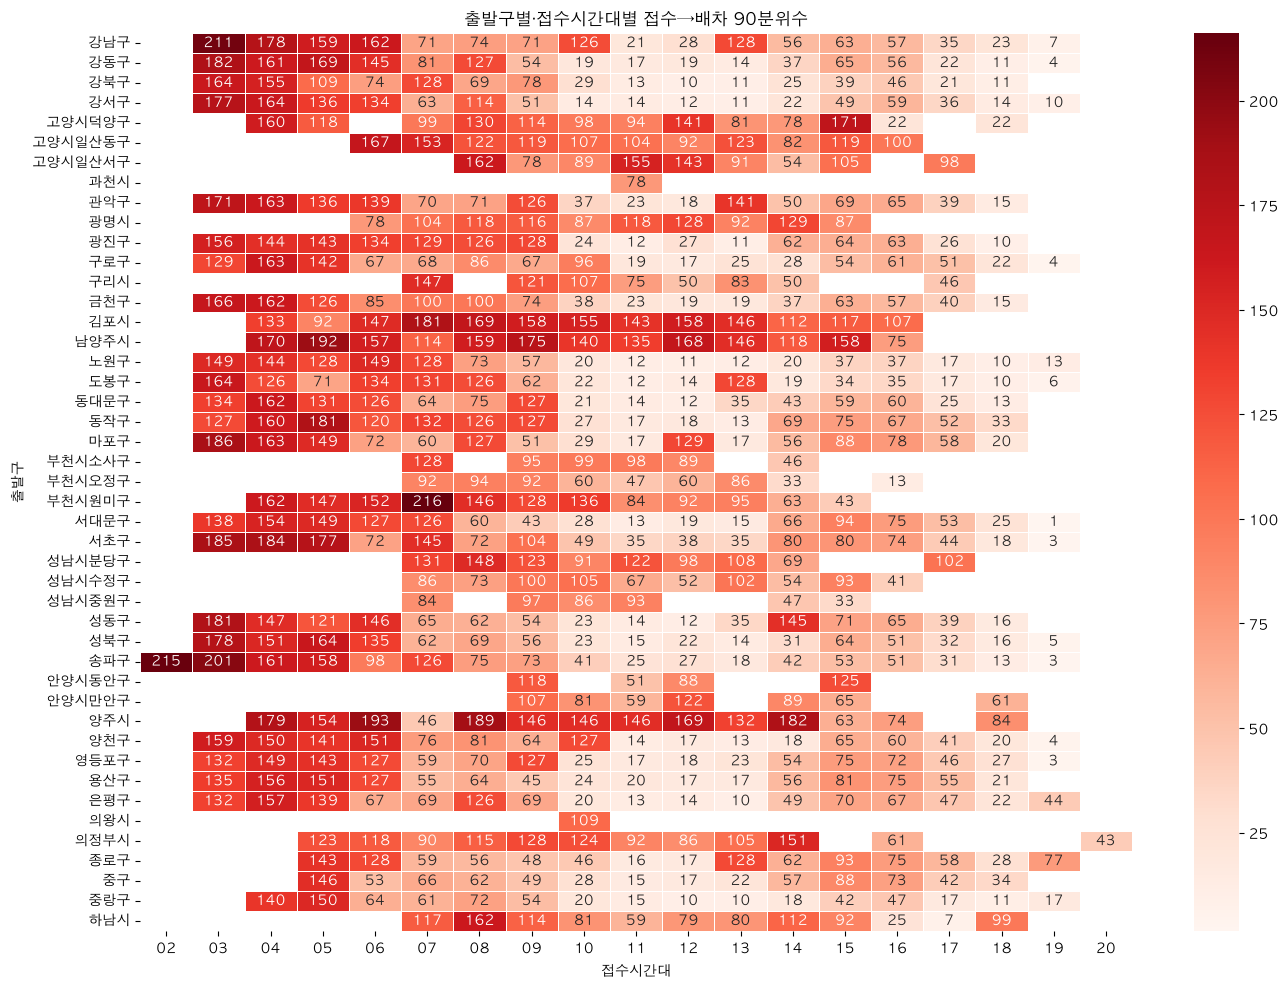

In [201]:
# 출발구 × 접수시간대별 접수→배차 90분위수 히트맵
dispatch_p90_pivot = district_hour_dispatch_summary.pivot_table(
    index="출발구",
    columns="접수시간대_HH",
    values="접수_배차_90분위수",
    aggfunc="median",
)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    dispatch_p90_pivot,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("출발구별·접수시간대별 접수→배차 90분위수")
ax.set_xlabel("접수시간대")
ax.set_ylabel("출발구")

plt.tight_layout()
plt.show()

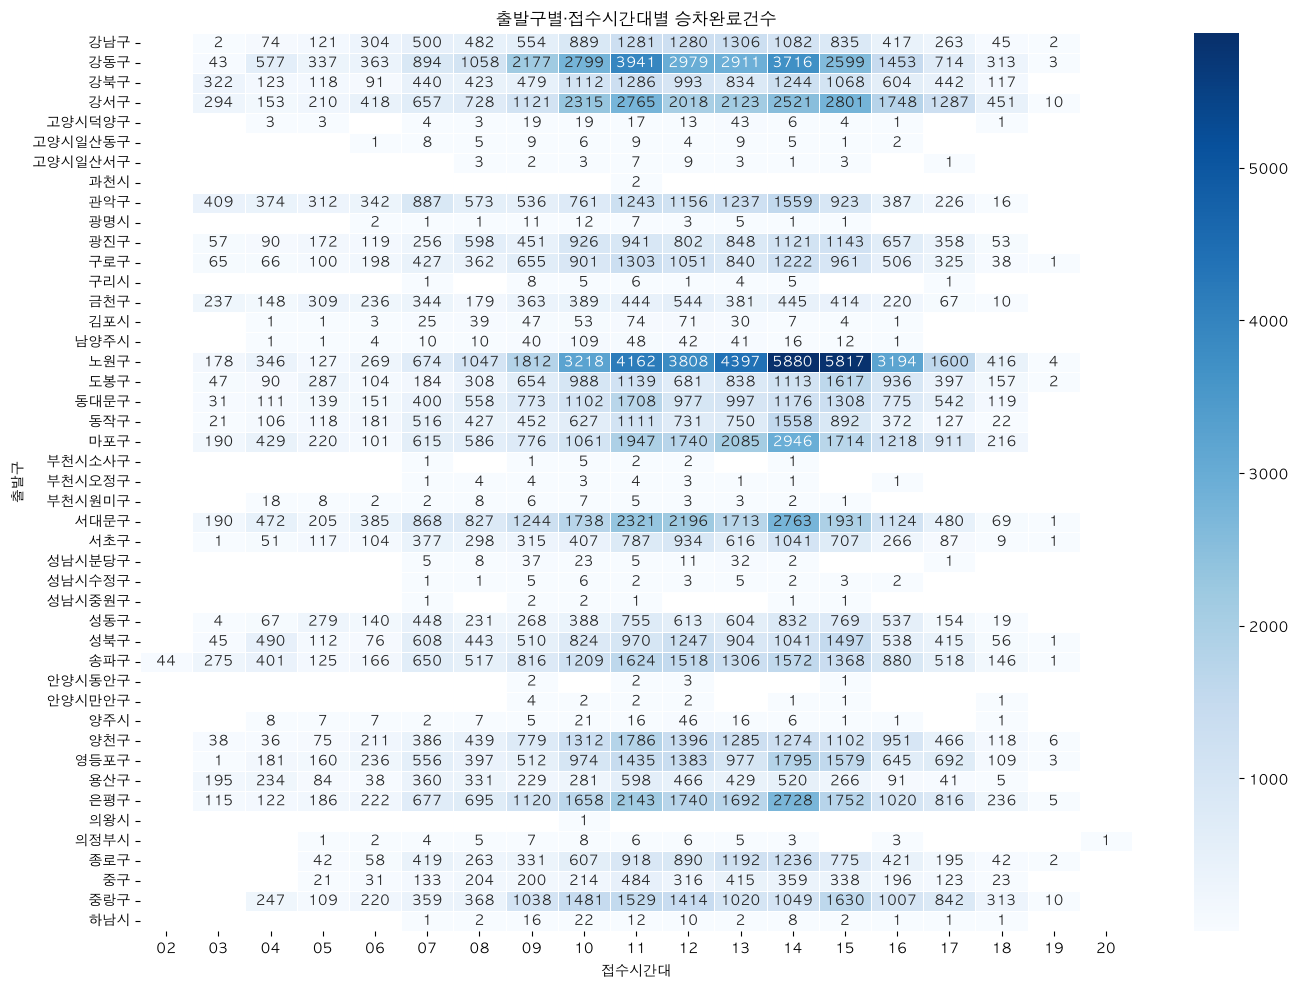

In [202]:
# 출발구 × 접수시간대별 승차완료건수 히트맵
ride_count_pivot = district_hour_dispatch_summary.pivot_table(
    index="출발구",
    columns="접수시간대_HH",
    values="승차완료건수",
    aggfunc="sum",
)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    ride_count_pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("출발구별·접수시간대별 승차완료건수")
ax.set_xlabel("접수시간대")
ax.set_ylabel("출발구")

plt.tight_layout()
plt.show()

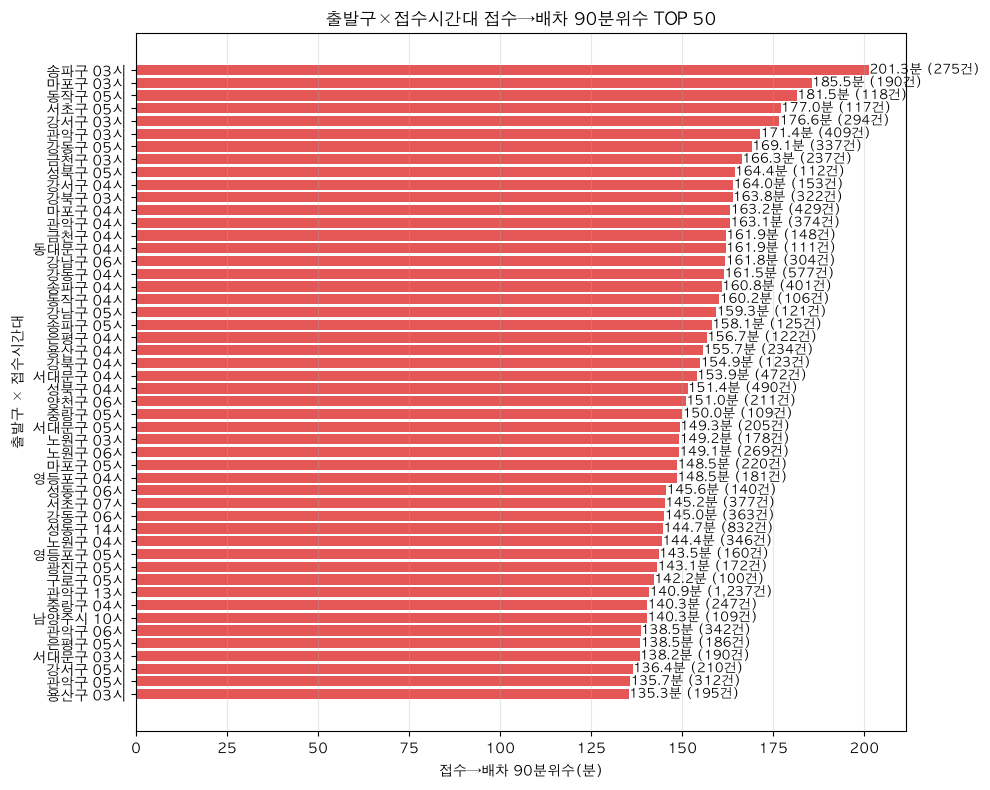

In [203]:
# 대기시간 높음 + 건수 많음 조합 시각화
plot_priority = district_hour_priority.head(50).copy()

plot_priority["출발구_접수시간대"] = (
    plot_priority["출발구"]
    + " "
    + plot_priority["접수시간대_HH"]
    + "시"
)

plot_priority = plot_priority.sort_values("접수_배차_90분위수", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    plot_priority["출발구_접수시간대"],
    plot_priority["접수_배차_90분위수"],
    color="#e45756",
)

for _, row in plot_priority.iterrows():
    ax.text(
        row["접수_배차_90분위수"],
        row["출발구_접수시간대"],
        f'{row["접수_배차_90분위수"]:.1f}분 ({row["승차완료건수"]:,}건)',
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_title("출발구×접수시간대 접수→배차 90분위수 TOP 50")
ax.set_xlabel("접수→배차 90분위수(분)")
ax.set_ylabel("출발구 × 접수시간대")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

 ## 12-1. 출발동별 대기시간 분석

출발구 단위 분석은 지역별 대기시간 차이를 크게 파악할 수 있지만, 같은 구 안에서도 동별 차량 접근성은 다를 수 있다. 따라서 출발동 단위로 `접수→배차`, `접수→승차` 대기시간을 확인해 더 세밀한 대기 취약 지역을 찾는다.

바로콜은 이용자가 접수한 뒤 차량이 배정되고 실제 승차하기까지의 시간이 핵심이므로, `접수→배차`를 배차 접근성 지표로 보고 `접수→승차`를 이용자가 체감하는 전체 대기시간 지표로 본다.

특히 평균보다 중앙값과 90분위수를 함께 확인한다. 중앙값은 일반적인 대기 수준을, 90분위수는 장시간 대기 위험을 보여준다.

,출발구,출발동,승차완료건수,접수_배차_중앙값,접수_배차_75분위수,접수_배차_90분위수,접수_승차_중앙값,접수_승차_75분위수,접수_승차_90분위수
405,송파구,가락1동,360,128.016225,196.525900,200.243345,141.500142,220.056933,222.659830
414,송파구,방이1동,399,70.793950,165.837250,185.897197,79.841233,174.122117,191.866170
291,마포구,연남동,416,129.805558,178.145708,183.489750,159.159500,192.071279,197.142892
4,강남구,논현2동,210,40.881533,145.805879,174.696540,64.946942,164.046496,191.547232
281,마포구,도화동,446,126.496442,142.481000,163.089558,143.018833,151.768637,168.446725
3,강남구,논현1동,334,45.088417,133.370642,159.342138,65.343225,159.732925,180.622385
188,김포시,대곶면,177,120.024000,140.535667,159.244430,133.417333,158.299000,180.806770
373,성동구,성수1가제1동,532,28.738333,132.933200,158.335072,52.578917,165.405075,180.271038
129,관악구,행운동,378,27.517942,126.463029,157.975995,48.315825,144.417687,185.424502
118,관악구,서원동,569,23.875000,126.707617,153.095933,44.094333,138.812667,173.061060


,출발구,출발동,승차완료건수,접수_배차_중앙값,접수_배차_75분위수,접수_배차_90분위수,접수_승차_중앙값,접수_승차_75분위수,접수_승차_90분위수
405,송파구,가락1동,360,128.016225,196.525900,200.243345,141.500142,220.056933,222.659830
291,마포구,연남동,416,129.805558,178.145708,183.489750,159.159500,192.071279,197.142892
414,송파구,방이1동,399,70.793950,165.837250,185.897197,79.841233,174.122117,191.866170
4,강남구,논현2동,210,40.881533,145.805879,174.696540,64.946942,164.046496,191.547232
129,관악구,행운동,378,27.517942,126.463029,157.975995,48.315825,144.417687,185.424502
188,김포시,대곶면,177,120.024000,140.535667,159.244430,133.417333,158.299000,180.806770
3,강남구,논현1동,334,45.088417,133.370642,159.342138,65.343225,159.732925,180.622385
373,성동구,성수1가제1동,532,28.738333,132.933200,158.335072,52.578917,165.405075,180.271038
109,관악구,낙성대동,948,16.365275,70.285204,145.402102,35.107800,87.697804,177.122605
118,관악구,서원동,569,23.875000,126.707617,153.095933,44.094333,138.812667,173.061060


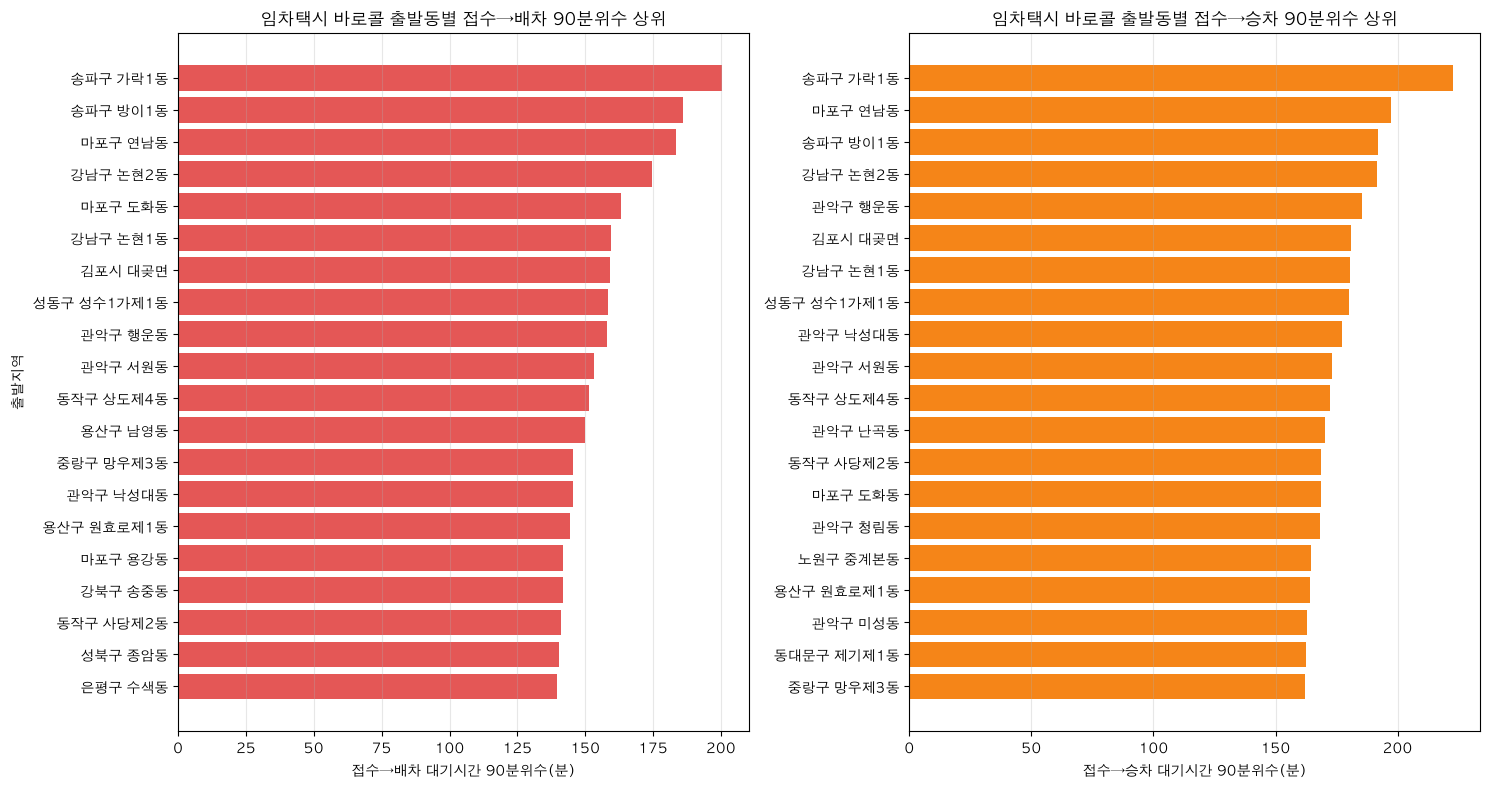

In [214]:
# 코드 셀 목적: 임차택시 바로콜 후보의 출발동별 접수→배차 및 접수→승차 대기시간을 확인한다.

rental_baro_origin_dong_wait = rental_ride_normal.copy()

wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
]

for col in wait_cols:
    rental_baro_origin_dong_wait[col] = pd.to_numeric(
        rental_baro_origin_dong_wait[col],
        errors="coerce",
    )

rental_baro_origin_dong_summary = (
    rental_baro_origin_dong_wait
    .groupby(["출발구", "출발동"], dropna=False, observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_75분위수=("접수_배차_분", lambda x: x.quantile(0.75)),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_75분위수=("접수_승차_분", lambda x: x.quantile(0.75)),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

# 표본이 너무 작은 동은 90분위수가 흔들릴 수 있으므로 일정 건수 이상만 주요 해석 대상으로 둔다.
min_count = 100

rental_baro_origin_dong_summary_valid = (
    rental_baro_origin_dong_summary[
        rental_baro_origin_dong_summary["승차완료건수"].ge(min_count)
    ]
    .copy()
)

display(
    rental_baro_origin_dong_summary_valid
    .sort_values("접수_배차_90분위수", ascending=False)
    .head(30)
)

display(
    rental_baro_origin_dong_summary_valid
    .sort_values("접수_승차_90분위수", ascending=False)
    .head(30)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

plot_dispatch = (
    rental_baro_origin_dong_summary_valid
    .sort_values("접수_배차_90분위수", ascending=False)
    .head(20)
    .sort_values("접수_배차_90분위수")
)

plot_ride = (
    rental_baro_origin_dong_summary_valid
    .sort_values("접수_승차_90분위수", ascending=False)
    .head(20)
    .sort_values("접수_승차_90분위수")
)

plot_dispatch["출발지역"] = (
    plot_dispatch["출발구"].astype(str)
    + " "
    + plot_dispatch["출발동"].astype(str)
)

plot_ride["출발지역"] = (
    plot_ride["출발구"].astype(str)
    + " "
    + plot_ride["출발동"].astype(str)
)

axes[0].barh(
    plot_dispatch["출발지역"],
    plot_dispatch["접수_배차_90분위수"],
    color="#e45756",
)

axes[0].set_title("임차택시 바로콜 출발동별 접수→배차 90분위수 상위")
axes[0].set_xlabel("접수→배차 대기시간 90분위수(분)")
axes[0].set_ylabel("출발지역")
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(
    plot_ride["출발지역"],
    plot_ride["접수_승차_90분위수"],
    color="#f58518",
)

axes[1].set_title("임차택시 바로콜 출발동별 접수→승차 90분위수 상위")
axes[1].set_xlabel("접수→승차 대기시간 90분위수(분)")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

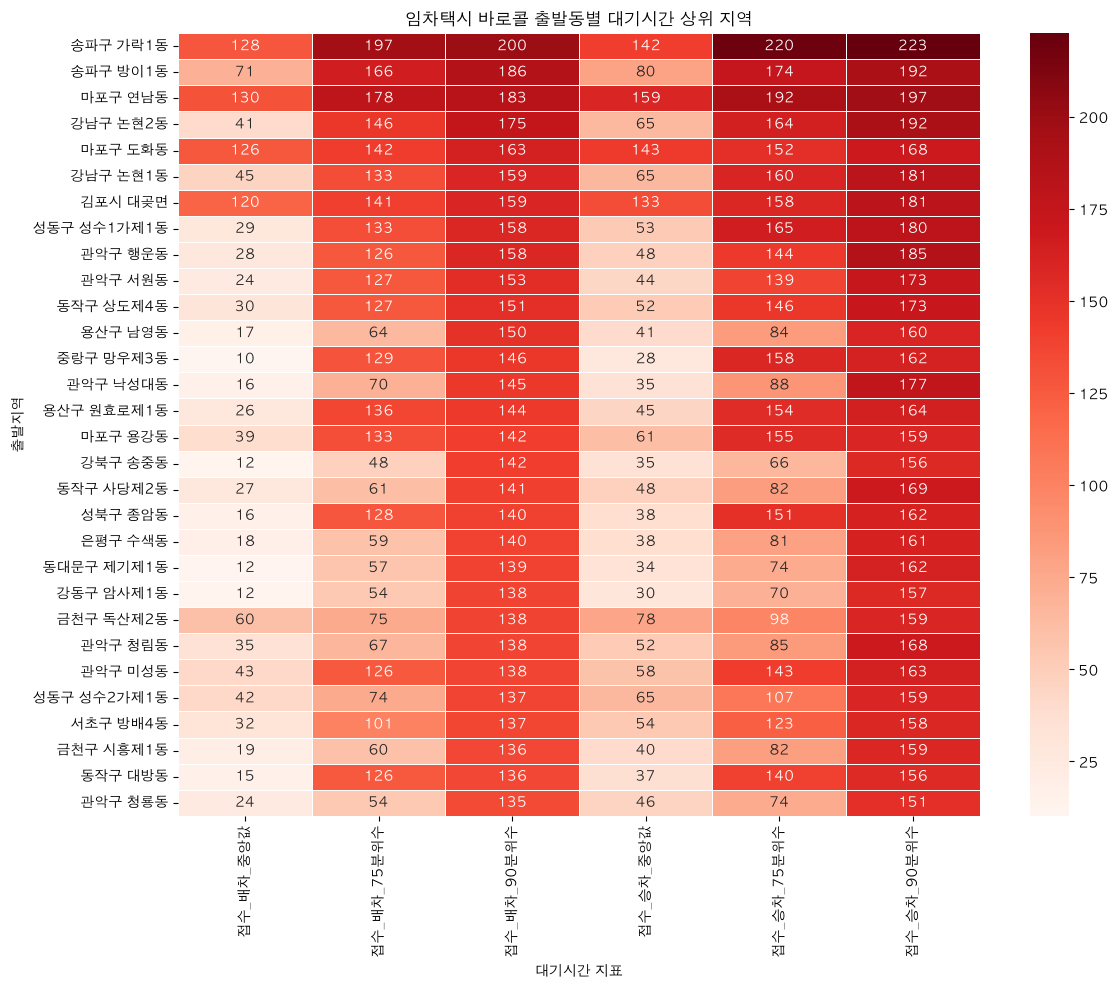

In [215]:
# 코드 셀 목적: 임차택시 바로콜 출발동별 대기시간 상위 지역의 대기시간 지표만 히트맵으로 확인한다.

heatmap_top_n = 30

origin_dong_wait_heatmap_data = (
    rental_baro_origin_dong_summary_valid
    .sort_values("접수_배차_90분위수", ascending=False)
    .head(heatmap_top_n)
    .copy()
)

origin_dong_wait_heatmap_data["출발지역"] = (
    origin_dong_wait_heatmap_data["출발구"].astype(str)
    + " "
    + origin_dong_wait_heatmap_data["출발동"].astype(str)
)

origin_dong_wait_heatmap_data = origin_dong_wait_heatmap_data.set_index("출발지역")

origin_dong_wait_heatmap = origin_dong_wait_heatmap_data[
    [
        "접수_배차_중앙값",
        "접수_배차_75분위수",
        "접수_배차_90분위수",
        "접수_승차_중앙값",
        "접수_승차_75분위수",
        "접수_승차_90분위수",
    ]
]

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    origin_dong_wait_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.5,
    ax=ax,
)

ax.set_title("임차택시 바로콜 출발동별 대기시간 상위 지역")
ax.set_xlabel("대기시간 지표")
ax.set_ylabel("출발지역")

plt.tight_layout()
plt.show()

,출발지역,접수시간대_HH,승차완료건수,접수_배차_중앙값,접수_승차_중앙값
261,송파구 가락1동,03,179,196.528450,220.075383
55,관악구 청림동,03,2,194.436733,210.785700
124,남양주시 조안면,05,1,192.328117,213.087833
276,송파구 방이1동,02,44,188.662525,205.225442
164,마포구 연남동,03,187,179.485933,192.921550
123,남양주시 조안면,04,1,170.069167,180.723667
277,송파구 방이1동,03,87,165.937833,174.195333
212,서대문구 홍제제3동,05,2,165.269500,187.858833
195,서대문구 홍은제1동,03,10,158.291217,182.419442
126,남양주시 조안면,08,1,156.420950,183.334217


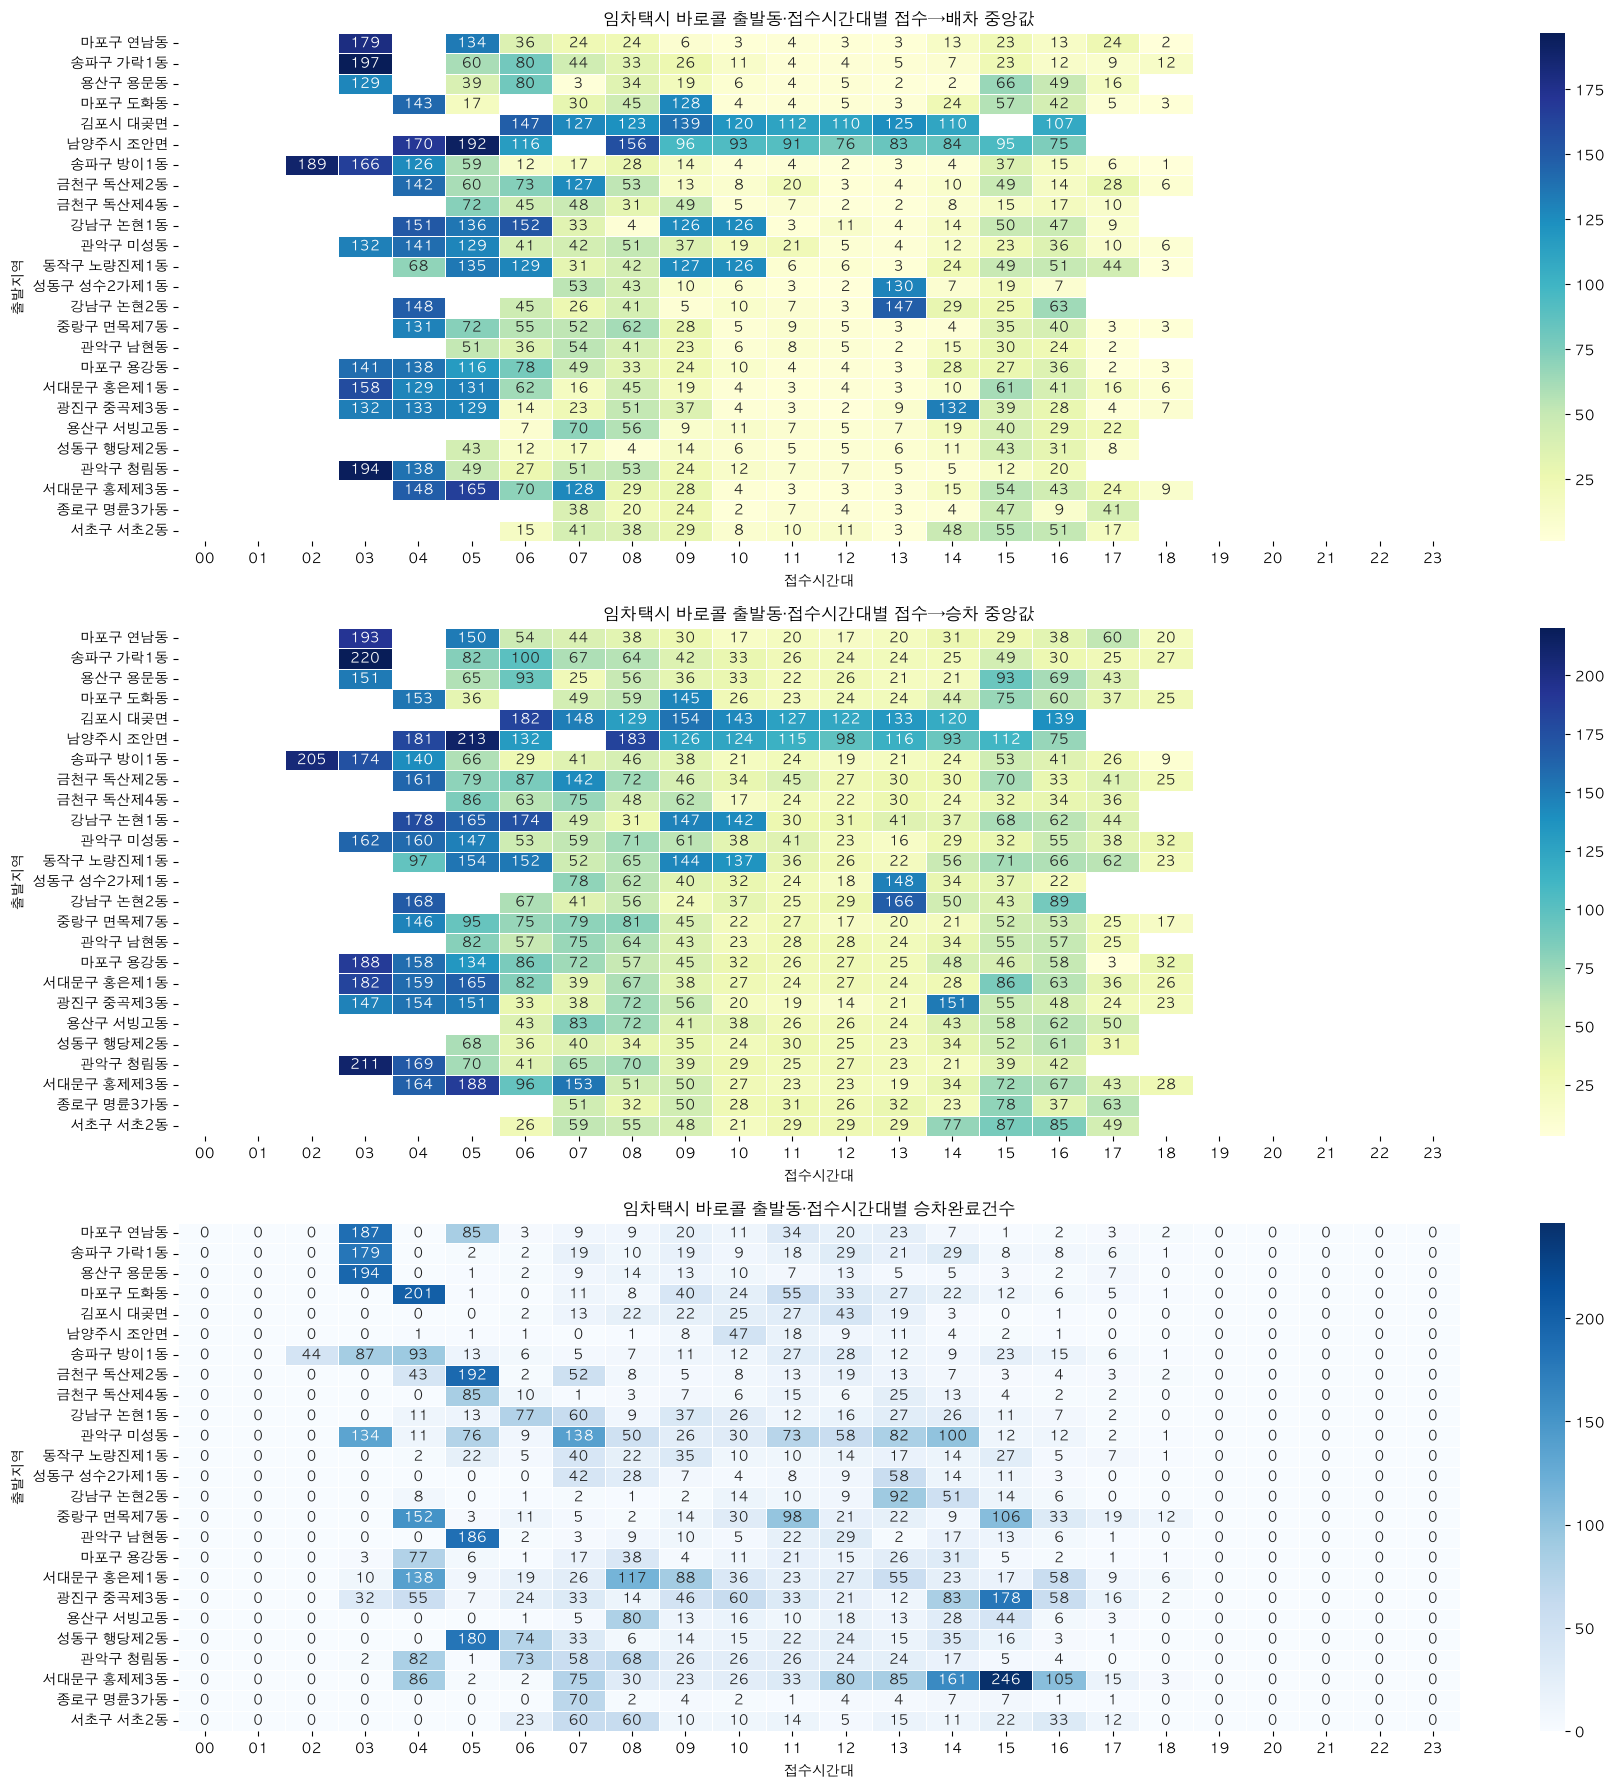

In [217]:
# 코드 셀 목적: 임차택시 바로콜 출발동별·접수시간대별 접수→배차 및 접수→승차 중앙값을 확인한다.

rental_baro_dong_hour_median_wait = rental_ride_normal.copy()

rental_baro_dong_hour_median_wait["접수일시"] = pd.to_datetime(
    rental_baro_dong_hour_median_wait["접수일시"],
    errors="coerce",
)

rental_baro_dong_hour_median_wait["접수시간대_HH"] = (
    rental_baro_dong_hour_median_wait["접수일시"]
    .dt.strftime("%H")
)

wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
]

for col in wait_cols:
    rental_baro_dong_hour_median_wait[col] = pd.to_numeric(
        rental_baro_dong_hour_median_wait[col],
        errors="coerce",
    )

rental_baro_dong_hour_median_wait["출발지역"] = (
    rental_baro_dong_hour_median_wait["출발구"].astype(str)
    + " "
    + rental_baro_dong_hour_median_wait["출발동"].astype(str)
)

hour_order = [f"{hour:02d}" for hour in range(24)]

dong_total_median_summary = (
    rental_baro_dong_hour_median_wait
    .groupby("출발지역", dropna=False, observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

min_count = 100
top_n = 25

# 90분위수 상위 출발동과 같은 동을 보려면 기존 top_dong_by_dispatch_p90를 그대로 써도 됨.
# 여기서는 중앙값이 높은 출발동 기준으로 다시 선정.
top_dong_by_dispatch_median = (
    dong_total_median_summary[
        dong_total_median_summary["승차완료건수"].ge(min_count)
    ]
    .sort_values("접수_배차_중앙값", ascending=False)
    .head(top_n)["출발지역"]
    .tolist()
)

dong_hour_median_summary = (
    rental_baro_dong_hour_median_wait[
        rental_baro_dong_hour_median_wait["출발지역"].isin(top_dong_by_dispatch_median)
    ]
    .groupby(["출발지역", "접수시간대_HH"], dropna=False, observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_승차_중앙값=("접수_승차_분", "median"),
    )
    .reset_index()
)

dong_order = top_dong_by_dispatch_median

dispatch_median_heatmap = (
    dong_hour_median_summary
    .pivot_table(
        index="출발지역",
        columns="접수시간대_HH",
        values="접수_배차_중앙값",
        aggfunc="median",
        observed=False,
    )
    .reindex(index=dong_order, columns=hour_order)
)

ride_median_heatmap = (
    dong_hour_median_summary
    .pivot_table(
        index="출발지역",
        columns="접수시간대_HH",
        values="접수_승차_중앙값",
        aggfunc="median",
        observed=False,
    )
    .reindex(index=dong_order, columns=hour_order)
)

count_heatmap = (
    dong_hour_median_summary
    .pivot_table(
        index="출발지역",
        columns="접수시간대_HH",
        values="승차완료건수",
        aggfunc="sum",
        observed=False,
    )
    .reindex(index=dong_order, columns=hour_order)
    .fillna(0)
)

display(
    dong_hour_median_summary
    .sort_values("접수_배차_중앙값", ascending=False)
    .head(30)
)

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

sns.heatmap(
    dispatch_median_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.4,
    ax=axes[0],
)

axes[0].set_title("임차택시 바로콜 출발동·접수시간대별 접수→배차 중앙값")
axes[0].set_xlabel("접수시간대")
axes[0].set_ylabel("출발지역")

sns.heatmap(
    ride_median_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.4,
    ax=axes[1],
)

axes[1].set_title("임차택시 바로콜 출발동·접수시간대별 접수→승차 중앙값")
axes[1].set_xlabel("접수시간대")
axes[1].set_ylabel("출발지역")

sns.heatmap(
    count_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.4,
    ax=axes[2],
)

axes[2].set_title("임차택시 바로콜 출발동·접수시간대별 승차완료건수")
axes[2].set_xlabel("접수시간대")
axes[2].set_ylabel("출발지역")

plt.tight_layout()
plt.show()

,출발지역,접수시간대_HH,승차완료건수,접수_배차_중앙값,접수_배차_90분위수,접수_승차_중앙값,접수_승차_90분위수
284,송파구 방이1동,02,44,188.662525,214.542205,205.225442,234.249915
100,관악구 청림동,03,2,194.436733,202.229000,210.785700,215.008740
269,송파구 가락1동,03,179,196.528450,202.117670,220.075383,225.124973
169,동작구 사당제2동,05,8,162.985358,190.841117,186.542467,218.568517
209,마포구 연남동,03,187,179.485933,185.536053,192.921550,199.396147
154,동대문구 제기제1동,05,15,151.479283,184.195863,172.742333,203.574053
114,관악구 행운동,03,52,155.147525,183.990912,185.346467,205.382062
315,용산구 원효로제1동,03,1,183.673000,183.673000,214.550383,214.550383
22,강남구 논현2동,13,92,147.313083,181.252445,166.434558,202.394890
26,강동구 암사제1동,03,3,155.423233,181.026433,171.582617,200.144123


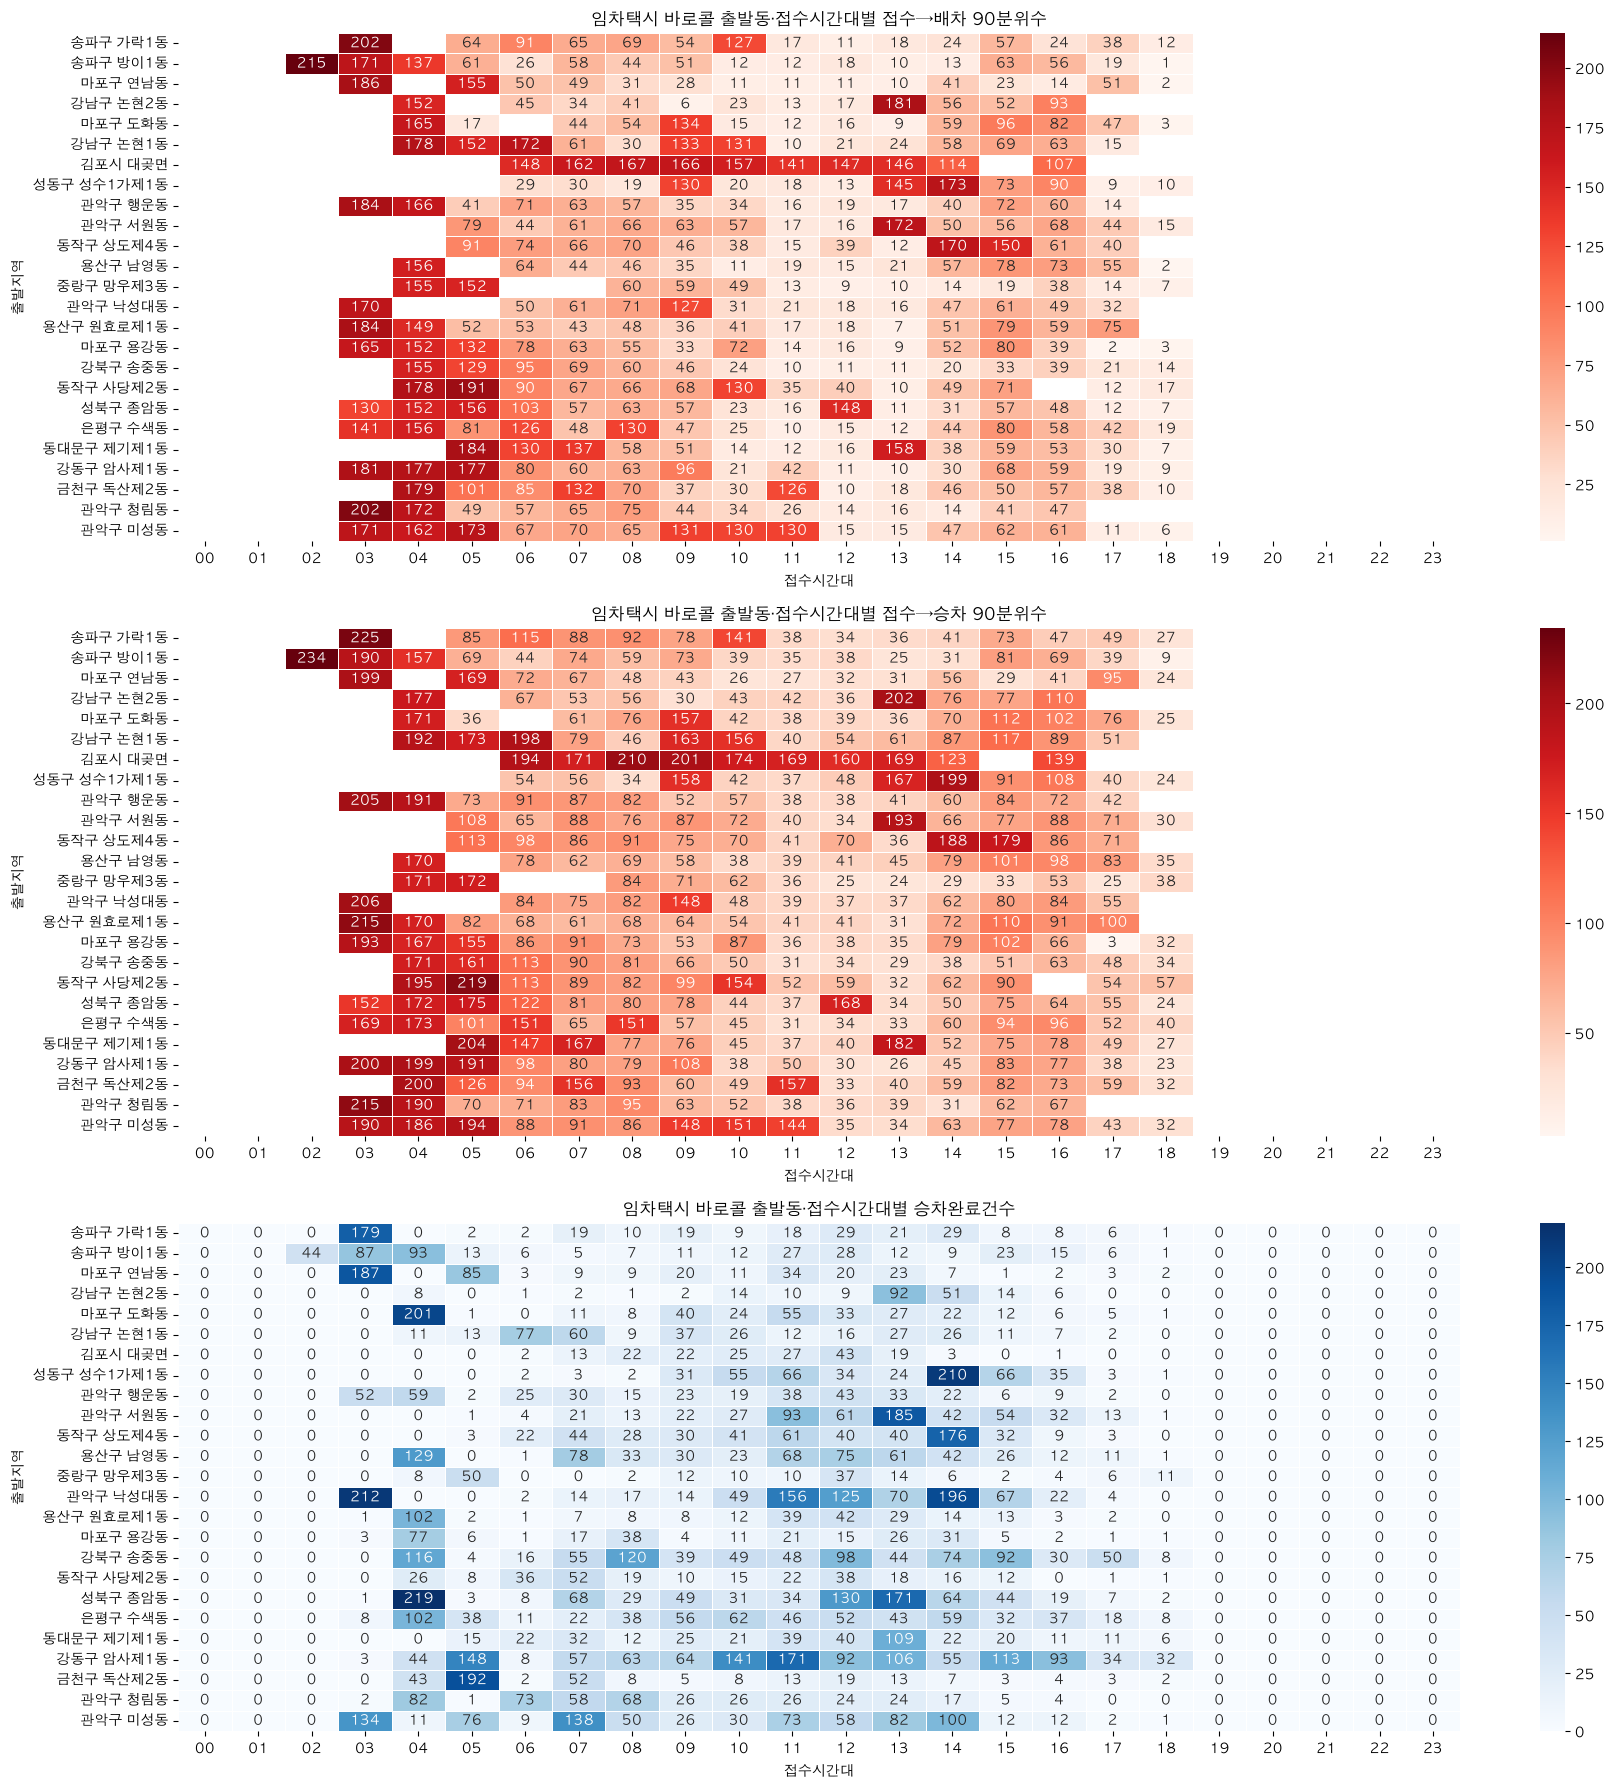

In [216]:
# 코드 셀 목적: 임차택시 바로콜 출발동별·접수시간대별 접수→배차 장시간 대기 위험을 확인한다.

rental_baro_dong_hour_wait = rental_ride_normal.copy()

rental_baro_dong_hour_wait["접수일시"] = pd.to_datetime(
    rental_baro_dong_hour_wait["접수일시"],
    errors="coerce",
)

rental_baro_dong_hour_wait["접수시간대_HH"] = (
    rental_baro_dong_hour_wait["접수일시"]
    .dt.strftime("%H")
)

wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
]

for col in wait_cols:
    rental_baro_dong_hour_wait[col] = pd.to_numeric(
        rental_baro_dong_hour_wait[col],
        errors="coerce",
    )

rental_baro_dong_hour_wait["출발지역"] = (
    rental_baro_dong_hour_wait["출발구"].astype(str)
    + " "
    + rental_baro_dong_hour_wait["출발동"].astype(str)
)

hour_order = [f"{hour:02d}" for hour in range(24)]

dong_total_summary = (
    rental_baro_dong_hour_wait
    .groupby("출발지역", dropna=False, observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

min_count = 100
top_n = 25

top_dong_by_dispatch_p90 = (
    dong_total_summary[
        dong_total_summary["승차완료건수"].ge(min_count)
    ]
    .sort_values("접수_배차_90분위수", ascending=False)
    .head(top_n)["출발지역"]
    .tolist()
)

dong_hour_summary = (
    rental_baro_dong_hour_wait[
        rental_baro_dong_hour_wait["출발지역"].isin(top_dong_by_dispatch_p90)
    ]
    .groupby(["출발지역", "접수시간대_HH"], dropna=False, observed=False)
    .agg(
        승차완료건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

dong_order = top_dong_by_dispatch_p90

dispatch_p90_heatmap = (
    dong_hour_summary
    .pivot_table(
        index="출발지역",
        columns="접수시간대_HH",
        values="접수_배차_90분위수",
        aggfunc="median",
        observed=False,
    )
    .reindex(index=dong_order, columns=hour_order)
)

ride_p90_heatmap = (
    dong_hour_summary
    .pivot_table(
        index="출발지역",
        columns="접수시간대_HH",
        values="접수_승차_90분위수",
        aggfunc="median",
        observed=False,
    )
    .reindex(index=dong_order, columns=hour_order)
)

count_heatmap = (
    dong_hour_summary
    .pivot_table(
        index="출발지역",
        columns="접수시간대_HH",
        values="승차완료건수",
        aggfunc="sum",
        observed=False,
    )
    .reindex(index=dong_order, columns=hour_order)
    .fillna(0)
)

display(dong_hour_summary.sort_values("접수_배차_90분위수", ascending=False).head(30))

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

sns.heatmap(
    dispatch_p90_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.4,
    ax=axes[0],
)

axes[0].set_title("임차택시 바로콜 출발동·접수시간대별 접수→배차 90분위수")
axes[0].set_xlabel("접수시간대")
axes[0].set_ylabel("출발지역")

sns.heatmap(
    ride_p90_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    linewidths=0.4,
    ax=axes[1],
)

axes[1].set_title("임차택시 바로콜 출발동·접수시간대별 접수→승차 90분위수")
axes[1].set_xlabel("접수시간대")
axes[1].set_ylabel("출발지역")

sns.heatmap(
    count_heatmap,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.4,
    ax=axes[2],
)

axes[2].set_title("임차택시 바로콜 출발동·접수시간대별 승차완료건수")
axes[2].set_xlabel("접수시간대")
axes[2].set_ylabel("출발지역")

plt.tight_layout()
plt.show()

## 13. 배차 지연형과 배차 후 지연형 분리

임차택시 바로콜 승차완료 건을 대상으로 `접수→배차`와 `배차→승차` 시간을 함께 비교해 대기시간이 길어진 원인을 분리한다.

같은 `접수→승차` 대기시간이 길더라도 원인은 다를 수 있다. `접수→배차`가 길고 `배차→승차`가 짧다면 차량 배정 자체가 늦어진 경우로 볼 수 있다. 반대로 `접수→배차`는 짧지만 `배차→승차`가 길다면 배차는 되었지만 차량이 실제 승차지까지 도착하는 데 시간이 오래 걸린 경우로 볼 수 있다.

확인할 내용:

- `접수→배차` 장시간 기준
- `배차→승차` 장시간 기준
- 배차 지연형 건수와 비율
- 배차 후 지연형 건수와 비율
- 둘 다 긴 복합 지연형 건수와 비율
- 지연유형별 접수시간대, 출발구, 세부이동유형, 승차거리구간 분포

분석 근거:

임차택시 바로콜 대기시간 개선 방향은 지연이 발생한 단계에 따라 달라진다. 배차 지연형은 차량 배정 가능성 또는 공급 부족과 관련될 수 있고, 배차 후 지연형은 차량 접근거리, 도로 상황, 출발지 접근성 문제와 관련될 수 있다. 따라서 두 지표를 함께 사용해 지연 유형을 구분한다.

| 지연유형 | 의미 |
|---|---|
| 일반 | 접수→배차, 배차→승차 모두 장시간 기준 미해당 |
| 배차 지연형 | 접수→배차만 장시간 |
| 배차 후 지연형 | 배차→승차만 장시간 |
| 복합 지연형 | 접수→배차, 배차→승차 둘 다 장시간 |

In [204]:
# 배차 지연형/배차 후 지연형 기준 생성
dispatch_delay_cutoff = rental_ride_normal["접수_배차_분"].quantile(0.90)
pickup_delay_cutoff = rental_ride_normal["배차_승차_분"].quantile(0.90)

print(f"접수→배차 장시간 기준: {dispatch_delay_cutoff:.1f}분")
print(f"배차→승차 장시간 기준: {pickup_delay_cutoff:.1f}분")

rental_ride_normal["접수_배차_장시간여부"] = (
    rental_ride_normal["접수_배차_분"] >= dispatch_delay_cutoff
)

rental_ride_normal["배차_승차_장시간여부"] = (
    rental_ride_normal["배차_승차_분"] >= pickup_delay_cutoff
)

접수→배차 장시간 기준: 66.6분
배차→승차 장시간 기준: 27.4분


In [205]:
# 지연유형 생성
rental_ride_normal["지연유형"] = "일반"

rental_ride_normal.loc[
    rental_ride_normal["접수_배차_장시간여부"]
    & ~rental_ride_normal["배차_승차_장시간여부"],
    "지연유형"
] = "배차 지연형"

rental_ride_normal.loc[
    ~rental_ride_normal["접수_배차_장시간여부"]
    & rental_ride_normal["배차_승차_장시간여부"],
    "지연유형"
] = "배차 후 지연형"

rental_ride_normal.loc[
    rental_ride_normal["접수_배차_장시간여부"]
    & rental_ride_normal["배차_승차_장시간여부"],
    "지연유형"
] = "복합 지연형"

In [206]:
# 지연유형별 건수와 대기시간 요약
delay_type_summary = (
    rental_ride_normal
    .groupby("지연유형", observed=False)
    .agg(
        건수=("접수_승차_분", "count"),
        접수_배차_중앙값=("접수_배차_분", "median"),
        접수_배차_90분위수=("접수_배차_분", lambda x: x.quantile(0.90)),
        배차_승차_중앙값=("배차_승차_분", "median"),
        배차_승차_90분위수=("배차_승차_분", lambda x: x.quantile(0.90)),
        접수_승차_중앙값=("접수_승차_분", "median"),
        접수_승차_90분위수=("접수_승차_분", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

delay_type_summary["비율(%)"] = (
    delay_type_summary["건수"]
    / delay_type_summary["건수"].sum()
    * 100
)

delay_type_summary = delay_type_summary.sort_values(
    "건수",
    ascending=False,
).reset_index(drop=True)

display(delay_type_summary)

,지연유형,건수,접수_배차_중앙값,접수_배차_90분위수,배차_승차_중앙값,배차_승차_90분위수,접수_승차_중앙값,접수_승차_90분위수,비율(%)
0,일반,249317,7.312050,41.167587,15.255617,23.462637,24.554950,57.732033,81.548365
1,배차 지연형,25839,127.149550,153.346640,16.862833,24.364173,143.682883,170.309090,8.451603
2,배차 후 지연형,25839,10.041783,47.277310,31.162550,40.278007,44.196383,81.299727,8.451603
3,복합 지연형,4734,127.068942,155.232130,32.171117,44.305067,160.404475,190.644085,1.548430


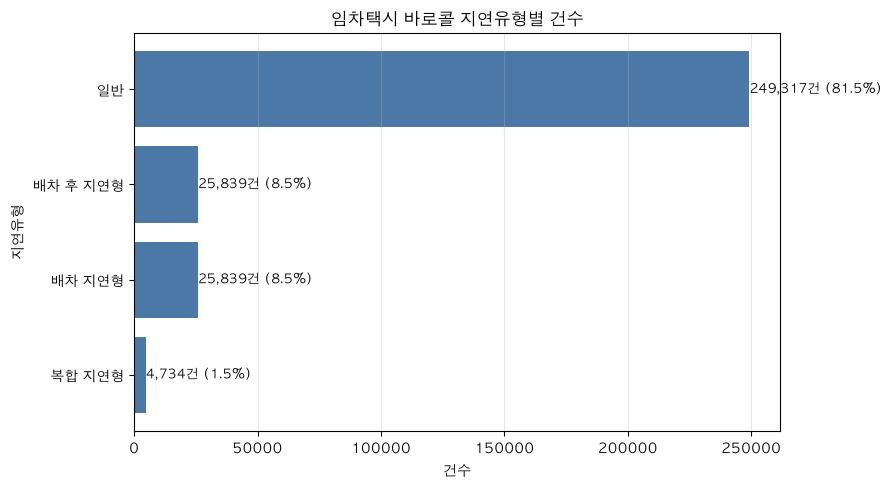

In [207]:
# 지연유형별 건수 그래프
plot_data = delay_type_summary.sort_values("건수", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_data["지연유형"],
    plot_data["건수"],
    color="#4c78a8",
)

for _, row in plot_data.iterrows():
    ax.text(
        row["건수"],
        row["지연유형"],
        f'{row["건수"]:,}건 ({row["비율(%)"]:.1f}%)',
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_title("임차택시 바로콜 지연유형별 건수")
ax.set_xlabel("건수")
ax.set_ylabel("지연유형")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [208]:
# 지연유형별 접수시간대 분포
delay_type_hour_summary = (
    rental_ride_normal
    .groupby(["접수시간대", "지연유형"], observed=False)
    .size()
    .reset_index(name="건수")
)

delay_type_hour_summary["접수시간대_HH"] = (
    delay_type_hour_summary["접수시간대"]
    .astype(str)
    .str.slice(0, 2)
)

delay_type_hour_pivot = delay_type_hour_summary.pivot_table(
    index="접수시간대_HH",
    columns="지연유형",
    values="건수",
    aggfunc="sum",
    fill_value=0,
)

delay_type_hour_rate = (
    delay_type_hour_pivot
    .div(delay_type_hour_pivot.sum(axis=1), axis=0)
    * 100
)

display(delay_type_hour_rate)

지연유형,배차 지연형,배차 후 지연형,복합 지연형,일반
접수시간대_HH,,,,
02,77.272727,0.000000,22.727273,0.000000
03,72.753623,0.000000,27.246377,0.000000
04,82.845188,0.039849,16.537159,0.577804
05,44.568924,12.713103,8.085728,34.632245
06,21.546499,13.312435,3.406479,61.734587
07,11.982365,13.919068,1.905212,72.193355
08,16.843544,10.315163,1.583856,71.257437
09,8.319739,9.934747,0.989668,80.755846
10,4.394833,7.624263,0.596742,87.384162


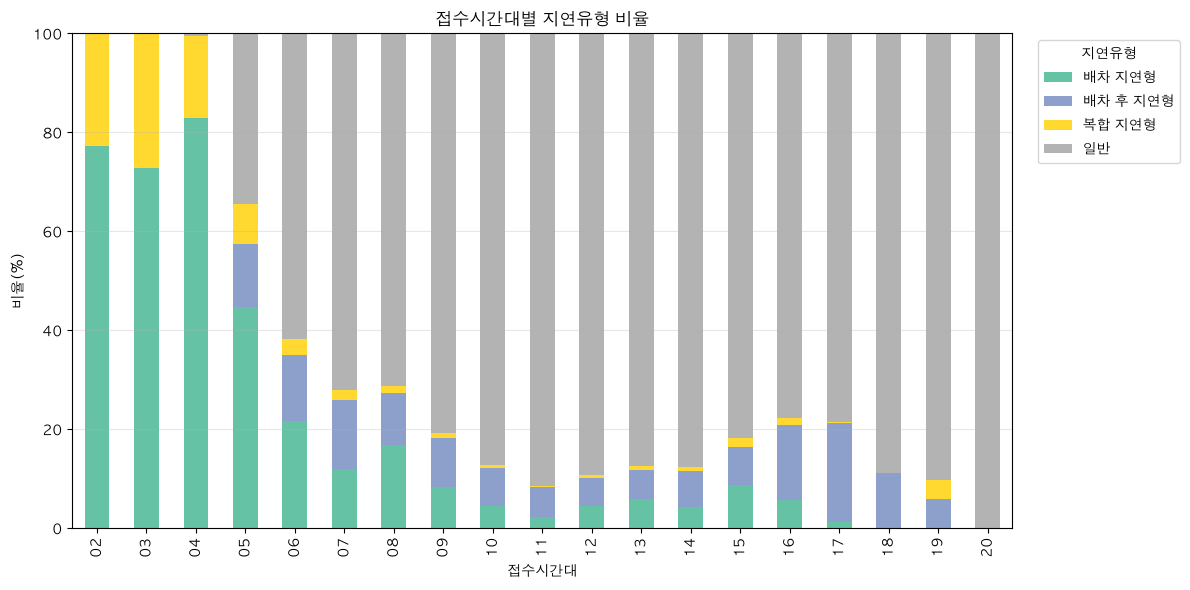

In [209]:
# 접수시간대별 지연유형 비율 그래프
fig, ax = plt.subplots(figsize=(12, 6))

delay_type_hour_rate.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="Set2",
)

ax.set_title("접수시간대별 지연유형 비율")
ax.set_xlabel("접수시간대")
ax.set_ylabel("비율(%)")
ax.legend(title="지연유형", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [210]:
# 지연유형별 세부이동유형 분포
delay_type_movement_summary = (
    rental_ride_normal
    .groupby(["세부이동유형", "지연유형"], observed=False)
    .size()
    .reset_index(name="건수")
)

delay_type_movement_pivot = delay_type_movement_summary.pivot_table(
    index="세부이동유형",
    columns="지연유형",
    values="건수",
    aggfunc="sum",
    fill_value=0,
)

delay_type_movement_rate = (
    delay_type_movement_pivot
    .div(delay_type_movement_pivot.sum(axis=1), axis=0)
    * 100
)

display(delay_type_movement_rate)

지연유형,배차 지연형,배차 후 지연형,복합 지연형,일반
세부이동유형,,,,
구 간 이동,8.994038,9.126401,1.755941,80.123620
구 내 이동,7.482502,7.217820,1.002428,84.297250
서울 외→서울,50.548034,8.059317,26.370084,15.022566
서울→서울 외,6.531829,10.225219,1.172505,82.070448


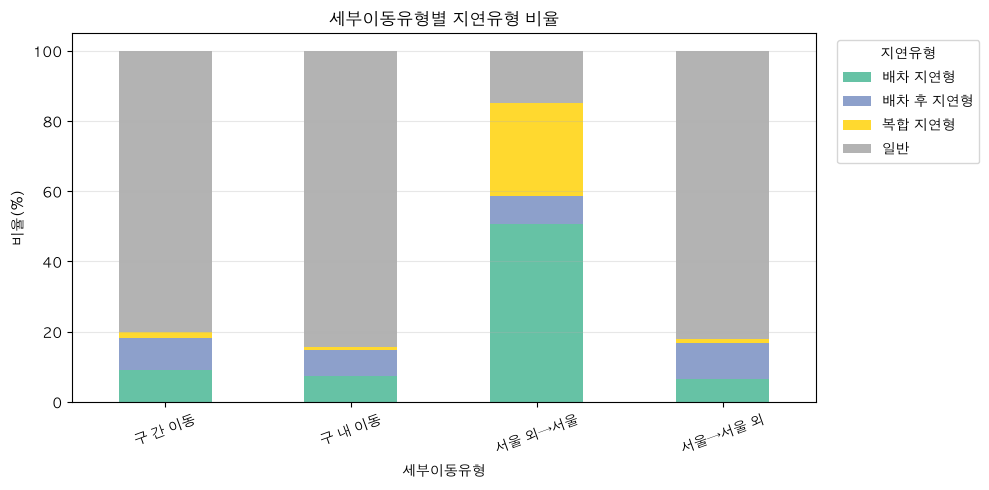

In [211]:
# 세부이동유형별 지연유형 비율 그래프
fig, ax = plt.subplots(figsize=(10, 5))

delay_type_movement_rate.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="Set2",
)

ax.set_title("세부이동유형별 지연유형 비율")
ax.set_xlabel("세부이동유형")
ax.set_ylabel("비율(%)")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="지연유형", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [212]:
# 지연유형별 승차거리구간 분포
delay_type_distance_summary = (
    rental_ride_normal
    .groupby(["승차거리구간", "지연유형"], observed=False)
    .size()
    .reset_index(name="건수")
)

delay_type_distance_pivot = delay_type_distance_summary.pivot_table(
    index="승차거리구간",
    columns="지연유형",
    values="건수",
    aggfunc="sum",
    fill_value=0,
)

delay_type_distance_rate = (
    delay_type_distance_pivot
    .div(delay_type_distance_pivot.sum(axis=1), axis=0)
    * 100
)

display(delay_type_distance_rate)

지연유형,배차 지연형,배차 후 지연형,복합 지연형,일반
승차거리구간,,,,
0~5km,7.912108,7.455003,1.050215,83.582674
5~10km,7.746109,8.709185,1.201099,82.343607
10~15km,8.088306,8.955943,2.455092,80.500659
15~25km,10.401659,10.485338,2.863276,76.249727
25km 초과,15.143766,12.427426,4.257672,68.171136


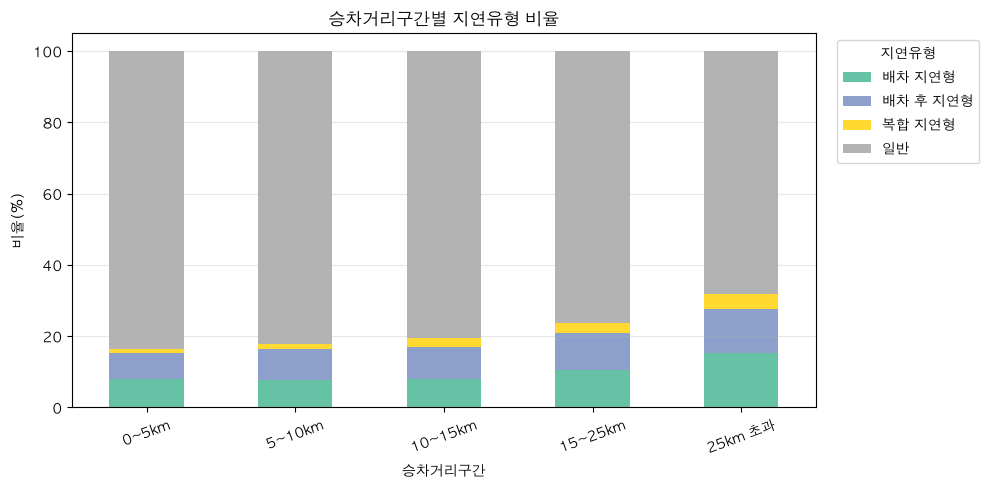

In [213]:
# 승차거리구간별 지연유형 비율 그래프
fig, ax = plt.subplots(figsize=(10, 5))

delay_type_distance_rate.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="Set2",
)

ax.set_title("승차거리구간별 지연유형 비율")
ax.set_xlabel("승차거리구간")
ax.set_ylabel("비율(%)")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="지연유형", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()